<a href="https://colab.research.google.com/github/the-skyfishy/NHANES-depression-diabetes-analysis/blob/main/BIOPAL_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **BIOPAL Project**
# **Title of project: Among adults aged 20-80, using data collected from the 2007-2008 to 2015-2016 NHANES cycles, Does depression predict higher fasting glucose, HbA1c, oral glucose tolerance test and fasting insulin biomarkers?**

## Group members and contributions:



| Member | Student Name | Student Number | Contribution to the project |
|--------|--------------|------------------|--------------------------------------------------------
|1| Sreya |  S10240940C  | (3) Logistic Regression analysis|
|2| Benetta | S10268028F | (2) Data exploration |
|3| Tian  Yu | S10240966C | (1) Data preparation and (4) predictive analysis using XGBoost |



### Link to GitHub repository: https://github.com/the-skyfishy/NHANES-depression-diabetes-analysis/blob/main/BIOPAL_Report.ipynb
### Link to Google Colab: https://colab.research.google.com/drive/1LWA8tY3pVtHclfM4zeDxBhkduE9TzgsZ?usp=sharing



# **1. Data loading and preparation**

### **1.1 Importing of libraries, loading of functions and preliminary cleaning**


In [1]:
import pandas as pd
from functools import reduce
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import statsmodels.api as sm

In [2]:
# -----------------------------
# Generic data loader (EDITED)
# -----------------------------

TINY_THRESHOLD = 1e-6

def load_data(file_prefix, columns, years, cycles, dtype_map=None):
    urls = [
        f"https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/{y}/DataFiles/{file_prefix}_{c}.xpt"
        for y, c in zip(years, cycles)
    ]

    df_list = []
    for url in urls:
        try:
            df = pd.read_sas(url)

            use_cols = [col for col in columns if col in df.columns]
            df = df[use_cols].copy()

            # Force numeric where possible
            for col in use_cols:
                df[col] = pd.to_numeric(df[col], errors="coerce")

            # Clean tiny floating-point artifacts
            for col in df.columns:
                if pd.api.types.is_float_dtype(df[col]):
                    df[col] = df[col].apply(
                        lambda x: 0 if pd.notna(x) and abs(x) < TINY_THRESHOLD else x
                    )

            # Cast dtypes if provided
            if dtype_map is not None:
                df = df.astype(dtype_map)

            df_list.append(df)

        except Exception as e:
            print(f"Could not load {url}: {e}")

    if not df_list:
        return pd.DataFrame(columns=columns)

    return pd.concat(df_list, ignore_index=True)

In [3]:
# -----------------------------
# NHANES cycles (OGTT available)
# -----------------------------
years  = ["2007", "2009", "2011", "2013", "2015"]
cycles = ["E", "F", "G", "H", "I"]

# -----------------------------
# Load datasets (with casting)
# -----------------------------
df_demo = load_data(
    "DEMO",
    ["SEQN", "RIDAGEYR", "RIAGENDR", "RIDRETH1", "INDFMPIR"],
    years, cycles,
    dtype_map={
        "SEQN": "int64",
        "RIDAGEYR": "Int64",
        "RIAGENDR": "Int64",
        "RIDRETH1": "Int64",
        "INDFMPIR": "float64"
    }
)

df_phq = load_data(
    "DPQ",
    ["SEQN"] + [f"DPQ0{i}0" for i in range(1, 10)],
    years, cycles,
    dtype_map={"SEQN": "int64"}
)

df_diq = load_data(
    "DIQ",
    ["SEQN", "DIQ160", "DIQ170"],
    years, cycles,
    dtype_map={"SEQN": "int64", "DIQ160": "Int64", "DIQ170": "Int64"}
)

df_smq = load_data(
    "SMQ",
    ["SEQN", "SMQ020"],
    years, cycles,
    dtype_map={"SEQN": "int64", "SMQ020": "Int64"}
)

df_bmx = load_data(
    "BMX",
    ["SEQN", "BMXWAIST", "BMXBMI"],
    years, cycles,
    dtype_map={"SEQN": "int64", "BMXWAIST": "float64", "BMXBMI": "float64"}
)

df_diet = load_data(
    "DR1TOT",
    ["SEQN", "DR1TKCAL"],
    years, cycles,
    dtype_map={"SEQN": "int64", "DR1TKCAL": "float64"}
)

df_paq = load_data(
    "PAQ",
    ["SEQN", "PAD680"],
    years, cycles,
    dtype_map={"SEQN": "int64", "PAD680": "float64"}
)

df_ldl = load_data(
    "TRIGLY",
    ["SEQN", "LBDLDL"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBDLDL": "float64"}
)

df_glu = load_data(
    "GLU",
    ["SEQN", "LBDGLUSI"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBDGLUSI": "float64"}
)

df_hba1c = load_data(
    "GHB",
    ["SEQN", "LBXGH"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBXGH": "float64"}
)

df_ogtt = load_data(
    "OGTT",
    ["SEQN", "LBDGLTSI"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBDGLTSI": "float64"}
)

df_ins = load_data(
    "INS",
    ["SEQN", "LBDINSI"],
    years, cycles,
    dtype_map={"SEQN": "int64", "LBDINSI": "float64"}
)

# Insulin for cycles E, F, G from GLU file
df_ins_efg = load_data(
    "GLU",
    ["SEQN", "LBDINSI"],
    years=["2007", "2009", "2011"],
    cycles=["E", "F", "G"],
    dtype_map={"SEQN": "int64", "LBDINSI": "float64"}
)

df_ins = pd.concat([df_ins, df_ins_efg], ignore_index=True)

# -----------------------------
# Merge everything
# -----------------------------
dfs = [
    df_demo, df_phq, df_diq, df_smq, df_bmx,
    df_diet, df_paq, df_ldl,
    df_glu, df_hba1c, df_ogtt, df_ins
]

df = reduce(lambda left, right: pd.merge(left, right, on="SEQN", how="left"), dfs)

# -----------------------------
# Final extracted dataset
# -----------------------------
print(df.shape)
df.head()


Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2007/DataFiles/INS_E.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2009/DataFiles/INS_F.xpt: HTTP Error 404: Not Found
Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2011/DataFiles/INS_G.xpt: HTTP Error 404: Not Found
(50588, 26)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,INDFMPIR,DPQ010,DPQ020,DPQ030,DPQ040,DPQ050,...,SMQ020,BMXWAIST,BMXBMI,DR1TKCAL,PAD680,LBDLDL,LBDGLUSI,LBXGH,LBDGLTSI,LBDINSI
0,41475,62,2,5,1.83,1.0,0.0,1.0,1.0,1.0,...,2,156.3,58.04,1598.0,720.0,NaN,NaN,5.7,NaN,NaN
1,41476,6,2,5,5.00,NaN,NaN,NaN,NaN,NaN,...,<NA>,52.7,15.18,2093.0,NaN,NaN,NaN,NaN,NaN,NaN
2,41477,71,1,3,1.50,0.0,0.0,0.0,0.0,0.0,...,1,109.5,30.05,914.0,240.0,NaN,NaN,9.5,NaN,NaN
3,41478,1,2,3,0.66,NaN,NaN,NaN,NaN,NaN,...,<NA>,NaN,NaN,1148.0,NaN,NaN,NaN,NaN,NaN,NaN
4,41479,52,1,1,2.20,0.0,0.0,0.0,0.0,0.0,...,2,95.4,27.56,2910.0,180.0,121.0,6.273,5.7,7.105,57.6


- The error messages above "Could not load https://wwwn.cdc.gov/Nchs/Data/Nhanes/Public/2007/DataFiles/INS_E.xpt: HTTP Error 404: Not Found" etc. can be ignored as they are later extracted using another piece of code

 'Missingness' of each variable in the uncleaned df

In [4]:
df.isnull().sum()/len(df)*100

,0
SEQN,0.000000
RIDAGEYR,0.000000
RIAGENDR,0.000000
RIDRETH1,0.000000
INDFMPIR,9.027833
DPQ010,47.534989
DPQ020,47.544872
DPQ030,47.548826
DPQ040,47.556733
DPQ050,47.556733


### **1.2 Data cleaning**

#### 1.2.1 Removal of data for those that responded "Don't know" or "Refused to respond"

- To find the value used to code for don't know or refused, the max value of each variable is found


In [5]:
df.max()

,0
SEQN,93702.0
RIDAGEYR,80.0
RIAGENDR,2.0
RIDRETH1,5.0
INDFMPIR,5.0
DPQ010,9.0
DPQ020,9.0
DPQ030,9.0
DPQ040,9.0
DPQ050,9.0


Using the max values from the previous step,
- DPQ010 - DPQ090 -> coded as 7/9
- DIQ160, DIQ170 -> coded as 7/9
- SMQ020 -> coded as 7/9
- PAD680 -> coded as 7777/9999

These responses are cleaned out below:


In [6]:
# -----------------------------
# DPQ (PHQ-9 items)
# -----------------------------
dpq_cols = [f"DPQ0{i}0" for i in range(1, 10)]
dpq_map = {7: np.nan, 9: np.nan}

for col in dpq_cols:
    if col in df.columns:
        df[col] = df[col].replace(dpq_map)

# -----------------------------
# DIQ160-170, SMQ020
# -----------------------------
for col in ["DIQ160", "DIQ170", "SMQ020"]:
    if col in df.columns:
        df[col] = df[col].replace(dpq_map)

# -----------------------------
# PAD680 (sedentary minutes)
# -----------------------------
pad_map = {7777: np.nan, 9999: np.nan}

if "PAD680" in df.columns:
    df["PAD680"] = df["PAD680"].replace(pad_map)

# -----------------------------
# Sanity check: new max values
# -----------------------------
check_cols = dpq_cols + ["PAD680"]

for col in check_cols:
    if col in df.columns:
        print(f"Max value in {col}: {df[col].max()}")


Max value in DPQ010: 3.0
Max value in DPQ020: 3.0
Max value in DPQ030: 3.0
Max value in DPQ040: 3.0
Max value in DPQ050: 3.0
Max value in DPQ060: 3.0
Max value in DPQ070: 3.0
Max value in DPQ080: 3.0
Max value in DPQ090: 3.0
Max value in PAD680: 1380.0


PHQ-9 total scores are computed, DPQ010-DPQ090 columns are removed here.

In [7]:
# -----------------------------
# Compute PHQ-9 total score
# -----------------------------

# Keep only rows with complete PHQ-9 data
df = df.dropna(subset=dpq_cols)

# Sum PHQ-9 items
df["PHQ9_total"] = df[dpq_cols].sum(axis=1)

# Cast to int (PHQ-9 is discrete 0–27)
df["PHQ9_total"] = df["PHQ9_total"].astype(int)

# -----------------------------
# Remove DPQ item columns
# -----------------------------
df = df.drop(columns=dpq_cols)

# -----------------------------
# Check
# -----------------------------
df[["PHQ9_total"]].describe()


,PHQ9_total
count,26392.000000
mean,3.276978
std,4.348256
min,0.000000
25%,0.000000
50%,2.000000
75%,5.000000
max,27.000000


#### 1.2.2 Filtering of non-participants from the dataset

Particpants younger than 20 or older than 79 are filtered out here.
- 80 is used to code for participants 80 years old and older in certain cycles, hence 80 is excluded and 79 is incuded

In [8]:
## Filter out participants less than 20 years old or more than 80 years old
df = df[(df["RIDAGEYR"] >= 20) & (df["RIDAGEYR"] <= 79)]
df.shape

(23529, 18)

In [9]:
## Missingness after filtering
df.isnull().sum()/len(df)*100

,0
SEQN,0.000000
RIDAGEYR,0.000000
RIAGENDR,0.000000
RIDRETH1,0.000000
INDFMPIR,8.202644
DIQ160,14.956012
DIQ170,12.835225
SMQ020,0.059501
BMXWAIST,2.779549
BMXBMI,0.837265


#### 1.2.3 Preparation of initial modelling dataframe

Any rows with missing data are removed and put into a new dataframe, ``` df_model ```, which will be used for logistic regression models



In [10]:
# Clean out all NaN rows
df_model = df.dropna()
print(f'Initial shape: {df.shape}, shape after cleaning: {df_model.shape}')
df_model

Initial shape: (23529, 18), shape after cleaning: (6929, 18)


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,INDFMPIR,DIQ160,DIQ170,SMQ020,BMXWAIST,BMXBMI,DR1TKCAL,PAD680,LBDLDL,LBDGLUSI,LBXGH,LBDGLTSI,LBDINSI,PHQ9_total
4,41479,52,1,1,2.20,2,2,2,95.4,27.56,2910.0,180.0,121.0,6.273,5.7,7.105,57.60,0
10,41485,30,2,2,1.01,2,2,2,89.7,25.99,1308.0,120.0,119.0,5.384,5.5,4.052,51.24,3
11,41486,61,2,1,1.75,2,2,2,97.0,31.21,1547.0,480.0,110.0,6.828,6.1,12.656,127.02,2
12,41487,27,1,5,5.00,2,2,2,82.9,23.44,1790.0,600.0,105.0,5.995,5.0,7.771,71.52,0
14,41489,40,2,1,2.15,2,2,2,109.2,36.59,2091.0,480.0,106.0,5.495,5.4,6.828,101.58,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50528,93643,64,2,4,0.20,2,2,1,111.3,41.10,956.0,60.0,166.0,6.450,6.5,10.200,81.90,0
50540,93655,38,1,3,1.15,2,2,1,92.0,24.00,2004.0,240.0,191.0,5.940,5.7,5.830,33.72,0
50548,93663,43,1,1,1.07,2,2,2,94.6,24.10,3892.0,180.0,125.0,5.440,5.0,8.050,51.90,0
50549,93664,39,1,1,4.93,1,2,2,92.5,26.00,2305.0,120.0,114.0,6.160,5.4,6.050,45.06,5


Descriptive statistics for ```df_model```

In [11]:
df_model.describe()

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,INDFMPIR,DIQ160,DIQ170,SMQ020,BMXWAIST,BMXBMI,DR1TKCAL,PAD680,LBDLDL,LBDGLUSI,LBXGH,LBDGLTSI,LBDINSI,PHQ9_total
count,6929.000000,6929.0,6929.0,6929.0,6929.000000,6929.0,6929.0,6929.0,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000,6929.000000
mean,66842.801414,45.980372,1.500794,2.97229,2.584231,1.940395,1.874585,1.556935,97.798355,28.609717,2163.735460,350.033915,116.750469,5.591902,5.477832,6.478185,73.989196,2.950931
std,15175.322531,16.254717,0.500035,1.147135,1.652119,0.23677,0.331213,0.496784,15.841507,6.561219,986.391053,201.927639,34.635606,0.896687,0.545755,2.646072,61.146078,4.037557
min,41479.000000,20.0,1.0,1.0,0.000000,1.0,1.0,1.0,61.100000,15.020000,89.000000,0.000000,15.000000,3.164000,3.600000,1.277000,0.840000,0.000000
25%,53732.000000,32.0,1.0,2.0,1.110000,2.0,2.0,1.0,86.600000,24.000000,1500.000000,180.000000,93.000000,5.107000,5.200000,4.829000,36.720000,0.000000
50%,65988.000000,45.0,2.0,3.0,2.210000,2.0,2.0,2.0,96.200000,27.600000,1998.000000,300.000000,114.000000,5.495000,5.400000,5.940000,57.300000,2.000000
75%,80312.000000,60.0,2.0,4.0,4.260000,2.0,2.0,2.0,107.000000,31.800000,2636.000000,480.000000,138.000000,5.884000,5.700000,7.383000,91.140000,4.000000
max,93695.000000,79.0,2.0,5.0,5.000000,2.0,2.0,2.0,172.500000,70.100000,13687.000000,1200.000000,375.000000,22.100000,13.700000,30.100000,999.600000,27.000000


Check that there are no missing data left (delete before submission)

In [12]:
df_model.isnull().sum()/len(df)*100

,0
SEQN,0.0
RIDAGEYR,0.0
RIAGENDR,0.0
RIDRETH1,0.0
INDFMPIR,0.0
DIQ160,0.0
DIQ170,0.0
SMQ020,0.0
BMXWAIST,0.0
BMXBMI,0.0


### **1.3 Data preparation and classification**

#### 1.3.1 Initial classification of dataset

HbA1c is classified using the criteria below:

- 6.5% or higher = diabetic
- 5.7% to 6.% = prediabetic
- below 5.7% = normal

In [13]:
df["HbA1c_cat"] = pd.cut(
    df["LBXGH"],
    bins=[-np.inf, 5.7, 6.5, np.inf],
    labels=["normal", "prediabetic", "diabetic"],
    right=False
)

Fasting glucose is classified using the criteria below:

- 7mmol/L or higher = diabetic
- 5.6 to 6.9mmol/L = prediabetic
- less than 5.6mmol/L = normal

In [14]:
df["FPG_cat"] = pd.cut(
    df["LBDGLUSI"],
    bins=[-np.inf, 5.6, 7.0, np.inf],
    labels=["normal", "prediabetic", "diabetic"],
    right=False
)

OGTT glucose is classified using the criteria below:

- 11.0mmol/L or higher = diabetic
- 7.8 to 11.0mmol/L = prediabetic
- less than 7.8mmol/L = normal

In [15]:
df["OGTT_cat"] = pd.cut(
    df["LBDGLTSI"],
    bins=[-np.inf, 7.8, 11.0, np.inf],
    labels=["normal", "prediabetic", "diabetic"],
    right=False
)

Fasting insulin is classified using the criteria below:

- above 78.8pmol/L = abnormally high
- 15.1-78.8 pmol/L = normal
- below 15.1pmol/L = abnormally low

In [16]:
df["Insulin_cat"] = pd.cut(
    df["LBDINSI"],
    bins=[-np.inf, 15.1, 78.8, np.inf],
    labels=["abnormally_low", "normal", "abnormally_high"],
    right=False
)

PHQ-9 data is classified using the criteria below:

- 0-4 = no/minimal depression
- 5-9 = mild
- 10-14 = moderate
- 15-19 = moderately severe
- 20-27 = severe

In [17]:
df["PHQ9_cat"] = pd.cut(
    df["PHQ9_total"],
    bins=[-np.inf, 5, 10, 15, 20, np.inf],
    labels=[
        "no_minimal",
        "mild",
        "moderate",
        "moderately_severe",
        "severe"
    ],
    right=False
)

BMI is classified using the criteria below:

- below 18.5kg/m^2 = underweight
- 18.5 - 22.9kg/m^2 = normal
- 23.0 - 27.4kg/m^2 = overweight
- more than or equal to 27.5kg/m^2 = obese

In [18]:
df["BMI_cat"] = pd.cut(
    df["BMXBMI"],
    bins=[-np.inf, 18.5, 23.0, 27.5, np.inf],
    labels=["underweight", "normal", "overweight", "obese"],
    right=False
)

the poverty income ratio is classified using the criteria below:

- below 1.0 = below poverty line
- 1.0 to 1.99 = borderline poverty
- above 2.0 = not in poverty

In [19]:
df["PIR_cat"] = pd.cut(
    df["INDFMPIR"],
    bins=[-np.inf, 1.0, 2.0, np.inf],
    labels=["below_poverty", "borderline_poverty", "not_poor"],
    right=False
)

Waist circumference is classified using the criteria below:

- above 94cm for men = unhealthy
- above 80cm for women = unhealthy

In [20]:
df["Waist_cat"] = np.where(
    ((df["RIAGENDR"] == 1) & (df["BMXWAIST"] > 94)) |
    ((df["RIAGENDR"] == 2) & (df["BMXWAIST"] > 80)),
    "unhealthy",
    "healthy"
)

Sedentary time (converted to hours/day) is classified into the following categories, Less than 4 hrs, 4–8 hrs, 8–12 hrs, 12+ hrs:

In [21]:
df["Sedentary_cat"] = pd.cut(
    df["PAD680"] / 60,
    bins=[-np.inf, 4, 8, 12, np.inf],
    labels=["<4hrs", "4-8hrs", "8-12hrs", "12+hrs"],
    right=False
)

Participants are binned into 10 year age groups (e.g 30-40):

In [22]:
df["Age_cat"] = pd.cut(
    df["RIDAGEYR"],
    bins=range(20, 90, 10),
    right=False
)

LDL cholesterol is classified using the criteria below:

- Normal: below 100mg/dL
- Elevated: 100-129mg/dL
- Borderline high: 130-159mg/dL
- High: 160-189mg/dL
- Very high: 190mg/dL or higher

In [23]:
df["LDL_cat"] = pd.cut(
    df["LBDLDL"],
    bins=[-np.inf, 100, 130, 160, 190, np.inf],
    labels=["normal", "elevated", "borderline_high", "high", "very_high"],
    right=False
)

Calorie intake is classified using the criteria below:

- Malnutrition = < 1800kcal
- Normal = 1800-2500kcal
- Obesity = > 2500kcal

In [24]:
df["Calorie_cat"] = pd.cut(
    df["DR1TKCAL"],
    bins=[-np.inf, 1800, 2500, np.inf],
    labels=["Low", "Moderate", "High"]
)


The values for categorical variables (specifcally ```DIQ160```, ```DIQ170``` and ```SMQ020```) are mapped onto the codes used in NHANES

In [25]:
# -----------------------------
# Gender
# -----------------------------
df["RIAGENDR"] = df["RIAGENDR"].map({1: "Male", 2: "Female"})

# -----------------------------
# Ethnicity / Race
# -----------------------------
df["RIDRETH1"] = df["RIDRETH1"].map({
    1: "Mexican American",
    2: "Other Hispanic",
    3: "Non-Hispanic White",
    4: "Non-Hispanic Black",
    5: "Other Race"
})

# -----------------------------
# Family history of diabetes / prediabetes
# -----------------------------
df["DIQ170"] = df["DIQ170"].map({1: "Yes", 2: "No"})
df["DIQ160"] = df["DIQ160"].map({1: "Yes", 2: "No"})

# -----------------------------
# Smoking status
# -----------------------------
df["SMQ020"] = df["SMQ020"].map({1: "Yes", 2: "No"})



In [26]:
## Clean out NaN rows after classification
df_model = df.dropna()
print(f'Initial shape: {df.shape}, shape after cleaning: {df_model.shape}')

Initial shape: (23529, 30), shape after cleaning: (6929, 30)


#### 1.3.2 Visualisation of the distribution of categories for converted categorical variables

In [27]:
# --------------------------------
# List of categorical variables
# --------------------------------
cat_vars = [
    "HbA1c_cat", "FPG_cat", "OGTT_cat", "Insulin_cat",
    "PHQ9_cat", "BMI_cat", "PIR_cat", "Waist_cat",
    "Sedentary_cat", "Age_cat", "LDL_cat", "Calorie_cat", "RIDRETH1", "DIQ160", "DIQ170", "SMQ020"
]

# --------------------------------
# Plotting function (chunked)
# --------------------------------
def plot_categorical_distributions(df, variables, chunk_size=4):
    n_chunks = math.ceil(len(variables) / chunk_size)

    for i in range(n_chunks):
        chunk = variables[i * chunk_size:(i + 1) * chunk_size]
        fig, axes = plt.subplots(1, len(chunk), figsize=(5 * len(chunk), 4))

        if len(chunk) == 1:
            axes = [axes]

        for ax, col in zip(axes, chunk):
            counts = df[col].value_counts(dropna=False).sort_index()
            counts.plot(kind="bar", ax=ax)
            ax.set_title(col)
            ax.set_ylabel("Count")
            ax.set_xlabel("")
            ax.tick_params(axis="x", rotation=45)

        plt.tight_layout()
        plt.show()


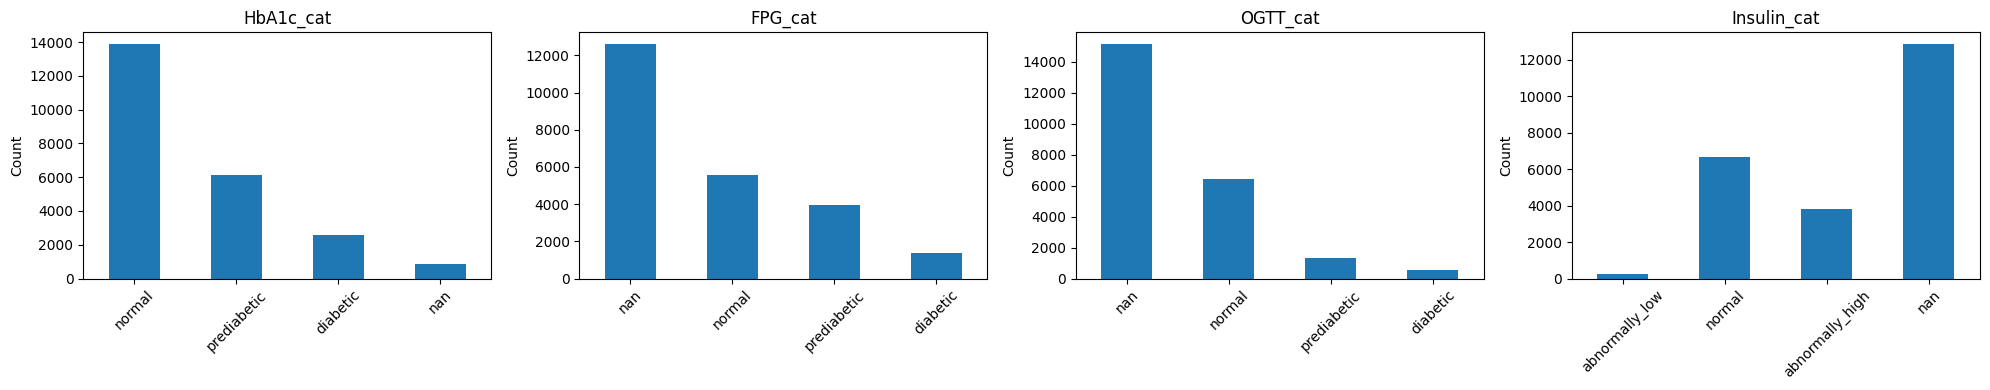

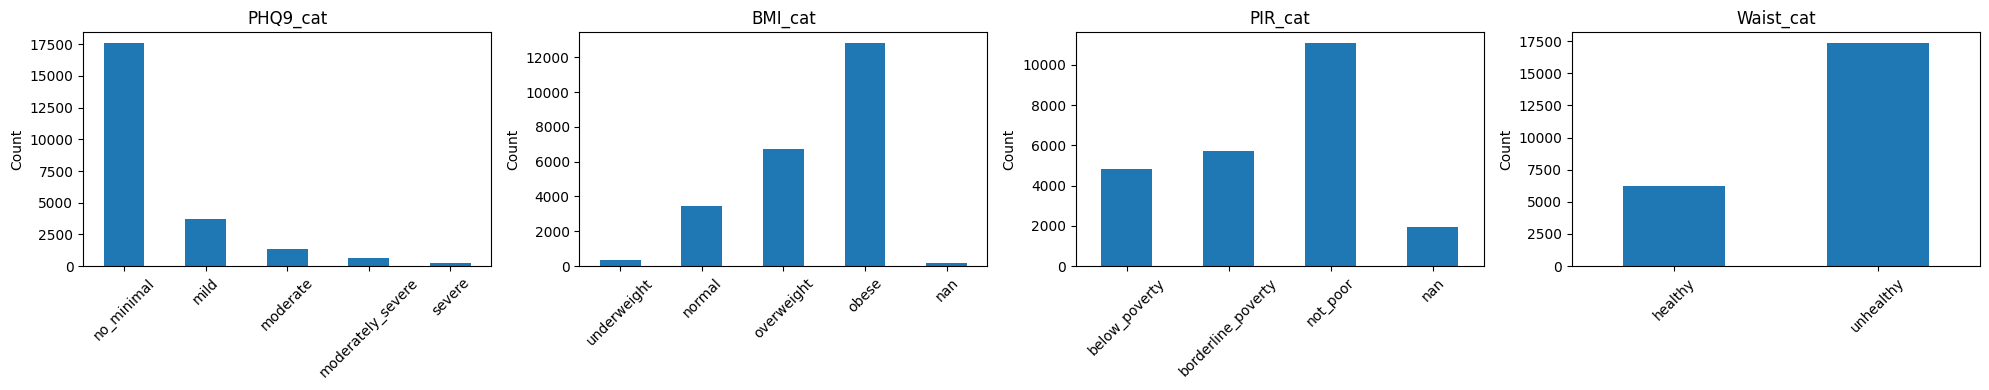

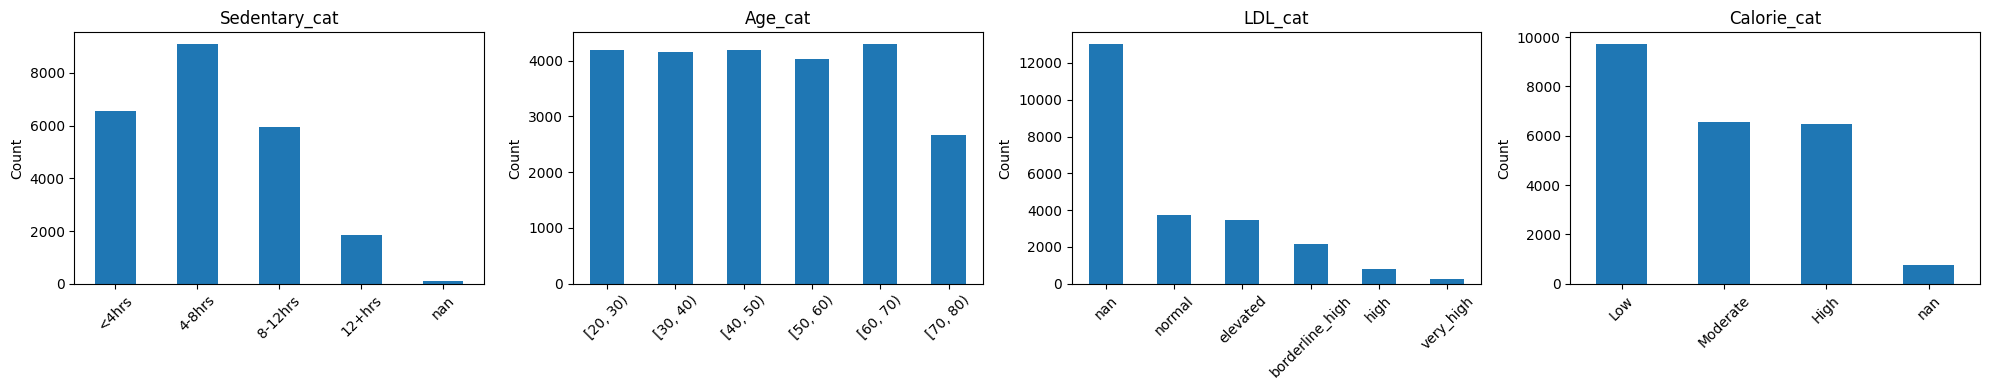

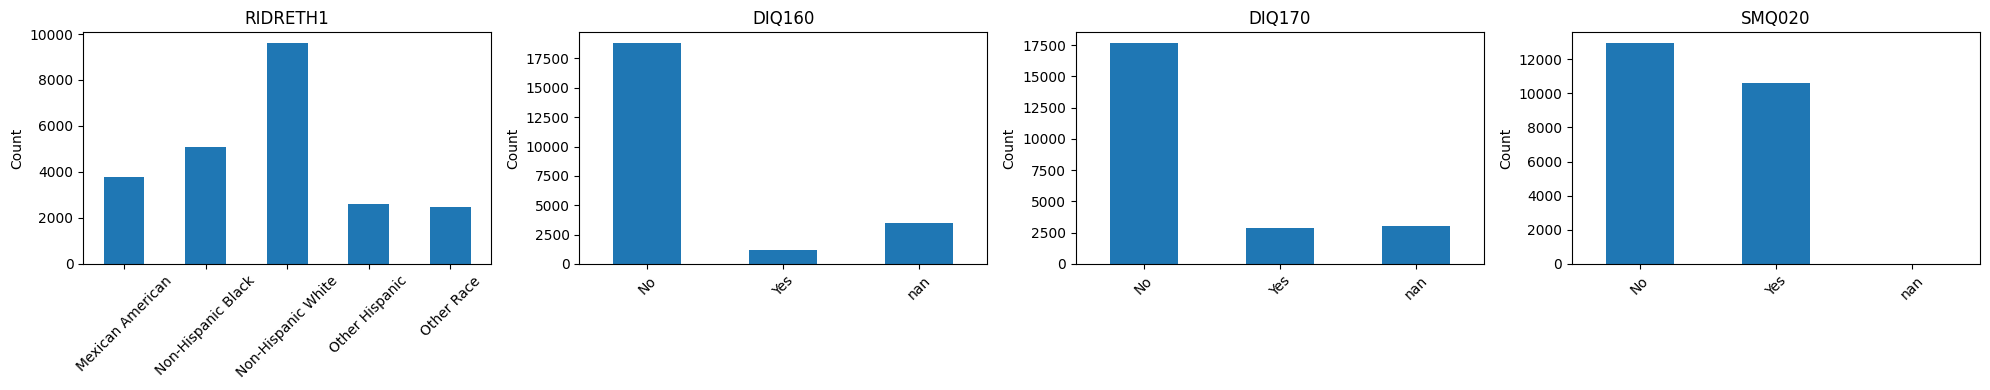

In [28]:
plot_categorical_distributions(df, cat_vars, chunk_size=4)


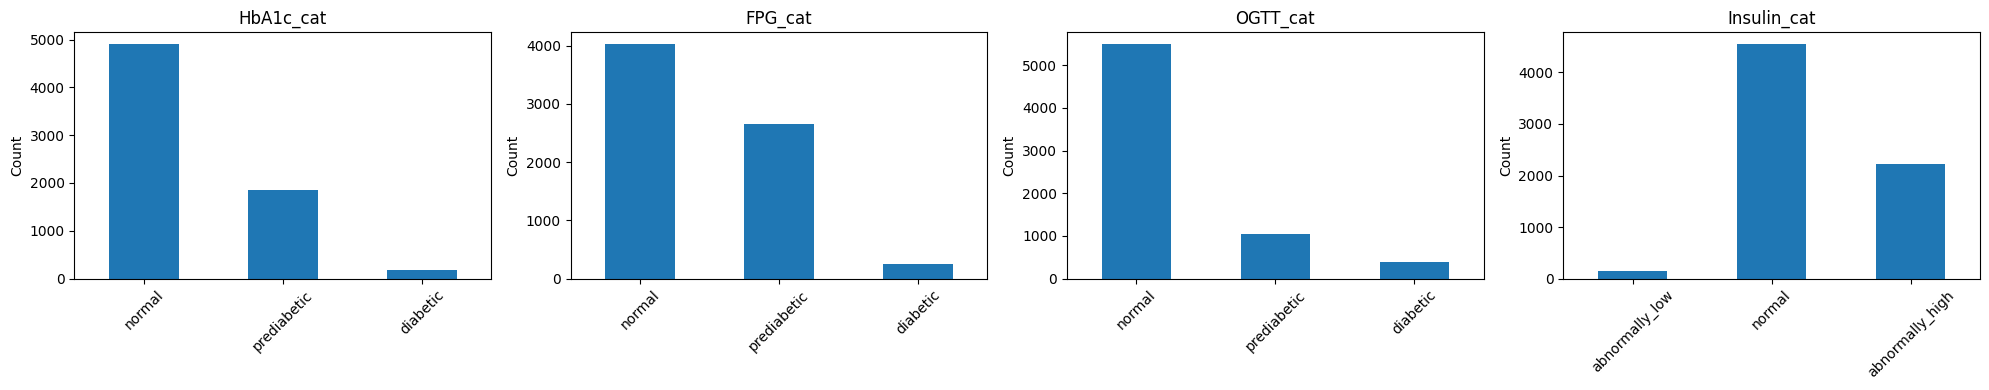

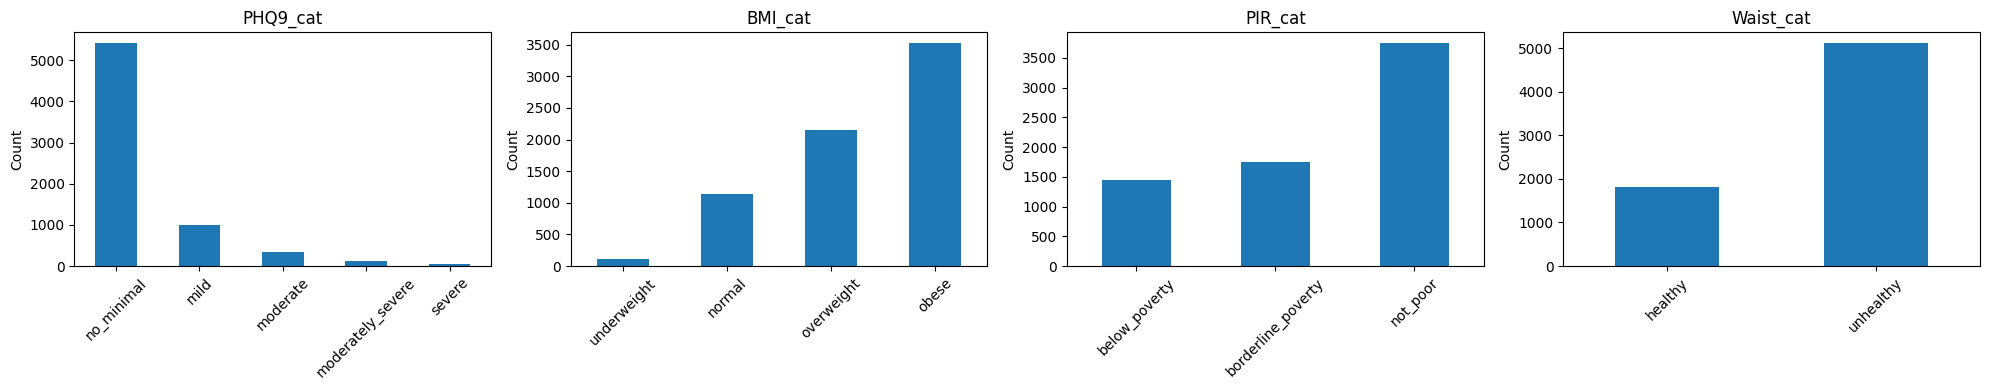

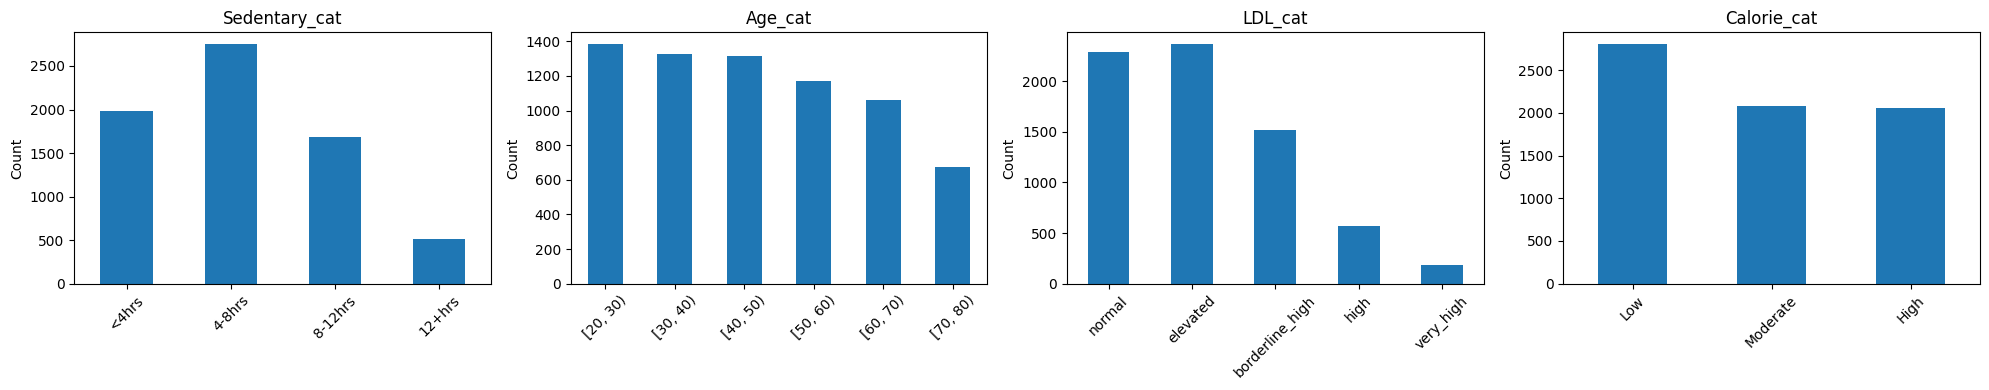

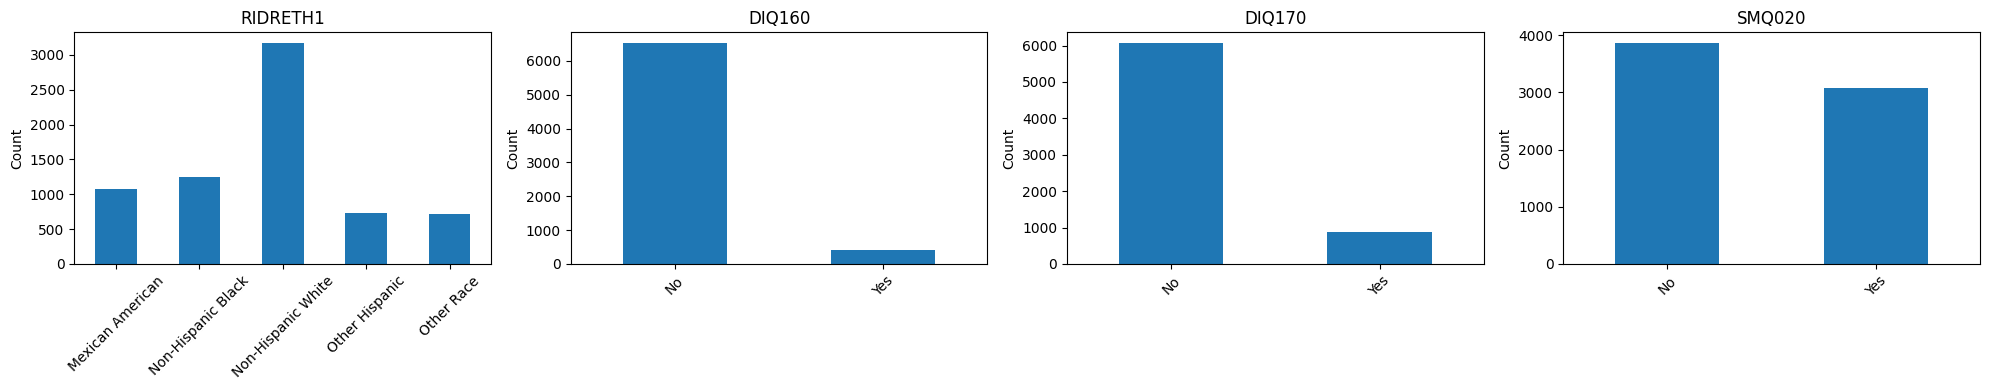

In [29]:
plot_categorical_distributions(df_model, cat_vars, chunk_size=4)

#### 1.3.3 Reclassification of dataset

Based on the visualisations above, the following variables contain categories that are too sparse and will be rebinned as below:

- HbA1c, fasting glucose, OGTT glucose -> 'prediabetics' reclassified as 'diabetic'
- PHQ-9 -> 'mild', 'moderate', 'moderately severe', 'severe' reclassified as 'depressed'
- BMI -> 'underweight' reclassified as 'normal'
- Poverty-Income Ratio -> 'below poverty line' and 'borderline poverty' reclassified together as 'in poverty'
- sedentary time -> '8-12hrs' and '12+hrs' reclassfied together as '8+hrs'
- age -> [60,70) and [70,80) reclassified together as [60,80)
- LDL cholesterol -> 'borderline_high', 'high', and 'very_high' reclassified together as 'high'

In [30]:
## reclassification of biomarkers

# HbA1c: normal vs diabetic (prediabetic merged)
df["HbA1c_cat"] = np.where(
    df["HbA1c_cat"] == "normal",
    "normal",
    "diabetic"
)

# Fasting glucose
df["FPG_cat"] = np.where(
    df["FPG_cat"] == "normal",
    "normal",
    "diabetic"
)

# OGTT glucose
df["OGTT_cat"] = np.where(
    df["OGTT_cat"] == "normal",
    "normal",
    "diabetic"
)


In [31]:
## reclassification of PHQ-9
df["PHQ9_cat"] = np.where(
    df["PHQ9_cat"] == "no_minimal",
    "not_depressed",
    "depressed"
)


In [32]:
## reclassification of BMI
df["BMI_cat"] = df["BMI_cat"].replace({
    "underweight": "normal"
})


/tmp/ipython-input-1832919551.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["BMI_cat"] = df["BMI_cat"].replace({


In [33]:
## reclassification of poverty status
df["PIR_cat"] = df["PIR_cat"].replace({
    "below_poverty": "in_poverty",
    "borderline_poverty": "in_poverty"
})


/tmp/ipython-input-2741219870.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["PIR_cat"] = df["PIR_cat"].replace({


In [34]:
## reclassification of sedentary time
df["Sedentary_cat"] = df["Sedentary_cat"].replace({
    "8-12hrs": "8h+",
    "12+hrs": "8h+"
})


/tmp/ipython-input-2439367619.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["Sedentary_cat"] = df["Sedentary_cat"].replace({


In [35]:
## reclassification of age groups
df["Age_cat"] = df["Age_cat"].cat.rename_categories({
    pd.Interval(70, 80, closed="left"): pd.Interval(60, 80, closed="left")
})

df["Age_cat"] = pd.Categorical(
    df["Age_cat"].apply(
        lambda x: pd.Interval(60, 80, closed="left") if x == pd.Interval(60, 70, closed="left") else x
    ),
    categories=[
        c for c in df["Age_cat"].cat.categories
        if c != pd.Interval(60, 70, closed="left")
    ],
    ordered=True
)


In [36]:
## reclassification of LDL cholesterol
df["LDL_cat"] = df["LDL_cat"].replace({
    "borderline_high": "high",
    "very_high": "high"
})


/tmp/ipython-input-3827286033.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df["LDL_cat"] = df["LDL_cat"].replace({


In [37]:
## Clean out NaN rows after reclassification
df_model = df.dropna()
print(f'Shape after reclassification: {df_model.shape}')

Shape after reclassification: (6929, 30)


Summary of classifications for all relevant variables:
| Variable                                | Final Categories        | Cut-offs / Definition                             |
| --------------------------------------- | ----------------------- | ------------------------------------------------- |
| **HbA1c (%)**                           | Normal                  | < 5.7%                                            |
|                                         | Diabetic                | ≥ 5.7% (prediabetes merged into diabetic)         |
| **Fasting Glucose (mmol/L)**            | Normal                  | < 5.6                                             |
|                                         | Diabetic                | ≥ 5.6 (prediabetes merged into diabetic)          |
| **OGTT Glucose (mmol/L)**               | Normal                  | < 7.8                                             |
|                                         | Diabetic                | ≥ 7.8 (prediabetes merged into diabetic)          |
| **Fasting Insulin (pmol/L)**             | Abnormally low          | < 15.1                                            |
|                                         | Normal                  | 15.1 – 78.8                                       |
|                                         | Abnormally high         | > 78.8                                            |
| **PHQ-9 Score**                         | No / Minimal depression | 0 – 4                                             |
|                                         | Depressed               | ≥ 5 (all higher categories merged)                |
| **BMI (kg/m²)**                         | Normal                  | < 23.0 (underweight merged with normal)           |
|                                         | Overweight              | 23.0 – 27.4                                       |
|                                         | Obese                   | ≥ 27.5                                            |
| **Poverty Income Ratio (PIR)**          | In poverty              | < 2.0 (below + borderline merged)                 |
|                                         | Not in poverty          | ≥ 2.0                                             |
| **Waist Circumference (cm)**            | Healthy                 | ≤ 94 (men), ≤ 80 (women)                          |
|                                         | Unhealthy               | > 94 (men), > 80 (women)                          |
| **Sedentary Time (hours/day)**          | < 4 h                   | < 4                                               |
|                                         | 4–8 h                   | 4 to < 8                                          |
|                                         | ≥ 8 h                   | ≥ 8 (8–12 h and 12+ h merged)                     |
| **Age (years)**                         | 20–29                   | 20 to < 30                                        |
|                                         | 30–39                   | 30 to < 40                                        |
|                                         | 40–49                   | 40 to < 50                                        |
|                                         | 50–59                   | 50 to < 60                                        |
|                                         | 60–79                   | 60 to ≤ 79 (merged [60–70) + [70–80))                 |
| **LDL Cholesterol (mg/dL)**             | Normal                  | < 100                                             |
|                                         | Elevated                | 100 – 129                                         |
|                                         | High                    | ≥ 130 (borderline high + high + very high merged) |
| **Calorie Intake (kcal/day)**           | Low                     | < 1800                                            |
|                                         | Moderate                | 1800 – 2500                                       |
|                                         | High                    | > 2500                                            |
| **Smoking Status (```SMQ020```)**             | Yes                     | Ever smoked ≥ 100 cigarettes                      |
|                                         | No                      | Never smoked                                      |
| **Prediabetes diagnosis (```DIQ160```)**      | Yes / No                | Self-reported                                     |
| **Family history of diabetes (```DIQ170```)** | Yes / No                | Self-reported                                     |
| **Sex (```RIAGENDR```)**                      | Male / Female           | NHANES coded                                      |
| **Ethnicity (```RIDRETH1```)**                | 5 categories            | NHANES standard                                   |



Replotting of bar charts to evaluate rebinned data

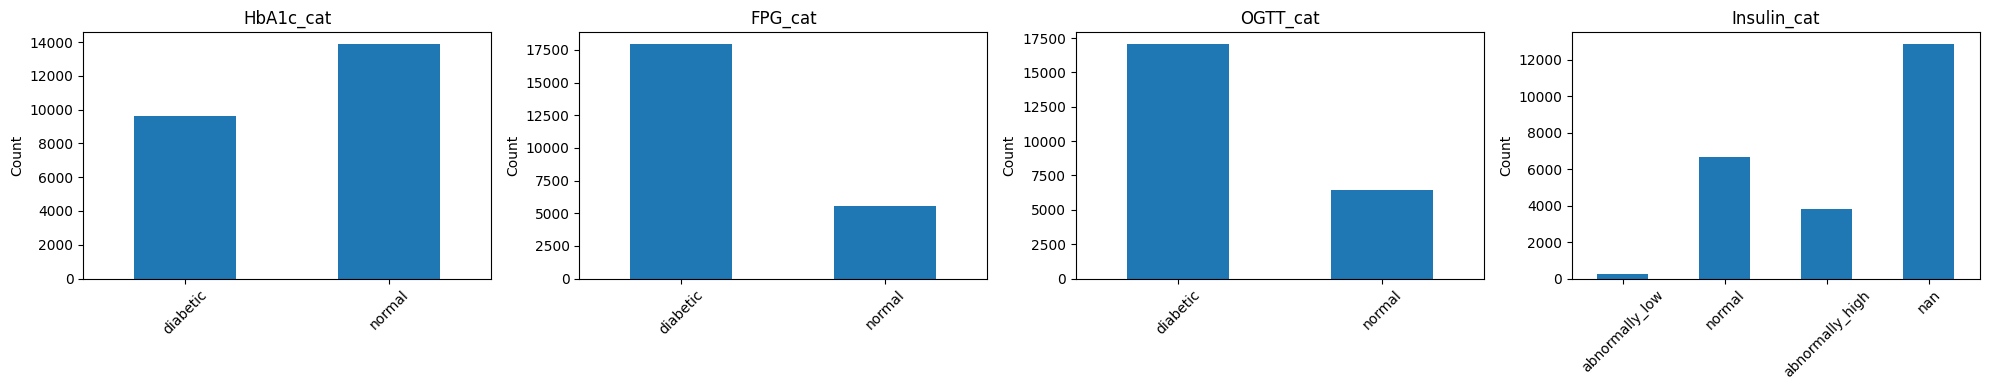

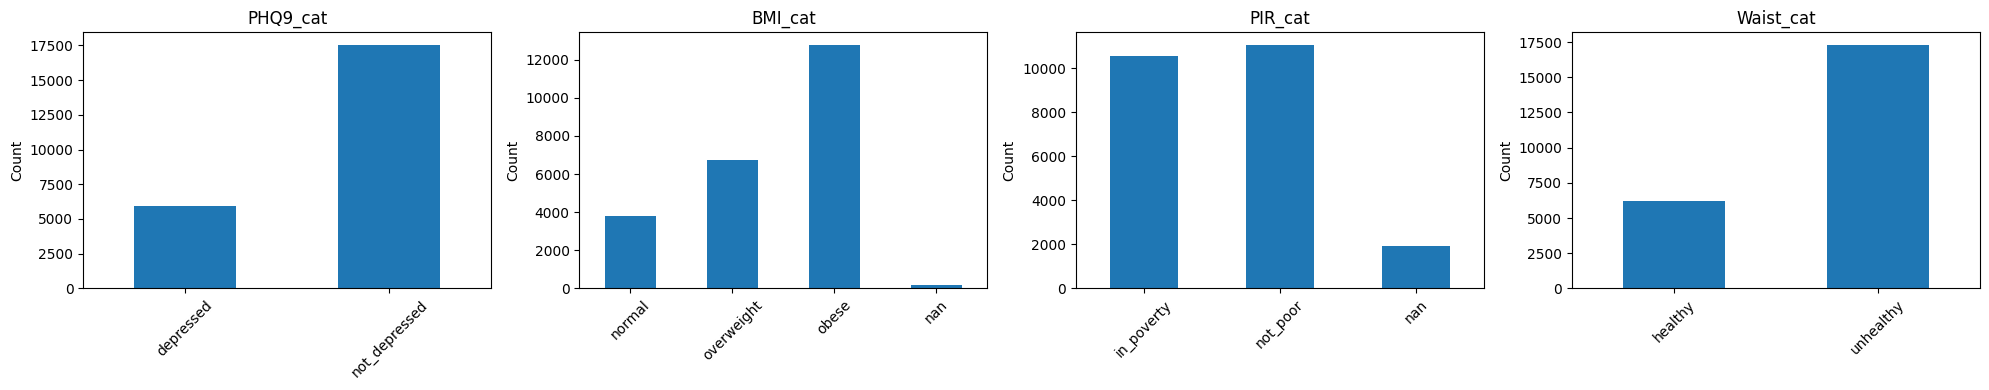

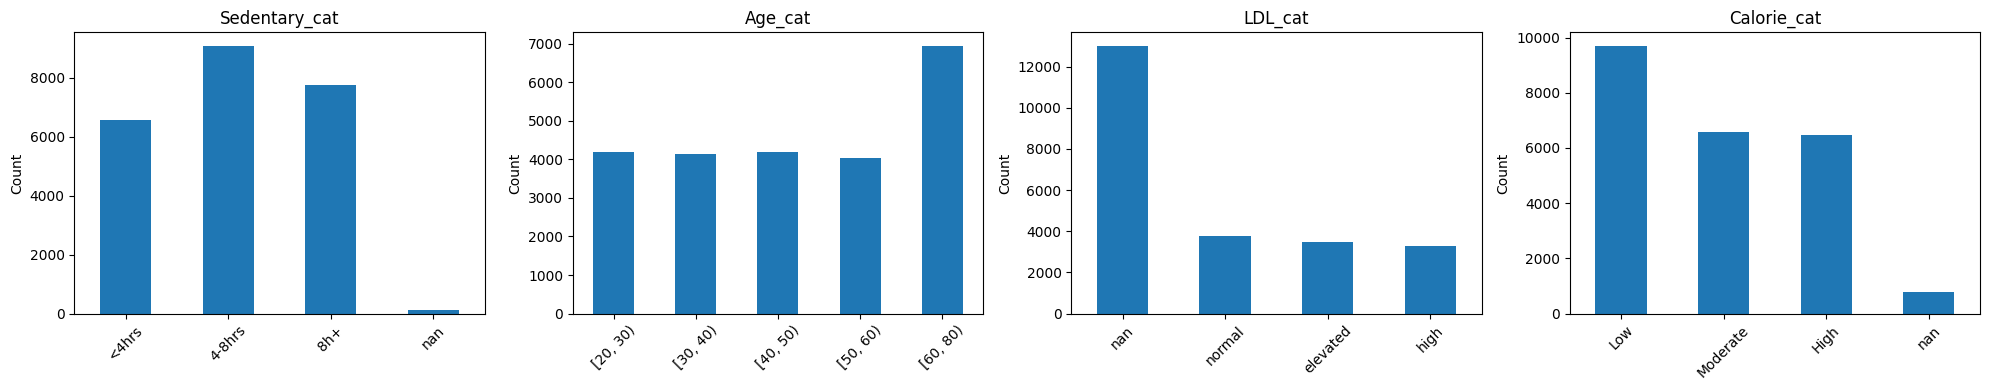

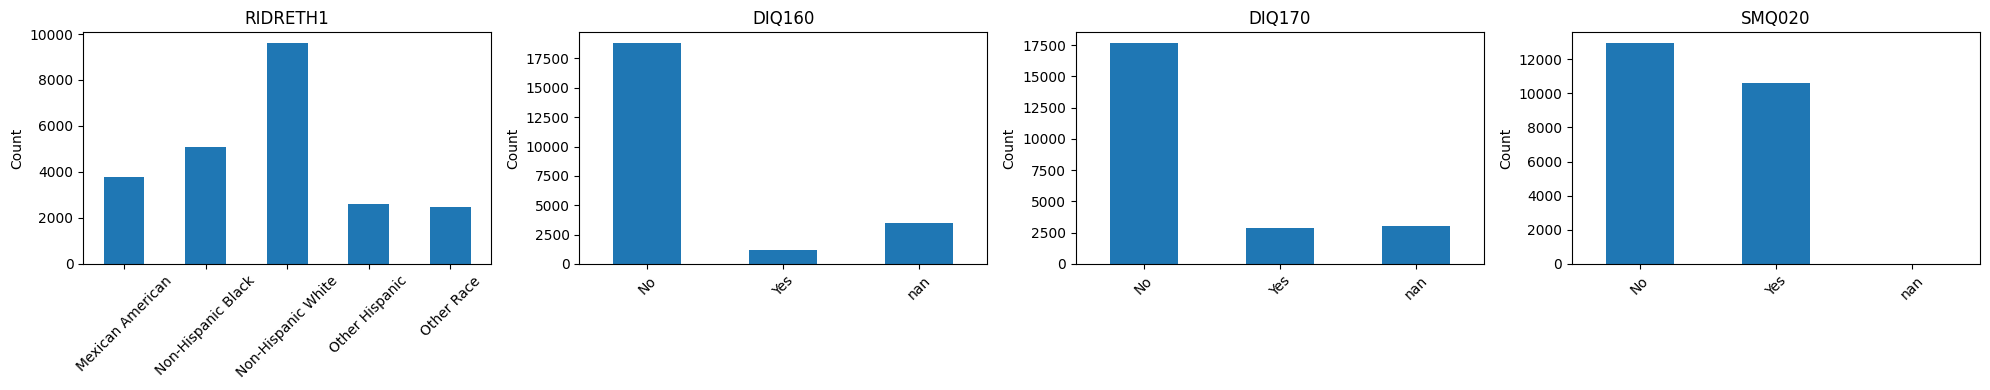

In [38]:
plot_categorical_distributions(df, cat_vars, chunk_size=4)


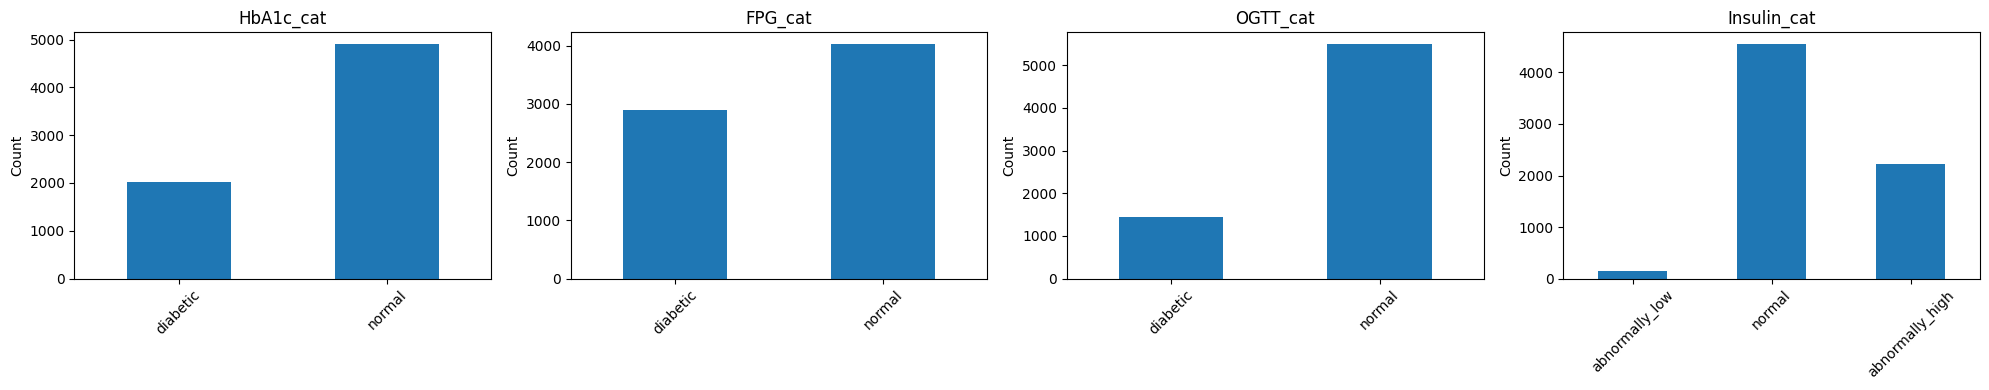

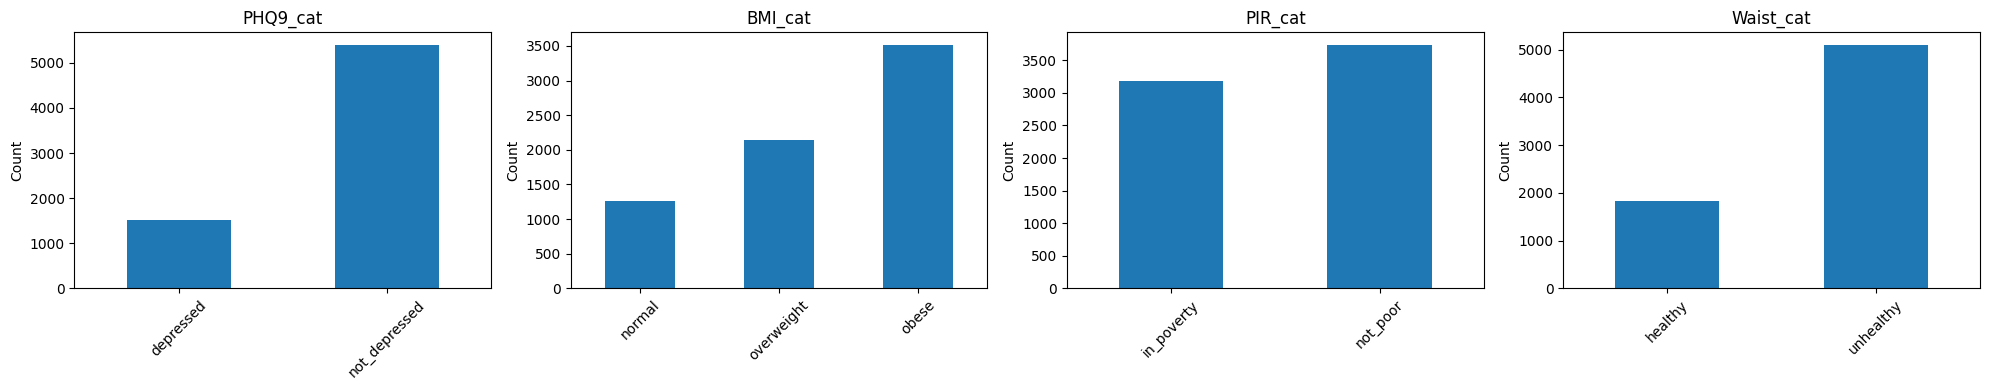

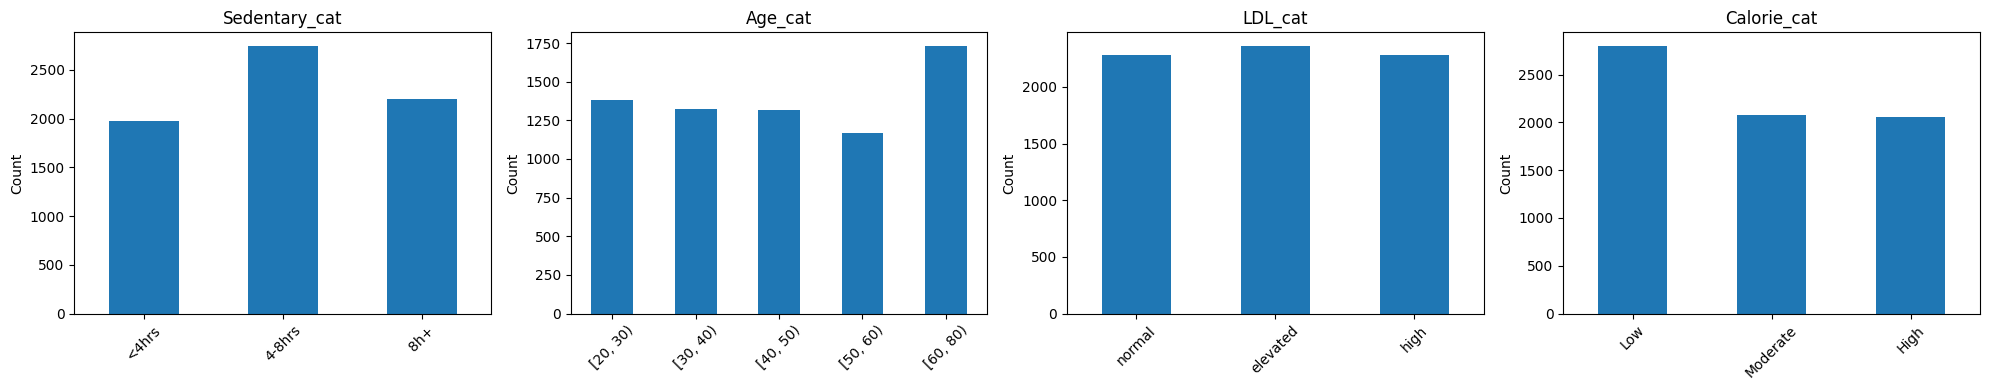

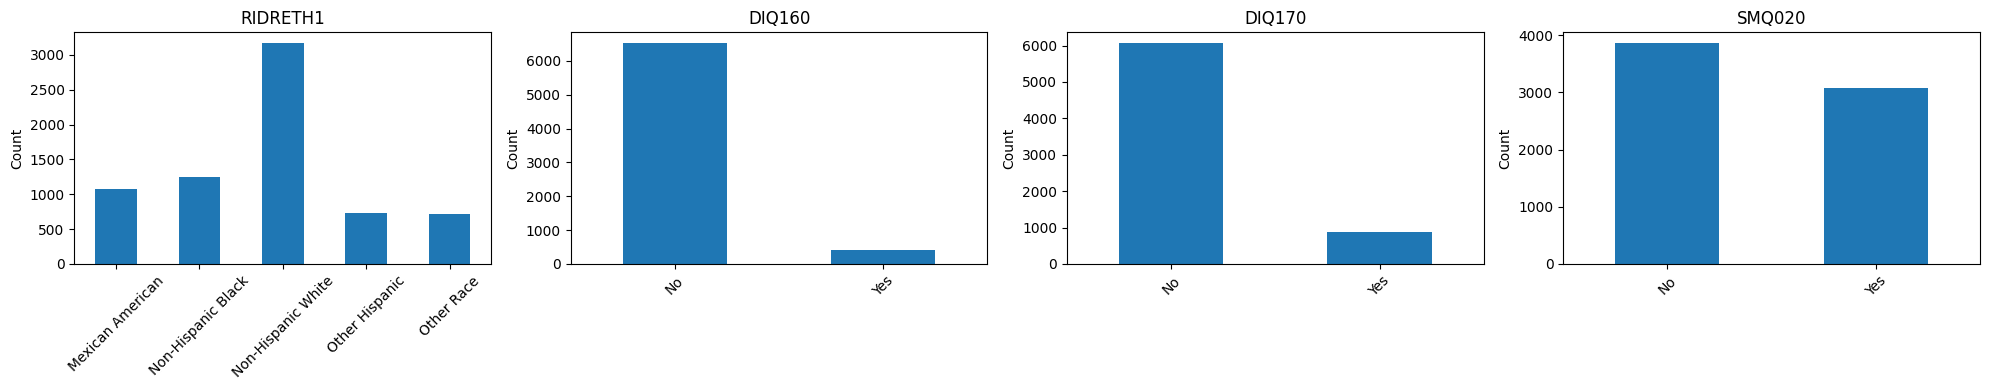

In [39]:
plot_categorical_distributions(df_model, cat_vars, chunk_size=4)


Final ```df_model``` for logistic regression use

In [40]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df_model[col] = df[col].astype('category')

df_model = df.reset_index(drop=True)

/tmp/ipython-input-3522190787.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col] = df[col].astype('category')
/tmp/ipython-input-3522190787.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model[col] = df[col].astype('category')
/tmp/ipython-input-3522190787.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/s

In [41]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23529 entries, 0 to 23528
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   SEQN           23529 non-null  int64   
 1   RIDAGEYR       23529 non-null  Int64   
 2   RIAGENDR       23529 non-null  object  
 3   RIDRETH1       23529 non-null  object  
 4   INDFMPIR       21599 non-null  float64 
 5   DIQ160         20010 non-null  object  
 6   DIQ170         20509 non-null  object  
 7   SMQ020         23515 non-null  object  
 8   BMXWAIST       22875 non-null  float64 
 9   BMXBMI         23332 non-null  float64 
 10  DR1TKCAL       22763 non-null  float64 
 11  PAD680         23422 non-null  float64 
 12  LBDLDL         10513 non-null  float64 
 13  LBDGLUSI       10915 non-null  float64 
 14  LBXGH          22651 non-null  float64 
 15  LBDGLTSI       8371 non-null   float64 
 16  LBDINSI        10678 non-null  float64 
 17  PHQ9_total     23529 non-null  

In [42]:
df_model

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,INDFMPIR,DIQ160,DIQ170,SMQ020,BMXWAIST,BMXBMI,...,OGTT_cat,Insulin_cat,PHQ9_cat,BMI_cat,PIR_cat,Waist_cat,Sedentary_cat,Age_cat,LDL_cat,Calorie_cat
0,41475,62,Female,Other Race,1.83,No,Yes,No,156.3,58.04,...,diabetic,NaN,depressed,obese,in_poverty,unhealthy,8h+,"[60, 80)",NaN,Low
1,41477,71,Male,Non-Hispanic White,1.50,NaN,NaN,Yes,109.5,30.05,...,diabetic,NaN,not_depressed,obese,in_poverty,unhealthy,4-8hrs,"[60, 80)",NaN,Low
2,41479,52,Male,Mexican American,2.20,No,No,No,95.4,27.56,...,normal,normal,not_depressed,obese,not_poor,unhealthy,<4hrs,"[50, 60)",elevated,High
3,41481,21,Male,Non-Hispanic Black,1.63,No,No,No,79.5,23.34,...,diabetic,NaN,not_depressed,overweight,in_poverty,healthy,4-8hrs,"[20, 30)",NaN,High
4,41483,66,Male,Non-Hispanic Black,1.14,NaN,NaN,No,145.6,44.06,...,diabetic,NaN,not_depressed,obese,in_poverty,unhealthy,<4hrs,"[60, 80)",NaN,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23524,93690,32,Male,Other Hispanic,5.00,No,Yes,No,101.0,32.90,...,diabetic,NaN,not_depressed,obese,not_poor,unhealthy,8h+,"[30, 40)",NaN,High
23525,93691,25,Male,Other Race,1.59,No,No,No,75.4,21.00,...,diabetic,NaN,not_depressed,normal,in_poverty,healthy,4-8hrs,"[20, 30)",NaN,Moderate
23526,93695,76,Female,Non-Hispanic White,1.43,No,No,Yes,95.0,21.50,...,normal,abnormally_high,not_depressed,normal,in_poverty,unhealthy,4-8hrs,"[60, 80)",normal,Low
23527,93696,26,Male,Non-Hispanic White,2.99,No,Yes,No,110.2,33.80,...,diabetic,NaN,not_depressed,obese,not_poor,unhealthy,8h+,"[20, 30)",NaN,Moderate


In [43]:
df_model.columns

Index(['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'INDFMPIR', 'DIQ160',
       'DIQ170', 'SMQ020', 'BMXWAIST', 'BMXBMI', 'DR1TKCAL', 'PAD680',
       'LBDLDL', 'LBDGLUSI', 'LBXGH', 'LBDGLTSI', 'LBDINSI', 'PHQ9_total',
       'HbA1c_cat', 'FPG_cat', 'OGTT_cat', 'Insulin_cat', 'PHQ9_cat',
       'BMI_cat', 'PIR_cat', 'Waist_cat', 'Sedentary_cat', 'Age_cat',
       'LDL_cat', 'Calorie_cat'],
      dtype='object')

# **2. Data exploration**

In [44]:
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df_model[col] = df[col].astype('category')

df_model = df.reset_index(drop=True)

In [45]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23529 entries, 0 to 23528
Data columns (total 30 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   SEQN           23529 non-null  int64   
 1   RIDAGEYR       23529 non-null  Int64   
 2   RIAGENDR       23529 non-null  object  
 3   RIDRETH1       23529 non-null  object  
 4   INDFMPIR       21599 non-null  float64 
 5   DIQ160         20010 non-null  object  
 6   DIQ170         20509 non-null  object  
 7   SMQ020         23515 non-null  object  
 8   BMXWAIST       22875 non-null  float64 
 9   BMXBMI         23332 non-null  float64 
 10  DR1TKCAL       22763 non-null  float64 
 11  PAD680         23422 non-null  float64 
 12  LBDLDL         10513 non-null  float64 
 13  LBDGLUSI       10915 non-null  float64 
 14  LBXGH          22651 non-null  float64 
 15  LBDGLTSI       8371 non-null   float64 
 16  LBDINSI        10678 non-null  float64 
 17  PHQ9_total     23529 non-null  

In [46]:
df_model

,SEQN,RIDAGEYR,RIAGENDR,RIDRETH1,INDFMPIR,DIQ160,DIQ170,SMQ020,BMXWAIST,BMXBMI,...,OGTT_cat,Insulin_cat,PHQ9_cat,BMI_cat,PIR_cat,Waist_cat,Sedentary_cat,Age_cat,LDL_cat,Calorie_cat
0,41475,62,Female,Other Race,1.83,No,Yes,No,156.3,58.04,...,diabetic,NaN,depressed,obese,in_poverty,unhealthy,8h+,"[60, 80)",NaN,Low
1,41477,71,Male,Non-Hispanic White,1.50,NaN,NaN,Yes,109.5,30.05,...,diabetic,NaN,not_depressed,obese,in_poverty,unhealthy,4-8hrs,"[60, 80)",NaN,Low
2,41479,52,Male,Mexican American,2.20,No,No,No,95.4,27.56,...,normal,normal,not_depressed,obese,not_poor,unhealthy,<4hrs,"[50, 60)",elevated,High
3,41481,21,Male,Non-Hispanic Black,1.63,No,No,No,79.5,23.34,...,diabetic,NaN,not_depressed,overweight,in_poverty,healthy,4-8hrs,"[20, 30)",NaN,High
4,41483,66,Male,Non-Hispanic Black,1.14,NaN,NaN,No,145.6,44.06,...,diabetic,NaN,not_depressed,obese,in_poverty,unhealthy,<4hrs,"[60, 80)",NaN,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23524,93690,32,Male,Other Hispanic,5.00,No,Yes,No,101.0,32.90,...,diabetic,NaN,not_depressed,obese,not_poor,unhealthy,8h+,"[30, 40)",NaN,High
23525,93691,25,Male,Other Race,1.59,No,No,No,75.4,21.00,...,diabetic,NaN,not_depressed,normal,in_poverty,healthy,4-8hrs,"[20, 30)",NaN,Moderate
23526,93695,76,Female,Non-Hispanic White,1.43,No,No,Yes,95.0,21.50,...,normal,abnormally_high,not_depressed,normal,in_poverty,unhealthy,4-8hrs,"[60, 80)",normal,Low
23527,93696,26,Male,Non-Hispanic White,2.99,No,Yes,No,110.2,33.80,...,diabetic,NaN,not_depressed,obese,not_poor,unhealthy,8h+,"[20, 30)",NaN,Moderate


In [47]:
df_model.columns

Index(['SEQN', 'RIDAGEYR', 'RIAGENDR', 'RIDRETH1', 'INDFMPIR', 'DIQ160',
       'DIQ170', 'SMQ020', 'BMXWAIST', 'BMXBMI', 'DR1TKCAL', 'PAD680',
       'LBDLDL', 'LBDGLUSI', 'LBXGH', 'LBDGLTSI', 'LBDINSI', 'PHQ9_total',
       'HbA1c_cat', 'FPG_cat', 'OGTT_cat', 'Insulin_cat', 'PHQ9_cat',
       'BMI_cat', 'PIR_cat', 'Waist_cat', 'Sedentary_cat', 'Age_cat',
       'LDL_cat', 'Calorie_cat'],
      dtype='object')

##Grouped Bar Charts

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

def grouped_bar_all_vars(
    df,
    group_col,
    exclude_cols=("SEQN",),
    max_levels=8,
    use_proportion=True,
    ncols=3,
    figsize_per_plot=(5.2, 4.0),
    min_group_n=30
):
    """
    Plots grouped bar charts for ALL categorical/binary variables against ONE grouping column.

    group_col: column used on x-axis (e.g., 'HbA1c_cat' or 'Age_cat')
    max_levels: skip variables with too many categories (messy)
    use_proportion: True plots %, False plots raw counts
    min_group_n: drops tiny group_col categories to avoid misleading plots
    """

    if group_col not in df.columns:
        raise KeyError(f"'{group_col}' not found in df. Available columns include: {list(df.columns)[:50]}")

    # --- pick candidate categorical/binary columns automatically ---
    cat_cols = []
    for c in df.columns:
        if c == group_col or c in exclude_cols:
            continue

        # include categorical/object/bool
        if (pd.api.types.is_object_dtype(df[c]) or
            pd.api.types.is_categorical_dtype(df[c]) or
            pd.api.types.is_bool_dtype(df[c])):
            cat_cols.append(c)

        # also include low-cardinality integer columns (often already categorised)
        elif pd.api.types.is_integer_dtype(df[c]) and df[c].nunique(dropna=True) <= max_levels:
            cat_cols.append(c)

    # filter: keep only variables with 2..max_levels categories
    usable = []
    for c in cat_cols:
        nunq = df[c].nunique(dropna=True)
        if 2 <= nunq <= max_levels:
            usable.append(c)

    if not usable:
        raise ValueError("No usable categorical/binary variables found. Increase max_levels or check your data types.")

    # optional: drop tiny group categories
    group_counts = df[group_col].value_counts(dropna=True)
    keep_groups = group_counts[group_counts >= min_group_n].index
    d_main = df[df[group_col].isin(keep_groups)].copy()

    n_plots = len(usable)
    nrows = math.ceil(n_plots / ncols)

    fig_w = ncols * figsize_per_plot[0]
    fig_h = nrows * figsize_per_plot[1]
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))
    axes = np.array(axes).reshape(-1)

    for i, var in enumerate(usable):
        ax = axes[i]

        tmp = d_main[[group_col, var]].dropna()

        if use_proportion:
            ct = pd.crosstab(tmp[group_col], tmp[var], normalize="index") * 100
            ylabel = "Proportion within group (%)"
        else:
            ct = pd.crosstab(tmp[group_col], tmp[var])
            ylabel = "Count"

        ct = ct.round(1)

        ct.plot(kind="bar", ax=ax, width=0.85)
        ax.set_title(f"{var} by {group_col}", fontsize=10)
        ax.set_xlabel(group_col)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=30)
        ax.legend(title=var, fontsize=8, title_fontsize=9, loc="best")

    # turn off unused axes
    for j in range(n_plots, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"✅ Grouped bar charts created for {n_plots} variables vs '{group_col}'")
    print("Plotted variables:", usable)

    return usable

##How are predictors distributed between normal and abnormal biomarker groups

/tmp/ipython-input-2226518493.py:28: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  pd.api.types.is_categorical_dtype(df[c]) or


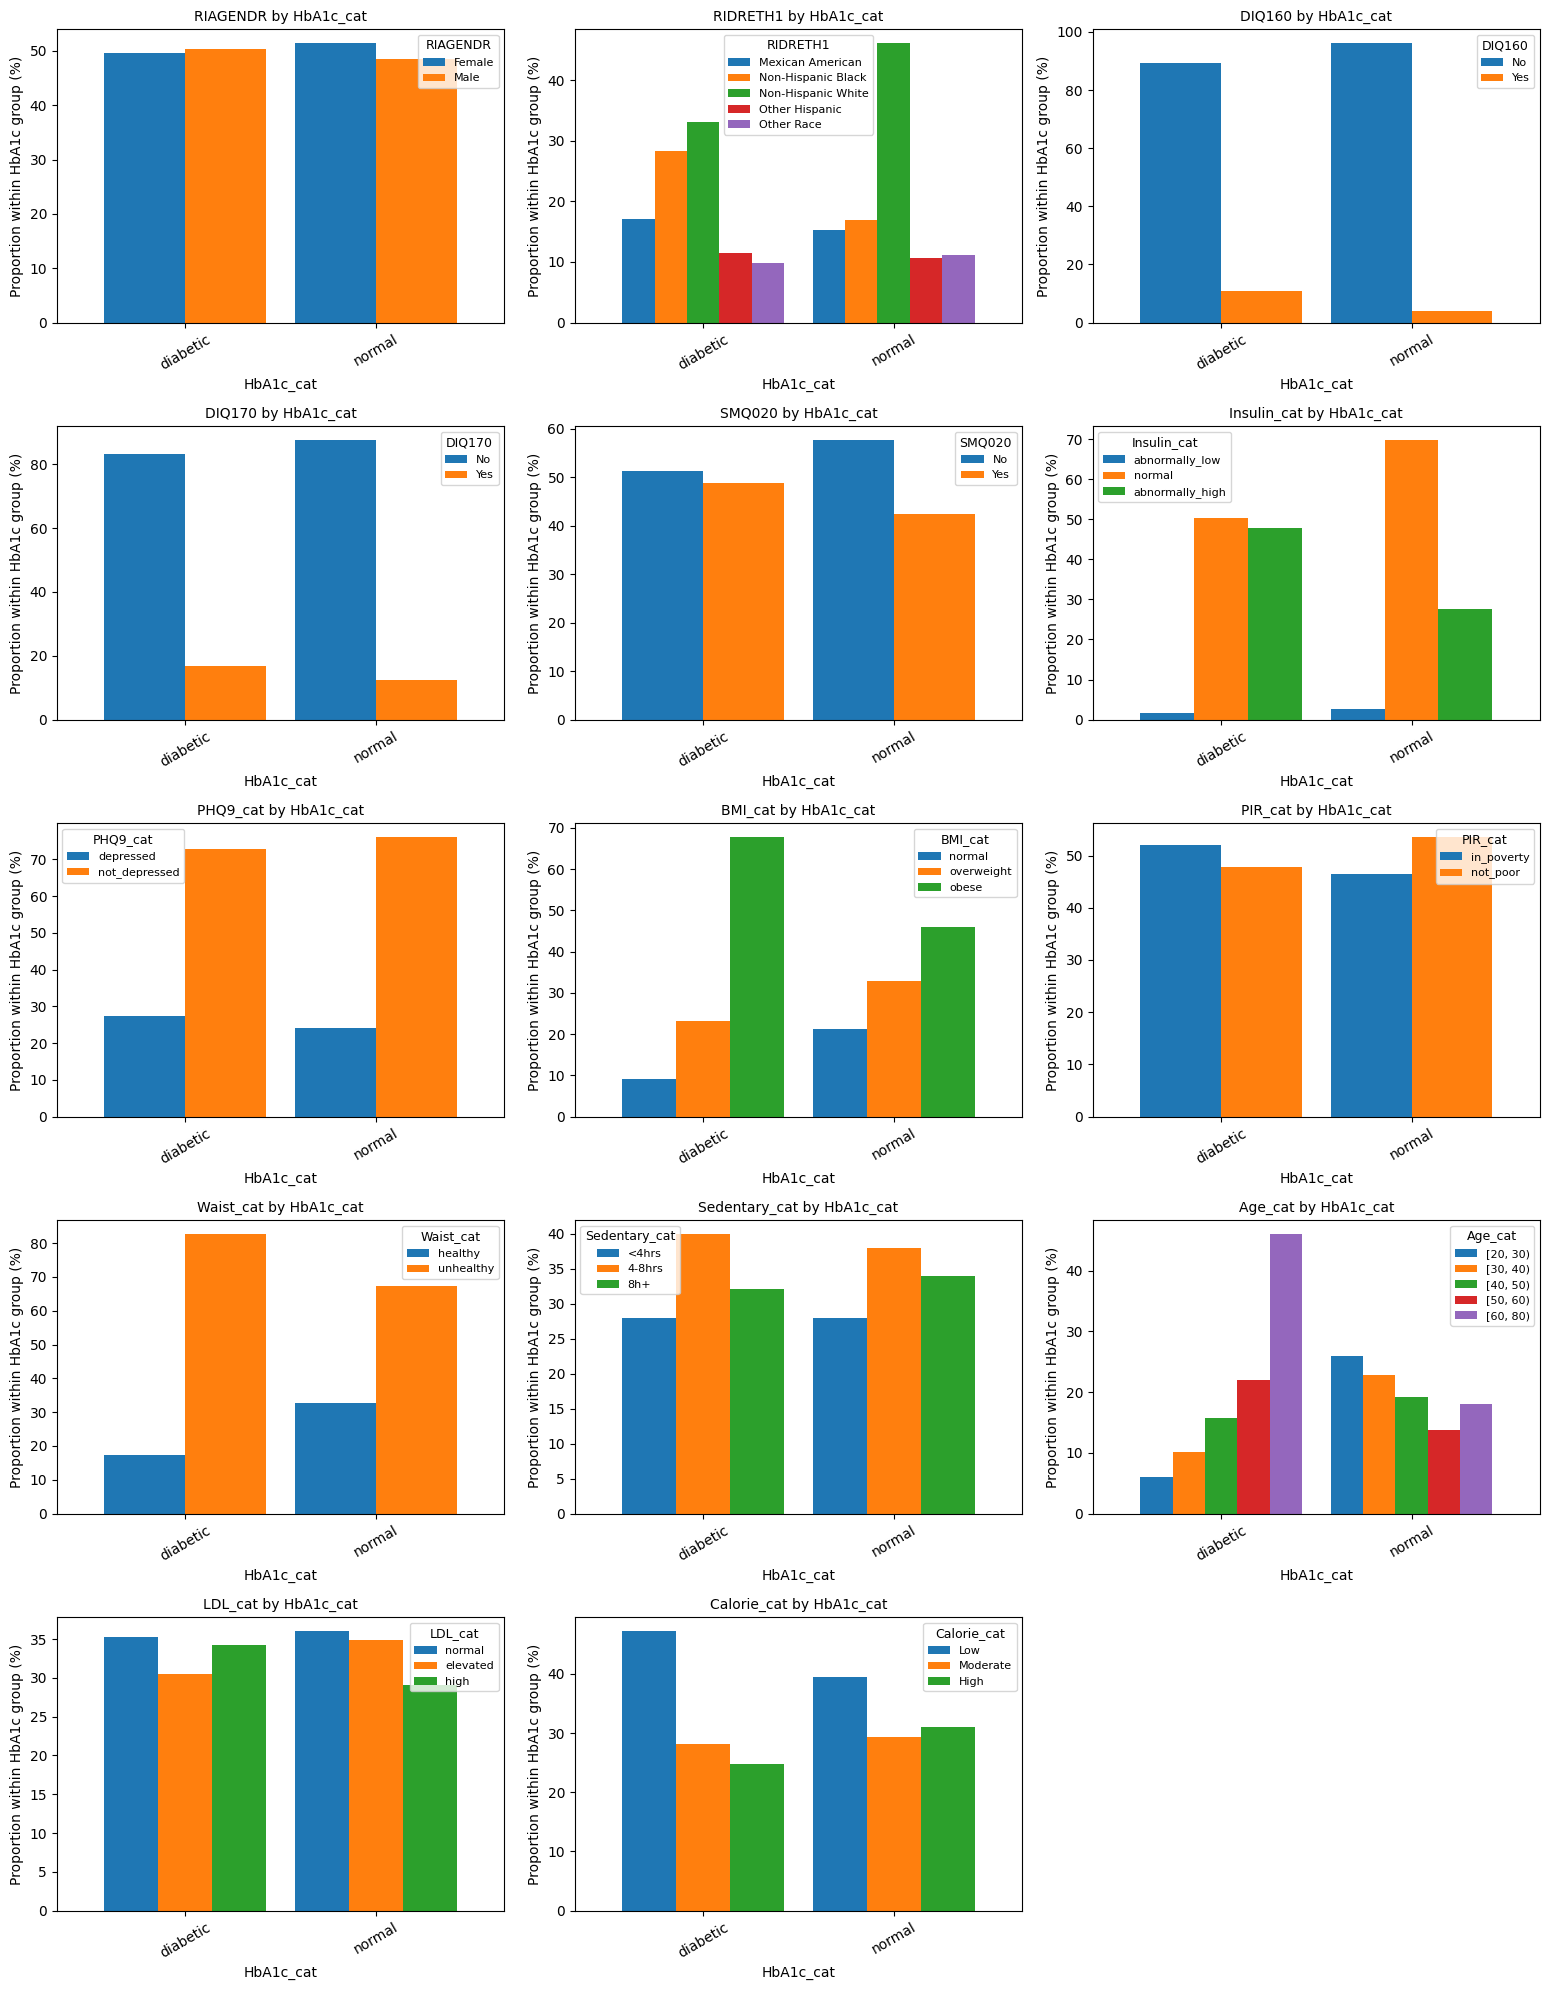

✅ Plotted 14 grouped bar charts vs 'HbA1c_cat'
Excluded columns: ['FPG_cat', 'OGTT_cat', 'SEQN']
Variables plotted: ['RIAGENDR', 'RIDRETH1', 'DIQ160', 'DIQ170', 'SMQ020', 'Insulin_cat', 'PHQ9_cat', 'BMI_cat', 'PIR_cat', 'Waist_cat', 'Sedentary_cat', 'Age_cat', 'LDL_cat', 'Calorie_cat']


In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

def grouped_bar_all_vars_excluding(df, group_col, exclude=None, max_levels=8, use_proportion=True,
                                   ncols=3, figsize_per_plot=(5.2, 4.0), min_group_n=30):
    """
    Plot grouped bar charts for all categorical/binary variables vs group_col,
    excluding any columns listed in `exclude`.
    """
    if exclude is None:
        exclude = []
    exclude = set(exclude)

    if group_col not in df.columns:
        raise KeyError(f"'{group_col}' not found in df columns.")

    # Build candidate column list (categorical-like)
    cat_cols = []
    for c in df.columns:
        if c == group_col:
            continue
        if c in exclude:
            continue

        if (pd.api.types.is_object_dtype(df[c]) or
            pd.api.types.is_categorical_dtype(df[c]) or
            pd.api.types.is_bool_dtype(df[c])):
            cat_cols.append(c)
        elif pd.api.types.is_integer_dtype(df[c]) and df[c].nunique(dropna=True) <= max_levels:
            cat_cols.append(c)

    # Filter by category count
    usable = []
    for c in cat_cols:
        nunq = df[c].nunique(dropna=True)
        if 2 <= nunq <= max_levels:
            usable.append(c)

    # Drop tiny group categories (optional safety)
    group_counts = df[group_col].value_counts(dropna=True)
    keep_groups = group_counts[group_counts >= min_group_n].index
    d_main = df[df[group_col].isin(keep_groups)].copy()

    if len(usable) == 0:
        raise ValueError("No usable predictor variables found after exclusions. Try increasing max_levels.")

    n_plots = len(usable)
    nrows = math.ceil(n_plots / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*figsize_per_plot[0], nrows*figsize_per_plot[1]))
    axes = np.array(axes).reshape(-1)

    for i, var in enumerate(usable):
        ax = axes[i]
        tmp = d_main[[group_col, var]].dropna()

        if use_proportion:
            ct = pd.crosstab(tmp[group_col], tmp[var], normalize="index") * 100
            ylabel = "Proportion within HbA1c group (%)"
        else:
            ct = pd.crosstab(tmp[group_col], tmp[var])
            ylabel = "Count"

        ct = ct.round(1)
        ct.plot(kind="bar", ax=ax, width=0.85)

        ax.set_title(f"{var} by {group_col}", fontsize=10)
        ax.set_xlabel(group_col)
        ax.set_ylabel(ylabel)
        ax.tick_params(axis="x", rotation=30)
        ax.legend(title=var, fontsize=8, title_fontsize=9, loc="best")

    # Turn off unused subplots
    for j in range(n_plots, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

    print(f"✅ Plotted {n_plots} grouped bar charts vs '{group_col}'")
    print("Excluded columns:", sorted(list(exclude)))
    return usable

# ===== RUN THIS =====
usable = grouped_bar_all_vars_excluding(
    df=df,
    group_col="HbA1c_cat",
    exclude=[
        "FPG_cat", "OGTT_cat",   # remove these
        "SEQN"                   # remove ID if present
    ],
    max_levels=8,
    use_proportion=True,
    ncols=3
)

print("Variables plotted:", usable)

In [50]:
biomarkers = ["HbA1c_cat", "FPG_cat", "OGTT_cat", "Insulin_cat"]

predictors = [
    "Age_cat", "Sex_cat", "Ethnicity_cat",
    "PIR_cat", "Education_cat",
    "Smoking_cat", "Alcohol_cat", "Sedentary_cat", "PhysicalActivity_cat",
    "BMI_cat", "Waist_cat", "Hypertension_cat", "Diabetes_cat"
]

missing = [c for c in biomarkers + predictors if c not in df.columns]
print("Missing columns:", missing)

Missing columns: ['Sex_cat', 'Ethnicity_cat', 'Education_cat', 'Smoking_cat', 'Alcohol_cat', 'PhysicalActivity_cat', 'Hypertension_cat', 'Diabetes_cat']


In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

biomarkers = ["OGTT_cat", "HbA1c_cat", "FPG_cat", "Insulin_cat"]

def plot_category_grid(df, predictors, category_name, biomarkers=biomarkers, ncols=3, figsize_per_plot=(5.2, 4.0)):
    """
    Makes ONE big grid of grouped bar charts for:
    (each predictor) x (each biomarker).

    Each subplot: predictor distribution across biomarker groups (row-normalized %).
    Total plots = len(predictors) * len(biomarkers).
    """
    total = len(predictors) * len(biomarkers)
    nrows = math.ceil(total / ncols)

    fig_w = ncols * figsize_per_plot[0]
    fig_h = nrows * figsize_per_plot[1]
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))
    axes = np.array(axes).reshape(-1)

    plot_i = 0
    for predictor in predictors:
        for biomarker in biomarkers:
            ax = axes[plot_i]
            plot_i += 1

            # drop NA for this pair
            d = df[[biomarker, predictor]].dropna()

            # row-normalized proportions (% within biomarker group)
            ct = pd.crosstab(d[biomarker], d[predictor], normalize="index") * 100
            ct = ct.round(1)

            ct.plot(kind="bar", ax=ax, width=0.85, legend=False)

            ax.set_title(f"{predictor} by {biomarker}", fontsize=10)
            ax.set_xlabel(biomarker)
            ax.set_ylabel("% within biomarker group")
            ax.tick_params(axis="x", rotation=25)

    # Turn off unused subplots (if any)
    for j in range(plot_i, len(axes)):
        axes[j].axis("off")

    # One shared legend for the whole figure (using the last computed ct)
    # Create legend from the last axis that has bars
    handles, labels = axes[plot_i-1].get_legend_handles_labels()
    if labels:
        fig.legend(handles, labels, title="Predictor categories", bbox_to_anchor=(1.01, 1), loc="upper left")

    fig.suptitle(f"{category_name}: Predictors across Biomarker Groups (OGTT, HbA1c, FPG)", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    print(f"✅ {category_name}: plotted {total} charts ({len(predictors)} predictors × {len(biomarkers)} biomarkers)")

###Analysis of biomarkers by demographics

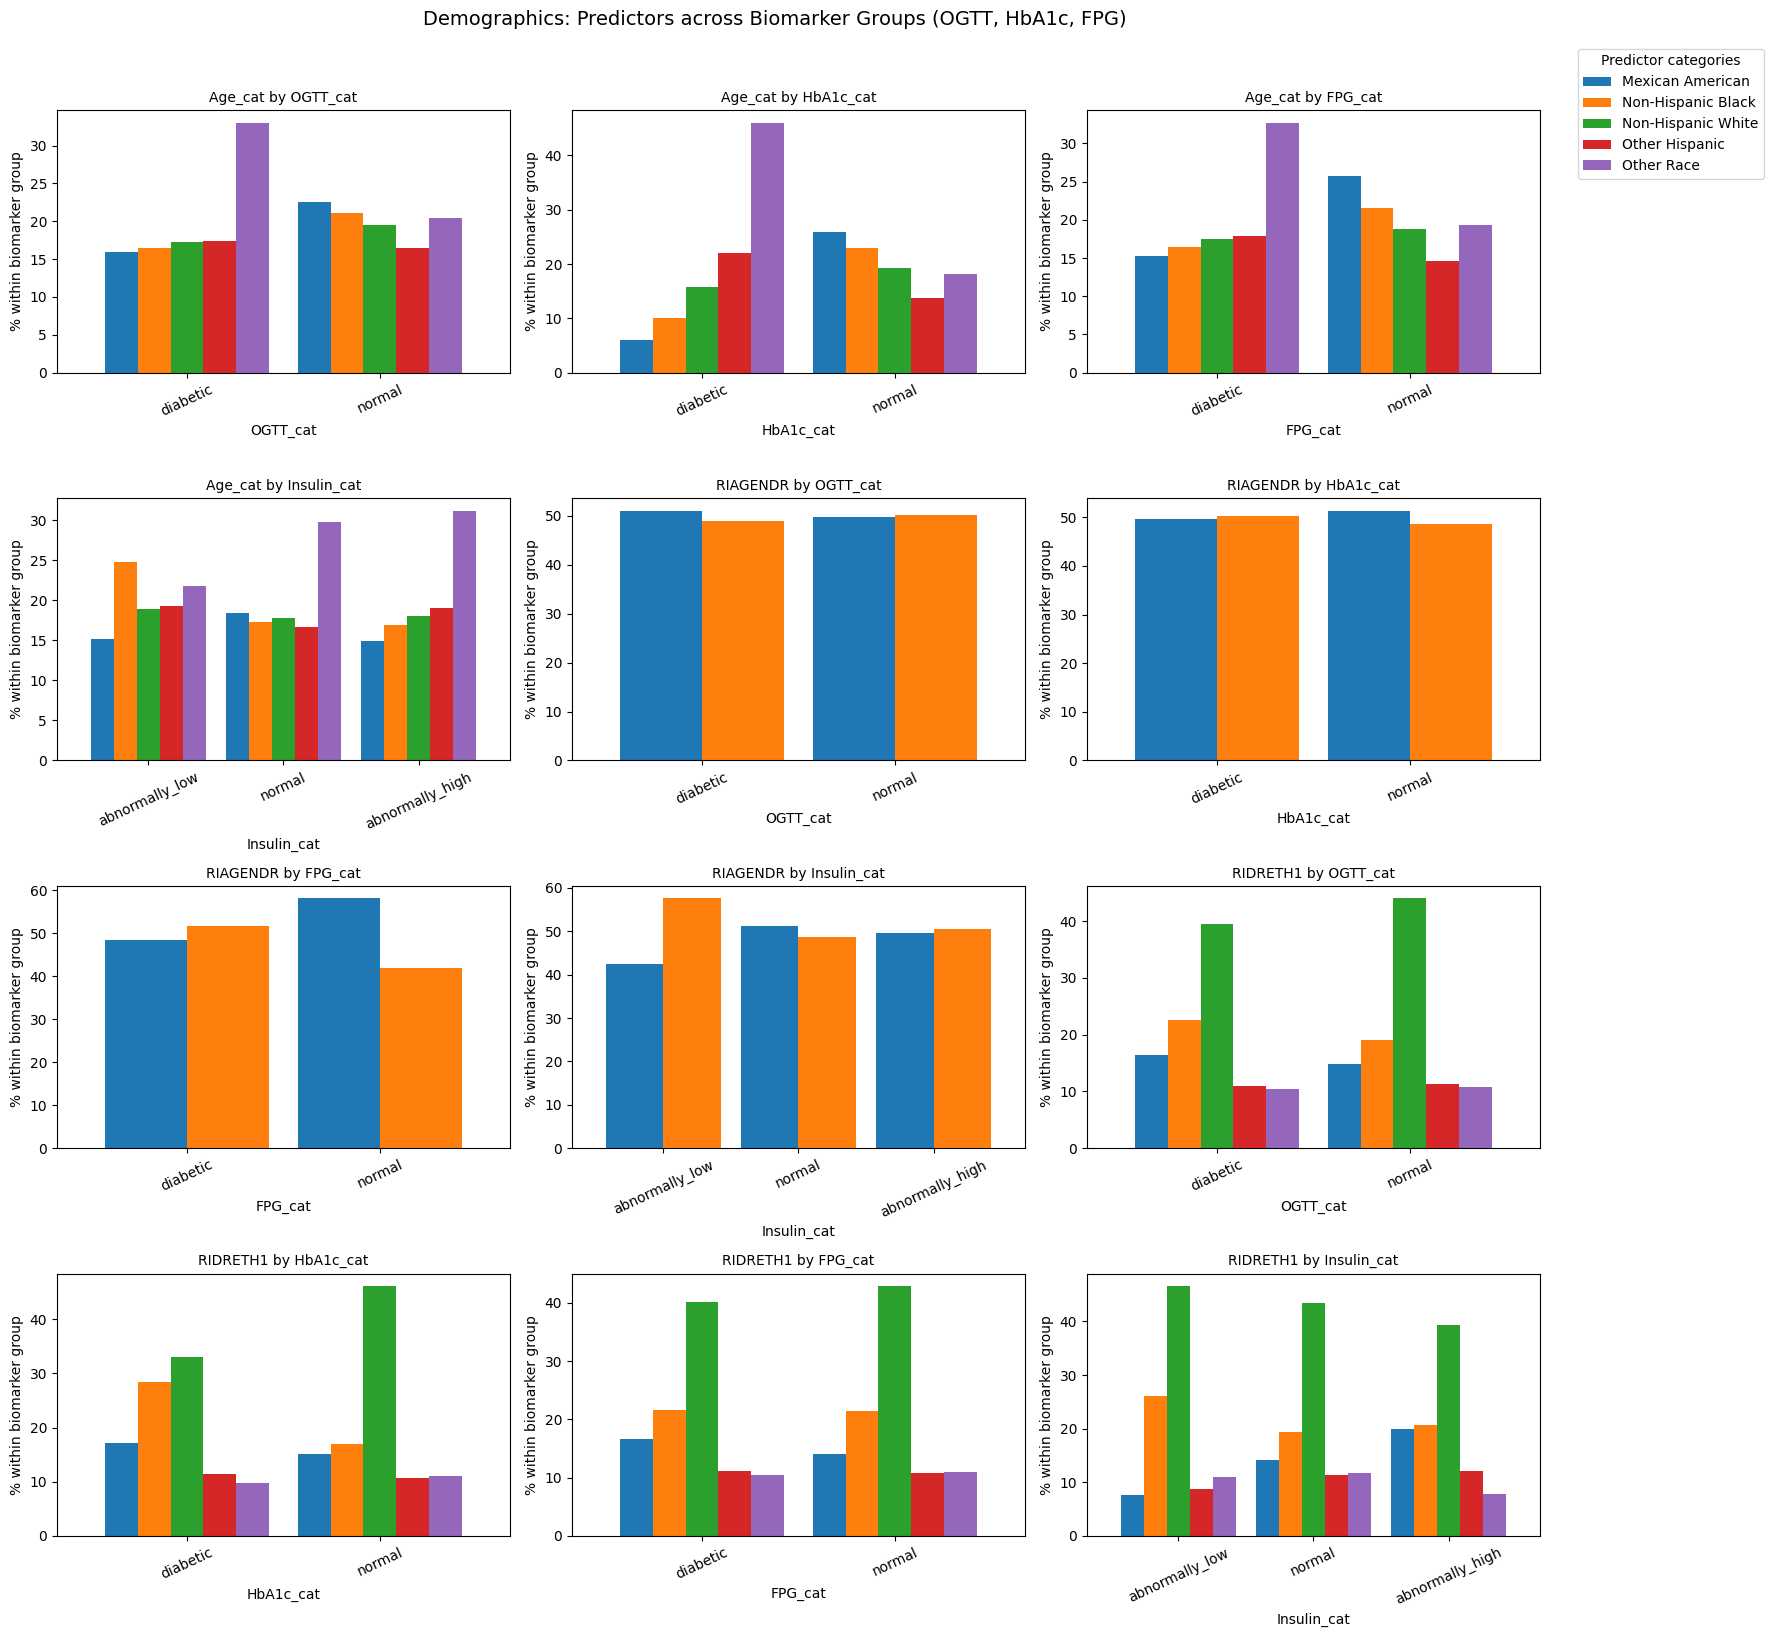

✅ Demographics: plotted 12 charts (3 predictors × 4 biomarkers)


In [52]:
demographics = ["Age_cat", "RIAGENDR", "RIDRETH1"]
plot_category_grid(df, demographics, "Demographics")

Age - older age categories contribute to a larger amount of the individuals in the diabedic HbA1c group. Has clear age gradient, abmornal HbA1c values are commone among older people. Thus age is a key risk-related factor

Sex - both genders are relatively evenly represented in both diabedic and normal categories. Sex alone may not strongly differentiat4e HbA1c.

Ethnicity - Higher proportions of Non-Hispanic Black and Mexican American individuals fall under the diabedic group while higer proportions of Non-Hispanic White individuals falol under the normal HbA1c group. Ethnicity may be an important predictor to include subsequent analyses

###Analysis of biomarkers by Socioeconomic status

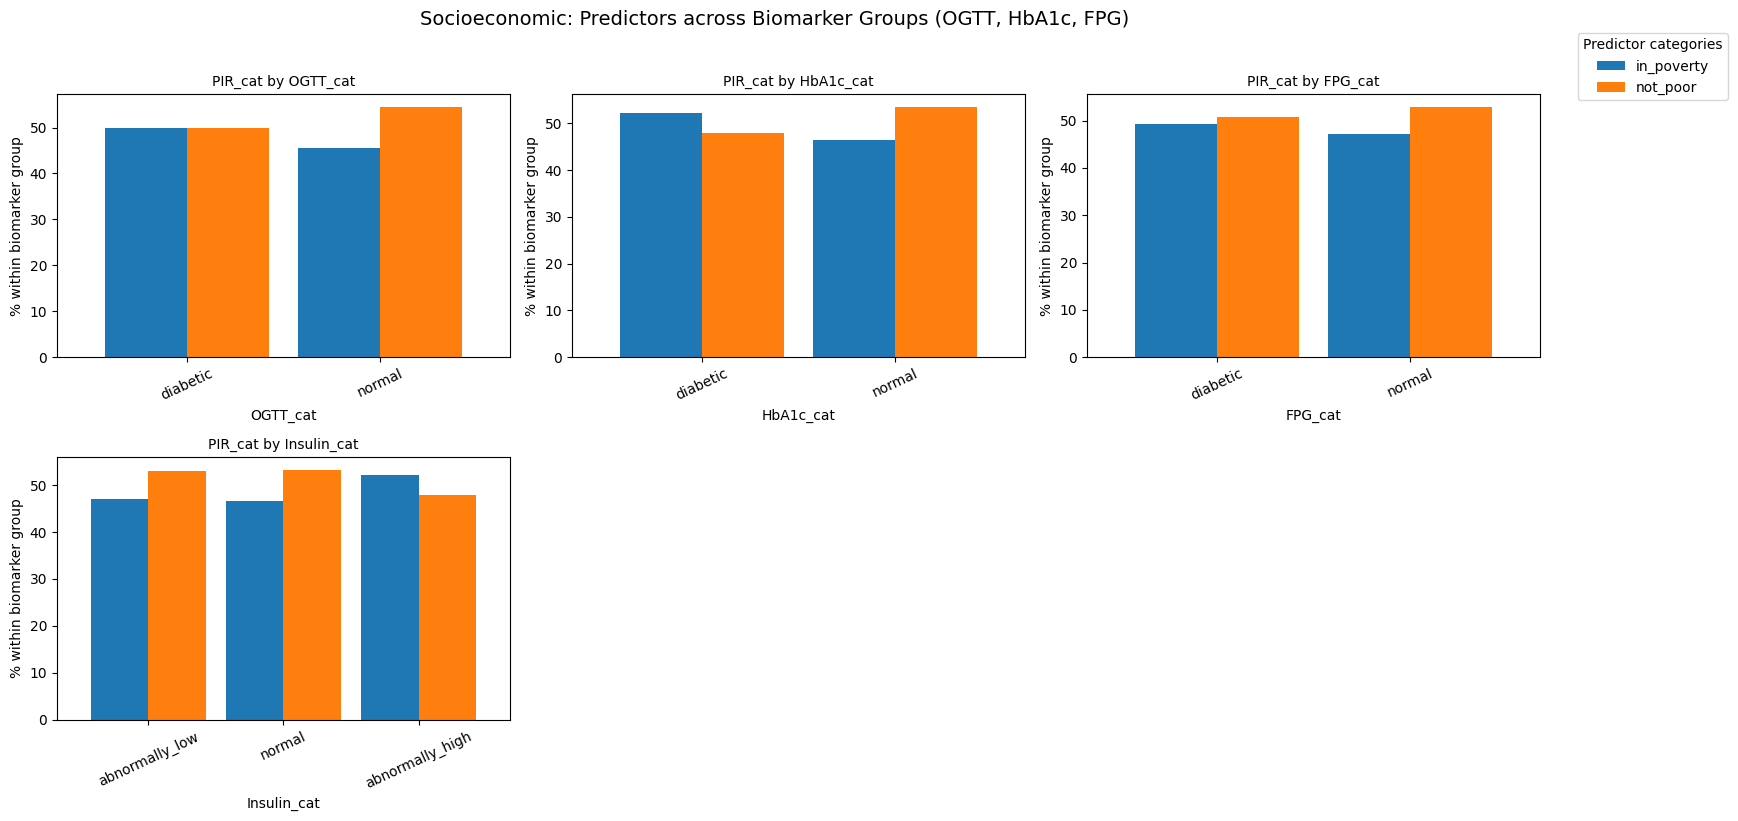

✅ Socioeconomic: plotted 4 charts (1 predictors × 4 biomarkers)


In [53]:
socioeconomic = ["PIR_cat",]
plot_category_grid(df, socioeconomic, "Socioeconomic")


Poverty-to-income ratio - individuals in poverty make uo a slightly higher proportion of the diabedic group compared to the normal. Shows a socioeconomic gradient where lower income status -> poorer glycaemic control

###Analysis of biomarkers by Lifestyle/behaviour

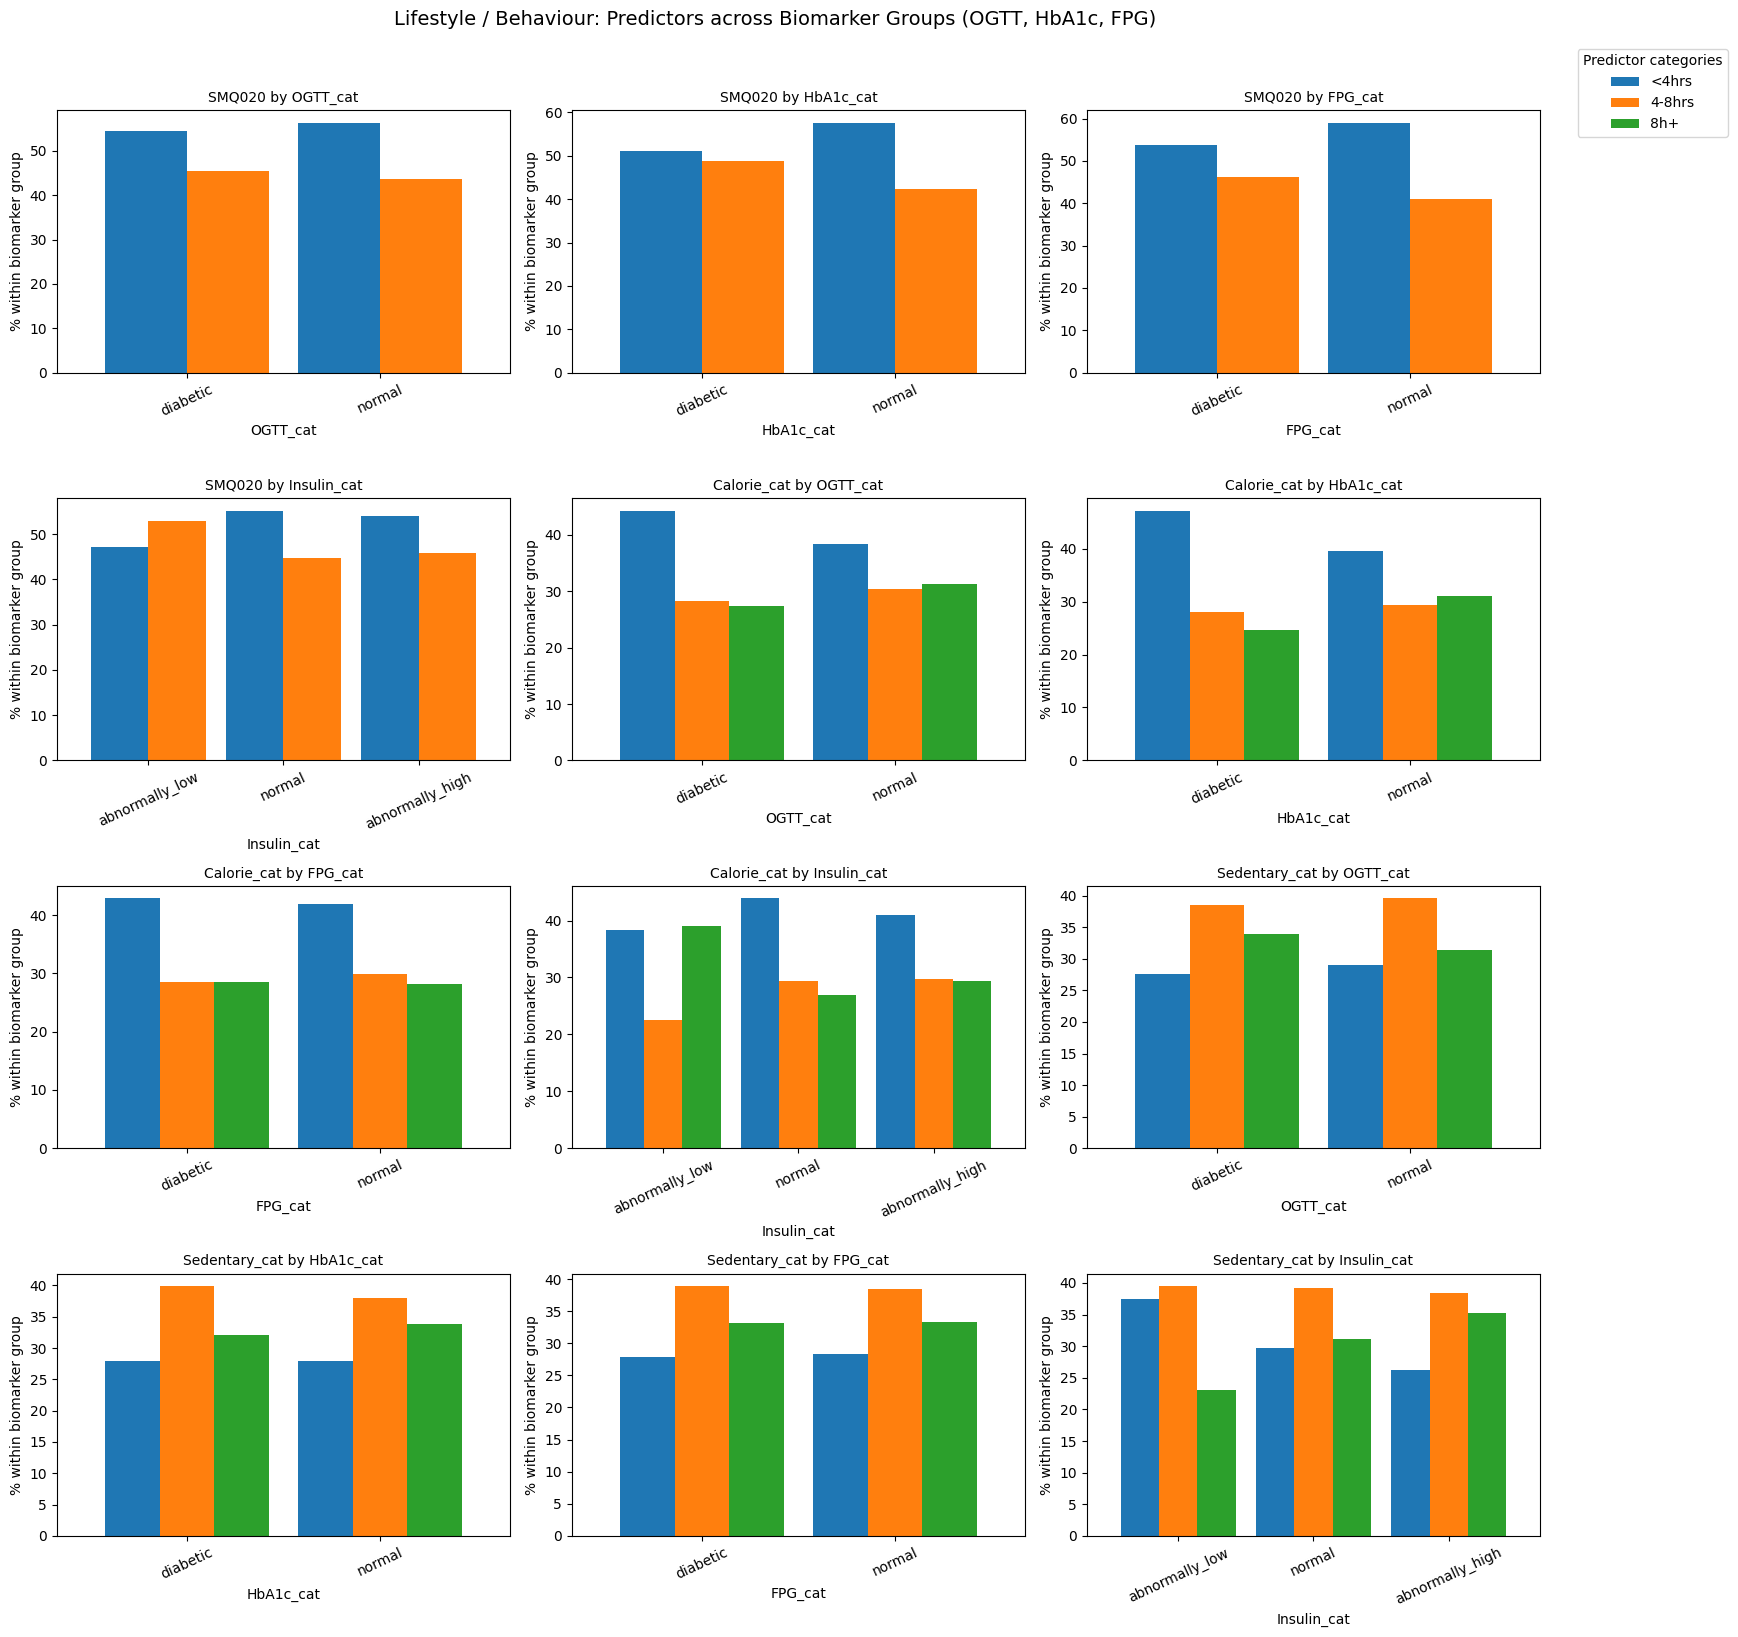

✅ Lifestyle / Behaviour: plotted 12 charts (3 predictors × 4 biomarkers)


In [54]:
lifestyle = ["SMQ020", "Calorie_cat", "Sedentary_cat"]
plot_category_grid(df, lifestyle, "Lifestyle / Behaviour")


Smoking - higher proportions of smokers in the diabedic group. Smoking behavious much more common in individuals with abnormal HbA1c levels

calorie intake - higher calorie intake individuals fall under the normal HbA1c group, lower calorie intake more prevalent in diabedic group.

sedentary time - longer sedentaru durations appear more common in diabedic HbA1c group, shorter time more prevalent in normal group. Physical inactivity may be linked to poorer glycaemic outcomes.

###Analysis of biomarkers by Anthropometric,clinical/diabetes history

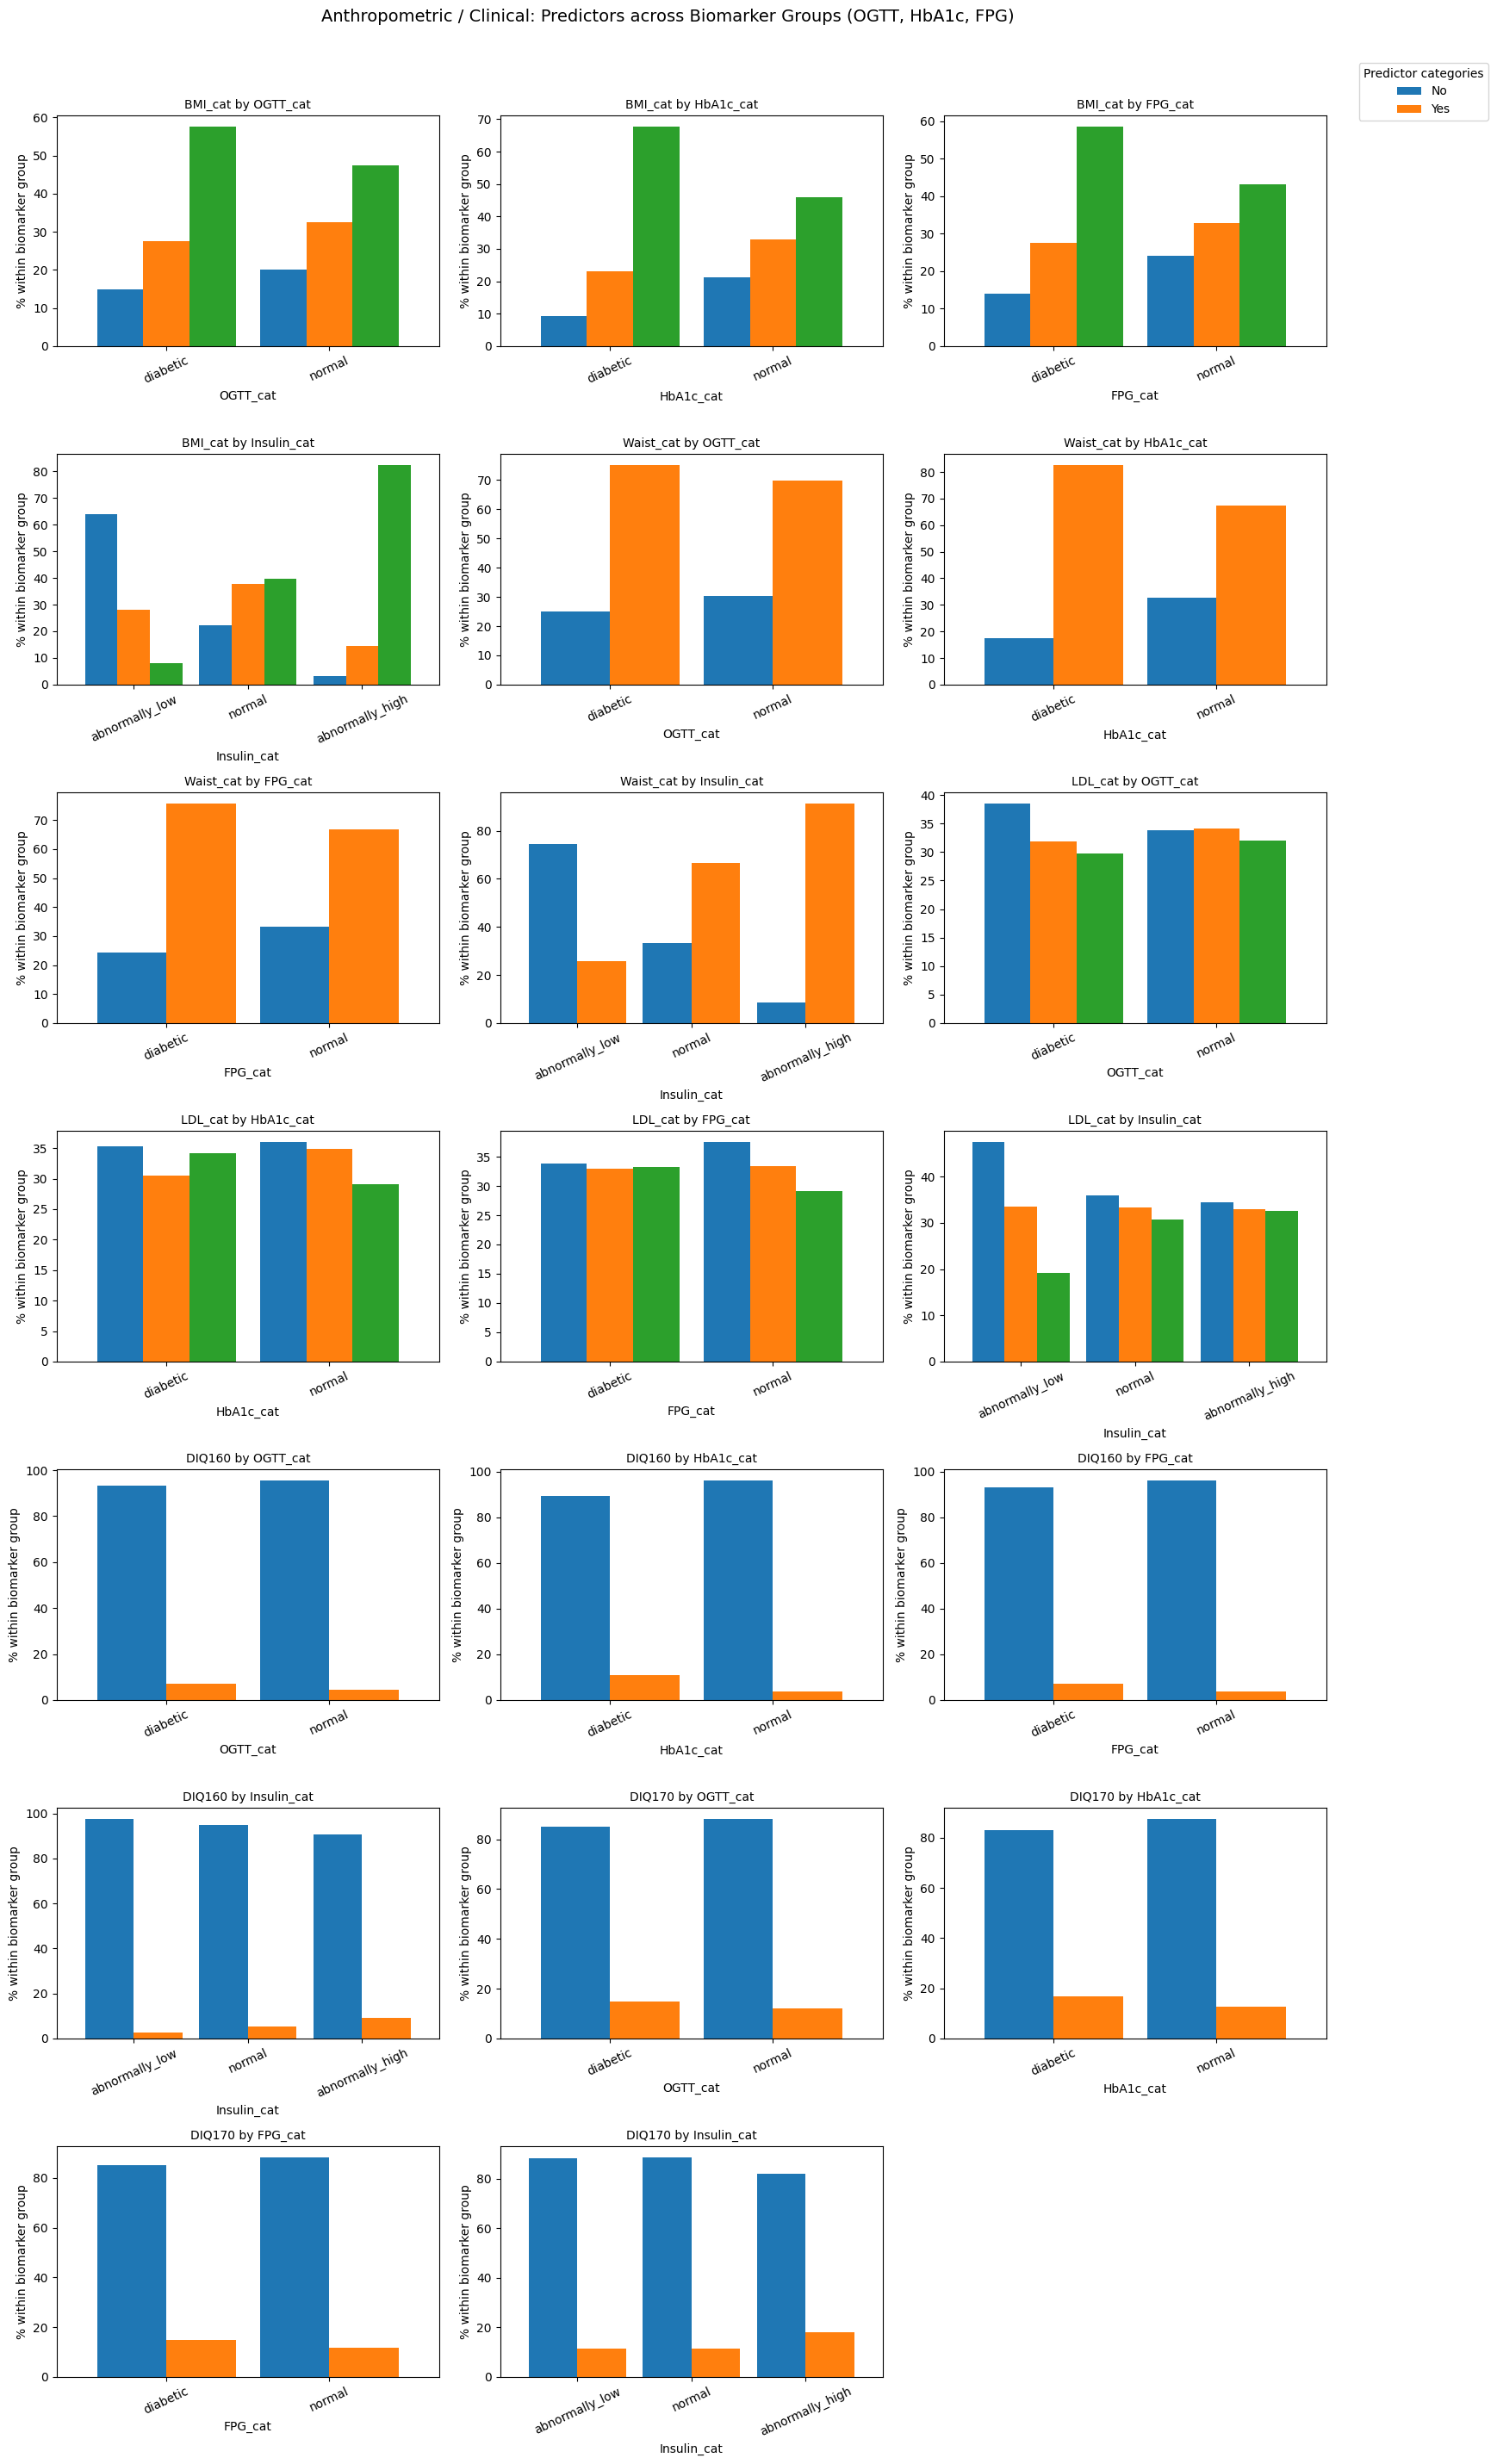

✅ Anthropometric / Clinical: plotted 20 charts (5 predictors × 4 biomarkers)


In [55]:
anthro_clinical = ["BMI_cat", "Waist_cat", "LDL_cat", "DIQ160", "DIQ170"]
plot_category_grid(df, anthro_clinical, "Anthropometric / Clinical")

BMI - Higher propotion of individuals classfied as obese fall under diabedic category. indivudals with normal or overweight BMI fall under the normal HbA1c group. BMI is a key varible if interest.

Waist circumference - unhealthy waist circumference far more prevalent in the diabedic HbA1c group than the normal group. Aligns the role of adiposity in metabolic dysfunction.

LDL cholesterol - elevated and high LDL levelsa re present in both groups. Distribution does not differ as markedly as for BMI and waist circumference. LDL plays a weaker or more indirect role.

Prediabetes diagnosis - higher proportion of prior prediabetes diagnosis fall under the diabedic group, normal HbA1c group has a majority of individuals with without prediabetes. This pattern supports the role of prediabetes being an intermediate metabolic state.

Family history of diabetes - higher proportion of individuals in diabedic group report a family history of diabetes compared to those who fall under the normal HbA1c group. genetic and shared familial risk factors may contribute to the abnormal HbA1c levels.


###Analysis of biomarkers with depression score

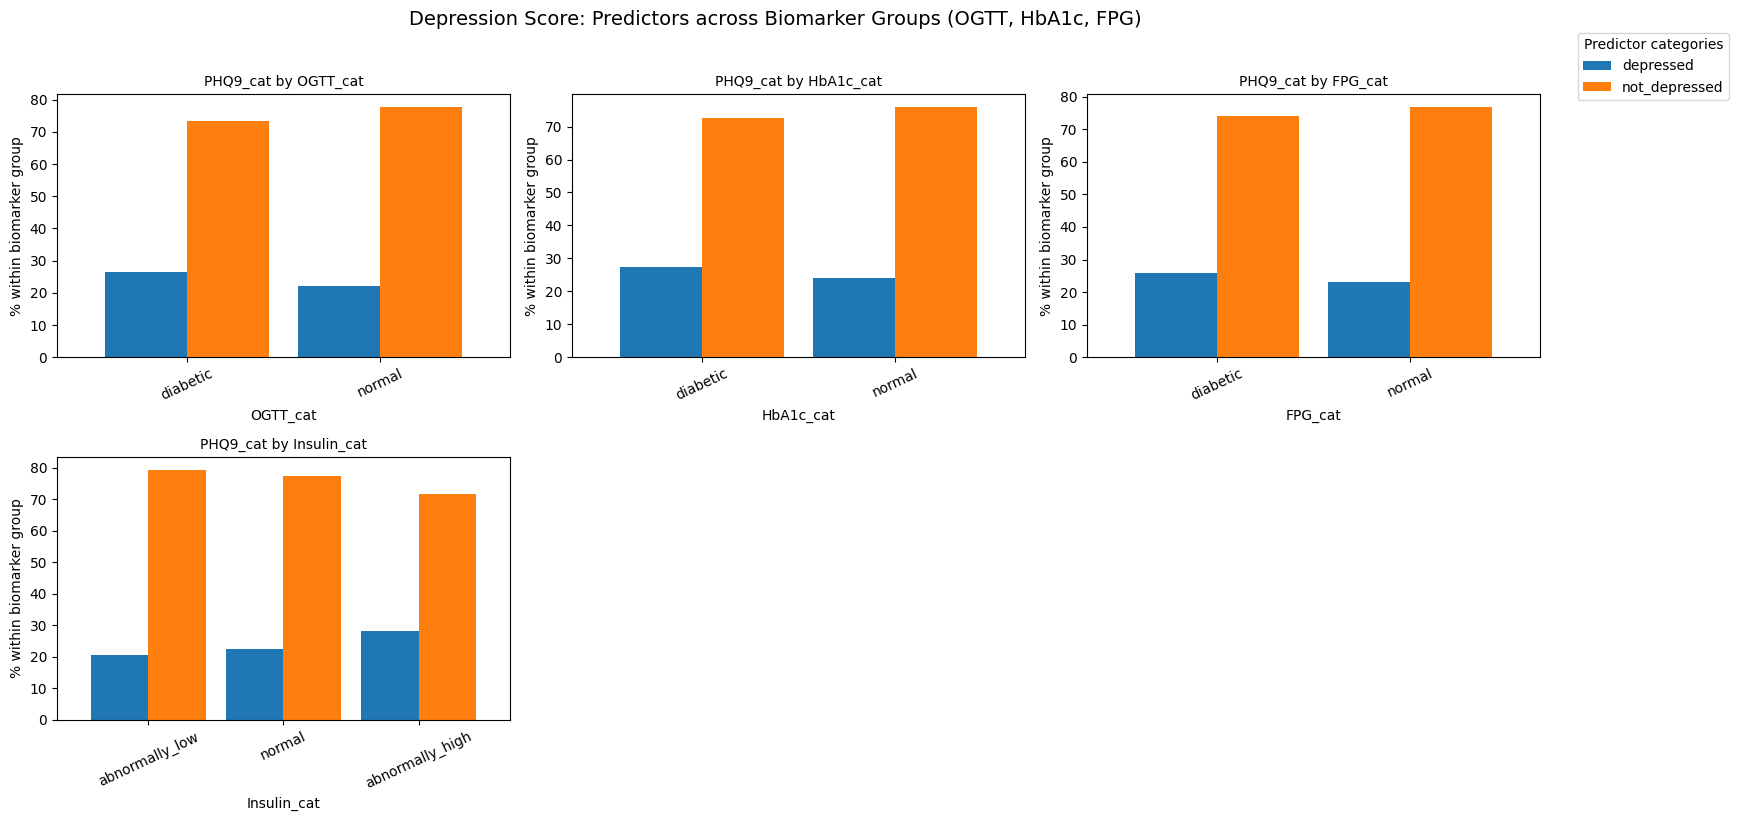

✅ Depression Score: plotted 4 charts (1 predictors × 4 biomarkers)


In [56]:
anthro_clinical = ["PHQ9_cat"]
plot_category_grid(df, anthro_clinical, "Depression Score")

Depression status - slightly higher proportion of indivudals under the diabedic group classified as depressed compared to the normal group. Difference is nor large but there is a possible link between mental health status and glycaemic control

##Heat maps

In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

def _proportion_table(df, row_var, col_var, normalize="index"):
    """Return (percent_table, count_table) for row_var vs col_var."""
    d = df[[row_var, col_var]].dropna()
    counts = pd.crosstab(d[row_var], d[col_var])
    perc = pd.crosstab(d[row_var], d[col_var], normalize=normalize) * 100
    return perc.round(1), counts

def plot_heatmap_set(df, pairs, set_title, normalize="index", ncols=3, figsize_per_plot=(5.2, 4.6), min_cell_count_note=True):
    """
    Plot a grid of proportion heatmaps for a list of (row_var, col_var) pairs.
    normalize="index" => row-wise % (recommended)
    """
    n = len(pairs)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*figsize_per_plot[0], nrows*figsize_per_plot[1]))
    axes = np.array(axes).reshape(-1)

    for i, (row_var, col_var) in enumerate(pairs):
        ax = axes[i]

        # check columns exist
        if row_var not in df.columns or col_var not in df.columns:
            ax.axis("off")
            ax.set_title(f"Missing: {row_var} or {col_var}")
            continue

        perc, counts = _proportion_table(df, row_var, col_var, normalize=normalize)

        # heatmap via imshow
        im = ax.imshow(perc.values, aspect="auto")

        # ticks & labels
        ax.set_xticks(range(len(perc.columns)))
        ax.set_xticklabels([str(c) for c in perc.columns], rotation=30, ha="right", fontsize=8)

        ax.set_yticks(range(len(perc.index)))
        ax.set_yticklabels([str(r) for r in perc.index], fontsize=8)

        ax.set_title(f"{row_var} × {col_var}", fontsize=10)

        # annotate each cell with % and counts
        for r in range(perc.shape[0]):
            for c in range(perc.shape[1]):
                p = perc.iat[r, c]
                n_cell = counts.iat[r, c]
                label = f"{p:.1f}%\n(n={n_cell})"
                ax.text(c, r, label, ha="center", va="center", fontsize=7)

        # optional: note sparse cells
        if min_cell_count_note:
            sparse_cells = (counts < 10).sum().sum()
            ax.set_xlabel(f"Row-%; sparse cells (<10): {sparse_cells}", fontsize=8)

        # colorbar per plot (lightweight)
        cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)
        cbar.set_label("%", fontsize=8)

    # turn off unused plots
    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(set_title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

###Demographics x Biomarkers

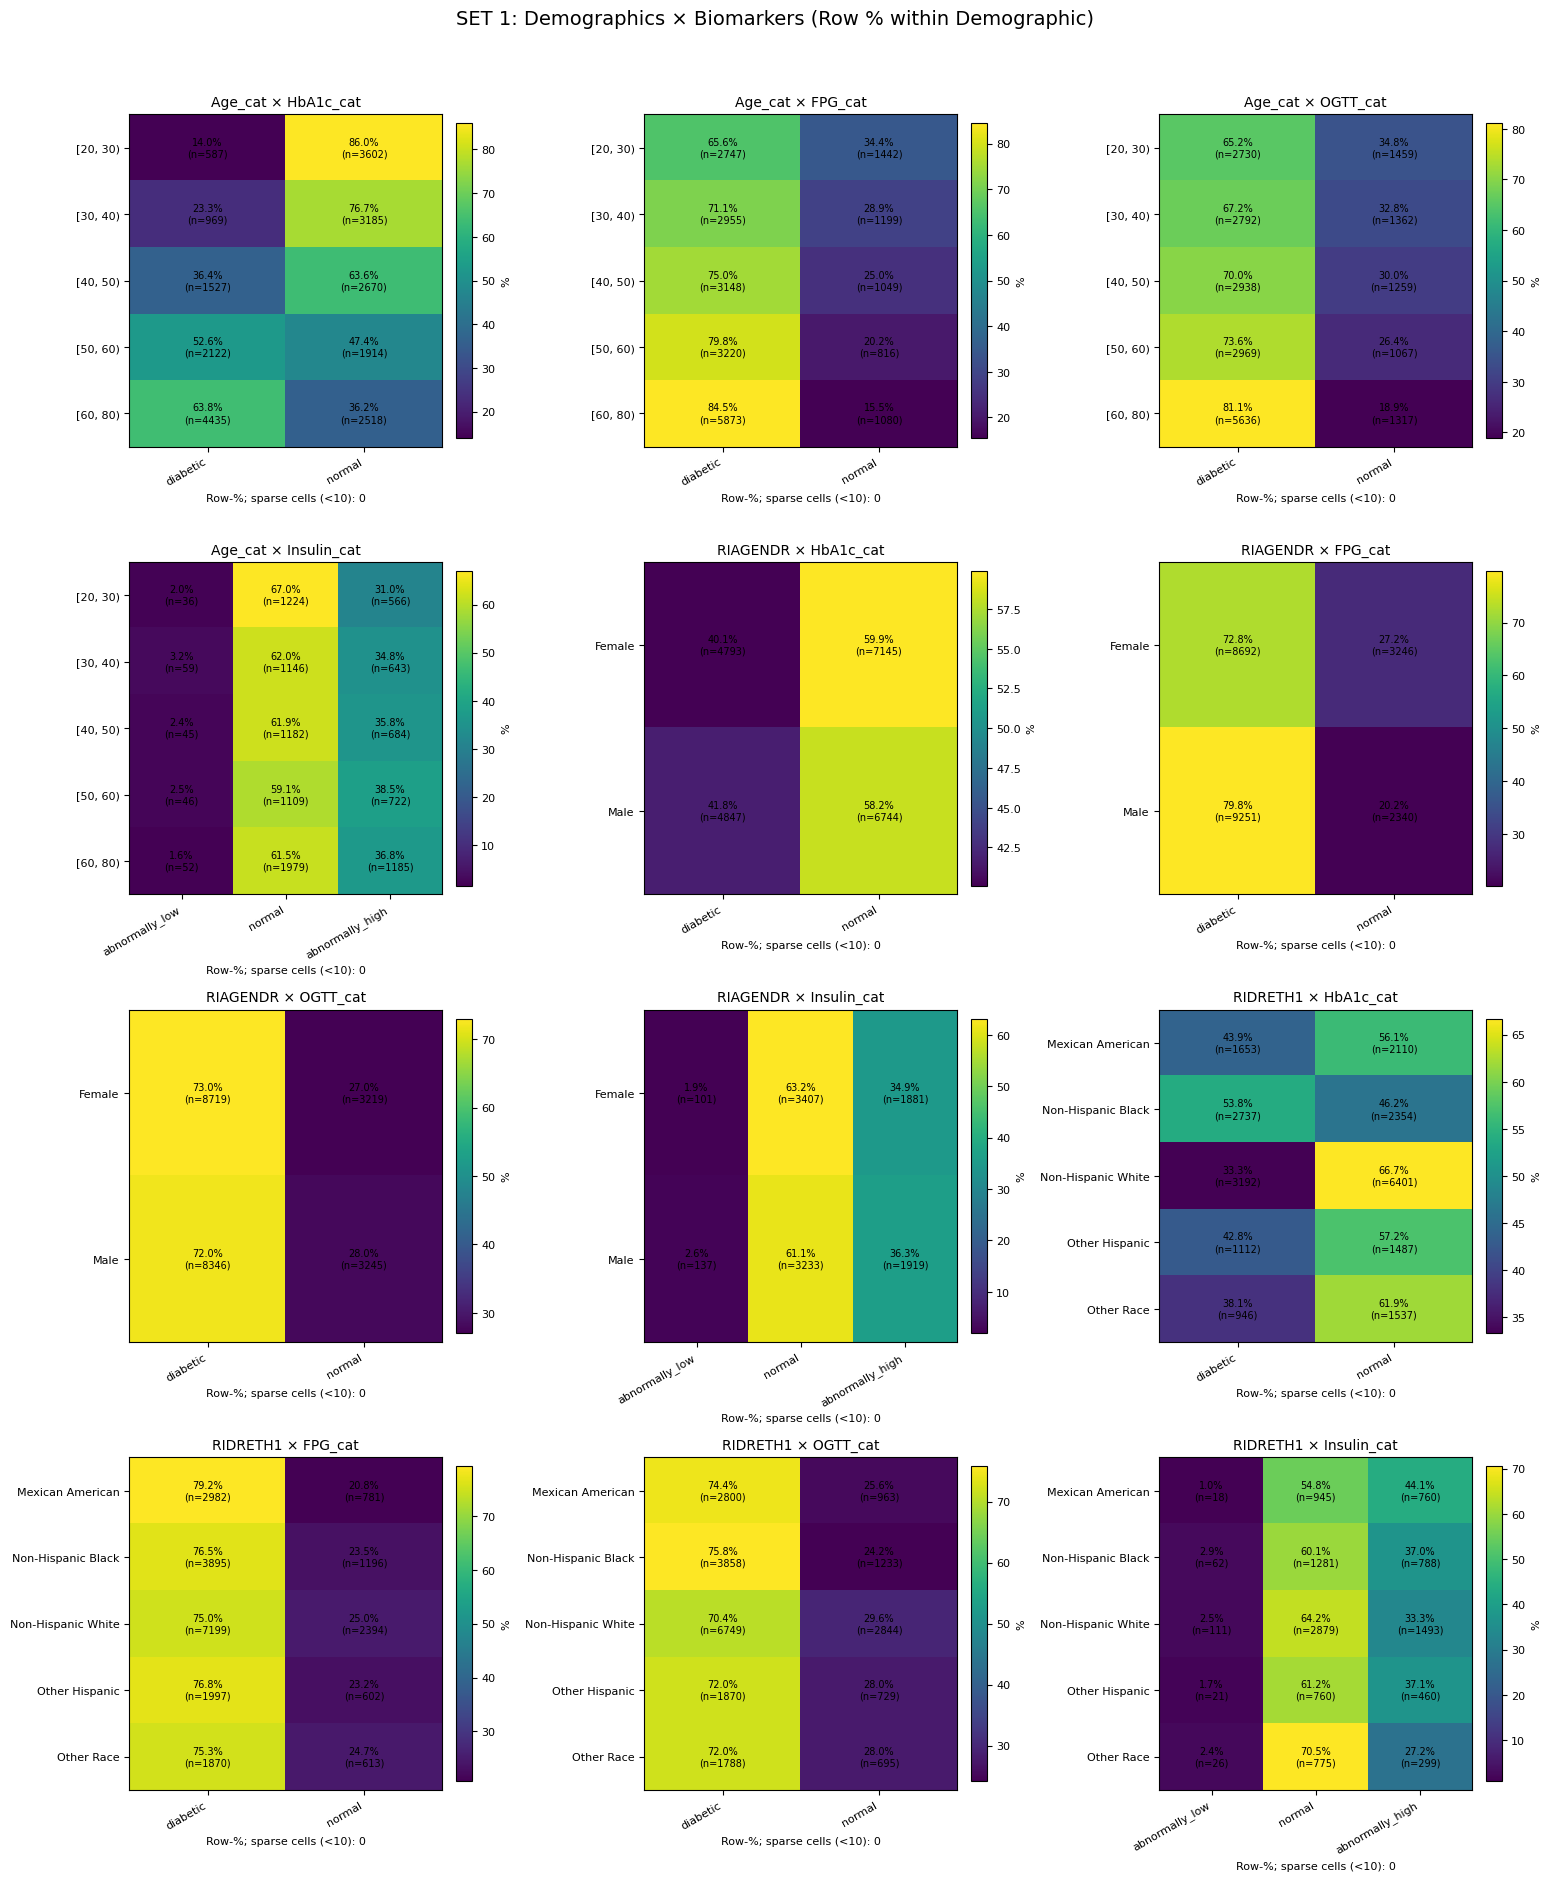

In [58]:
set1_pairs = [
    ("Age_cat", "HbA1c_cat"),
    ("Age_cat", "FPG_cat"),
    ("Age_cat", "OGTT_cat"),
    ("Age_cat", "Insulin_cat"),
    ("RIAGENDR", "HbA1c_cat"),
    ("RIAGENDR", "FPG_cat"),
    ("RIAGENDR", "OGTT_cat"),
    ("RIAGENDR", "Insulin_cat"),
    ("RIDRETH1", "HbA1c_cat"),
    ("RIDRETH1", "FPG_cat"),
    ("RIDRETH1", "OGTT_cat"),
    ("RIDRETH1", "Insulin_cat")
]

plot_heatmap_set(df, set1_pairs, set_title="SET 1: Demographics × Biomarkers (Row % within Demographic)")

**Overall pattern**

Across all the demographic heat maps, age shows the strongest and most consistent association the abnormal biomarker levels, followed by ethnicity and the sex.

**age**

comparing the glycaemic biomarkers (HbA1c, FPG, and OGTT), demonstrates a clear progressive age gradient. Younger age groups (20 - 39) are classified as normal across all three biomarkers while the older age groups (50 - 79) have higher proportions of abnormal biomarker levels. for example, HbA1c increases steadily with age, exceeding 60% in older age groups
For age x fasting insulin, its shows that fasting insulin remains the most common category across all age groups, the proportion of abnormally high fasting insulin increases with age, while low insulin is rare. This shows that increasing age is associated with glucaemic dysregulation and also a shift of inulin resistance rather than deficiency across the multiple biomarkers.

**Sex**

minimal differences between males and females across all biomarkers. This shows that sex alone does not strognly diferentiate glycaemic or insulin status in this dataset

**ethnicity**

clear disparties are evident across multiple biomarkers. For HbA1c, Non-Hispanic Black individuals show the highest proportions of diabetic HbA1c, Non-Hispanic White individuals show the highest proportion of normal HbA1c. Mexican American and other Hispanic groups show intermediate distributions. Similar patterns but less prononounced patterns are observed for FPG and OGTT. Some ethnic groups show higher proportions of abnormally high insulin, suggesting differences in insulin regulationacross ethnic categories. This shows that thnicity might be associated with both glycaemic and insulin dynamics


*Sparcity and binning considerations*

cell counts are sufficiently large, no critically sparese categories observed. Current demographic binning is appropriate and does not rewuire re-binning prior to logistic regression or XGBoost analysis.

*Summary*

Overall, the heat maps indicate that age is the dominant demographic factor associated with abnormal glycaemic and insulin biomarkers while ethnicity shows meaningful variation, and Sex has weaker association across all biomakers. This emphasises the priority of using age and ethnicty in subsequent prevalence analyses.


###Lifestyle x Biomarkers

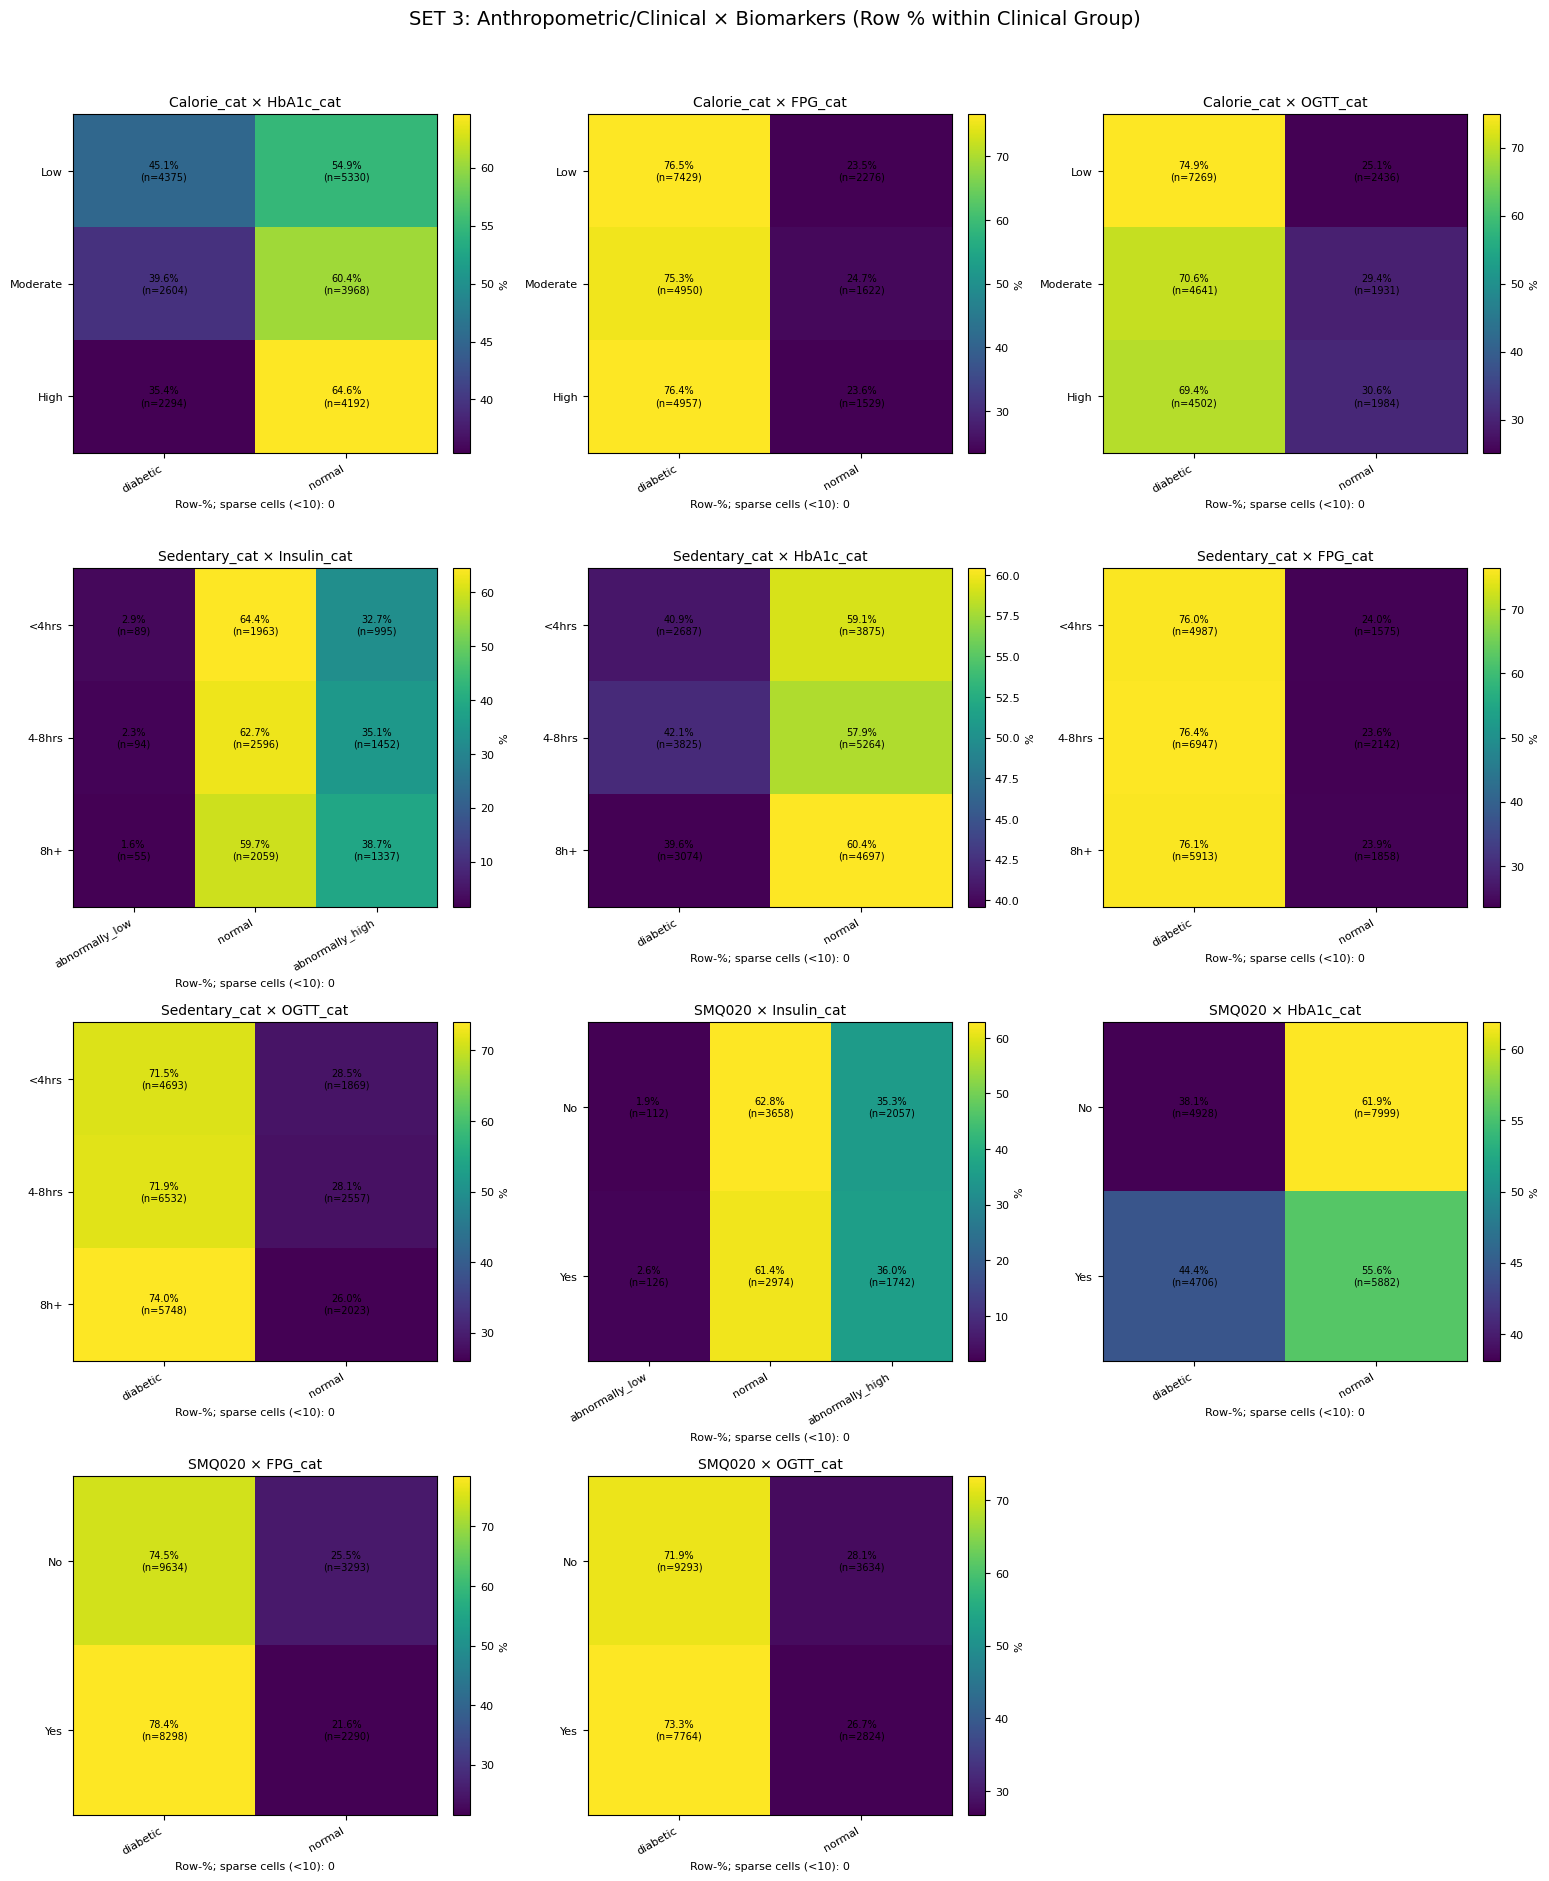

In [59]:
set3_pairs = [
    ("Calorie_cat", "HbA1c_cat"),
    ("Calorie_cat", "FPG_cat"),
    ("Calorie_cat", "OGTT_cat"),
    ("Sedentary_cat", "Insulin_cat"),
    ("Sedentary_cat", "HbA1c_cat"),
    ("Sedentary_cat", "FPG_cat"),
    ("Sedentary_cat", "OGTT_cat"),
    ("SMQ020", "Insulin_cat"),
    ("SMQ020", "HbA1c_cat"),
    ("SMQ020", "FPG_cat"),
    ("SMQ020", "OGTT_cat"),
]

plot_heatmap_set(df, set3_pairs, set_title="SET 3: Anthropometric/Clinical × Biomarkers (Row % within Clinical Group)")

**Overall pattern**

Overall unfavourable anthropometric and lifestyle profiles are accociated eith higher proportions of abnormal glycaemic biomarker and fasting insulin levels. Sedentary and behaviour related predictors show clear gradients while calorie intake displays counterintuitive patterns likely reflecting behavioural modification or reporting bias.

**Calorie Intake**

across HbA1c, OGTT, FPG, individuals wkth lower calorie intake show higher proportions of adnormal glycaemic control compared to those wiht moderate or high intake. Similar pattern observed for fasting insulin, lower calorie groups have higher proportions of adnormally high insulin levels, suggesting insulin resistance.

**Sedentary Behaviour**

for glycaemic and insulin biomarkers, there is a clear gradient, with individuals  reporting more than or equal to 8 hours of sedentary time having higher abnormal glycaemic biomarker levels. Individuals with lower sedentary time are more frequently classified under normal for all biomarkers.

**Smoking status**

Smokers shows consistently high proportions of abnormal biomarker levels with abnormal glycaelic biomarker levels and high insulin levels. Although the magnitude of differences in modest, the consistency across the different biomarkers support statistical evalution of smoking status

**Sparcity and binning considerations**

cell counts are sufficiently large, no critically sparese categories observed. Curreent demographic binning is appropriate and does not rewuire re-binning prior to logistic regression or XGBoost analysis.



**Overall Pattern**


###Anthropometric/Clinical x Biomarkers

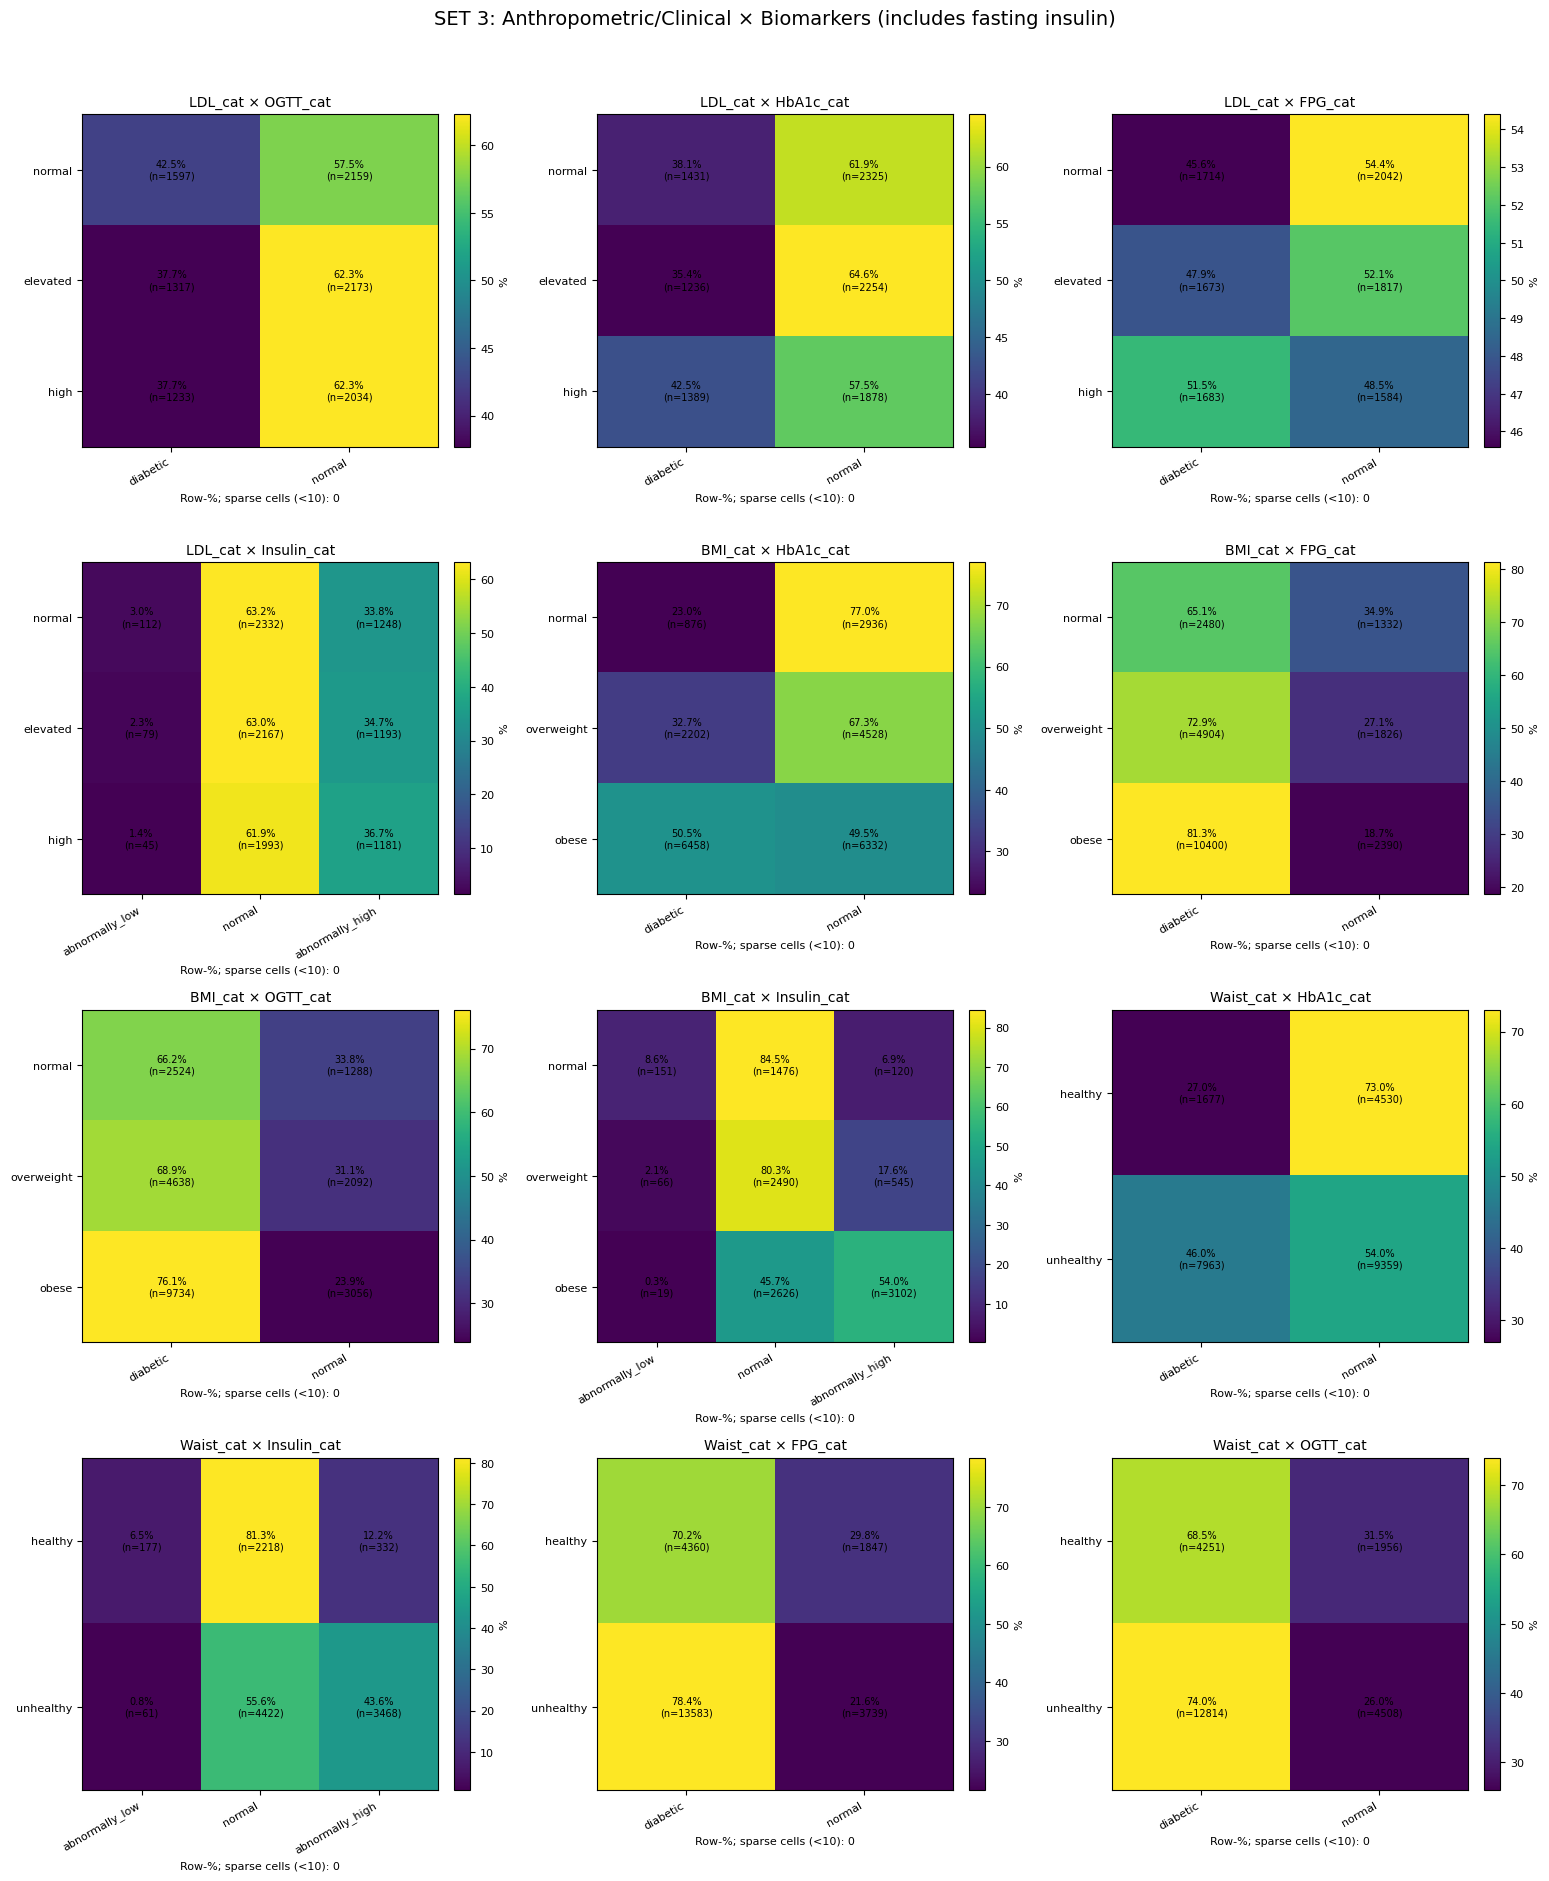

In [60]:
set3_pairs = [
    ("LDL_cat", "OGTT_cat"),
    ("LDL_cat", "HbA1c_cat"),
    ("LDL_cat", "FPG_cat"),
    ("LDL_cat", "Insulin_cat"),
    ("BMI_cat", "HbA1c_cat"),
    ("BMI_cat", "FPG_cat"),
    ("BMI_cat", "OGTT_cat"),
    ("BMI_cat", "Insulin_cat"),
    ("Waist_cat", "HbA1c_cat"),
    ("Waist_cat", "Insulin_cat"),
    ("Waist_cat", "FPG_cat"),
    ("Waist_cat", "OGTT_cat"),
]
plot_heatmap_set(df, set3_pairs, set_title="SET 3: Anthropometric/Clinical × Biomarkers (includes fasting insulin)")


**overall pattern**

BMI and waist circumference show strong consistent associatiosn with abormal biomarker levels

**LDL x biomarkers**

gradient observed are modest. individuals with high LDL show slightly higher proportions of abnormal biomarker levels. the differences are small and inconsistent across markers. This shows that LDL cholesterol has weaker and less direct association with glycaemic dysregulation and insulin resistance than some of the other predictors.

**body composition (BMI and waist circumference) x biomarkers**

as we compare BMI and waist circumference with the biomarkers, it shows strong and consistent gradients across all biomarkers.individuals classified obese or with unhealthy waist circumference show higher proportions of abnormal glycaemic biomarkers and those with normal BMI and healthy wiast circumference are classifed under normal biomarker levels. Overweight individuals fall between these categories. Insulin heat maps shift towards insulin resistancr as body composition increases. abnormally low insulin levels appear rarely. This suggests that adiposity are closely associated with glycaemic impairment and insulin resistance.

**sparsity and binning considerations**

Cell counts are generally adequate across BMI, waist circumference, and LDL categories, with minimal sparsity. Although abnormally low fasting insulin appears as a rare category across predictors, this group was not re-binned or excluded, as low fasting insulin may reflect insulin deficiency (type 1 diabetes), which should not be hidden through category merging. Instead of re-binning, potential class imbalance  from this rare category,it will be addressed during modelling through techniques such as SMOTE or other resampling approaches for logistic regression or XGBoost analyses, to improve model stability while having clinically meaningful distinctions.

###Diabetes History x Biomarkers

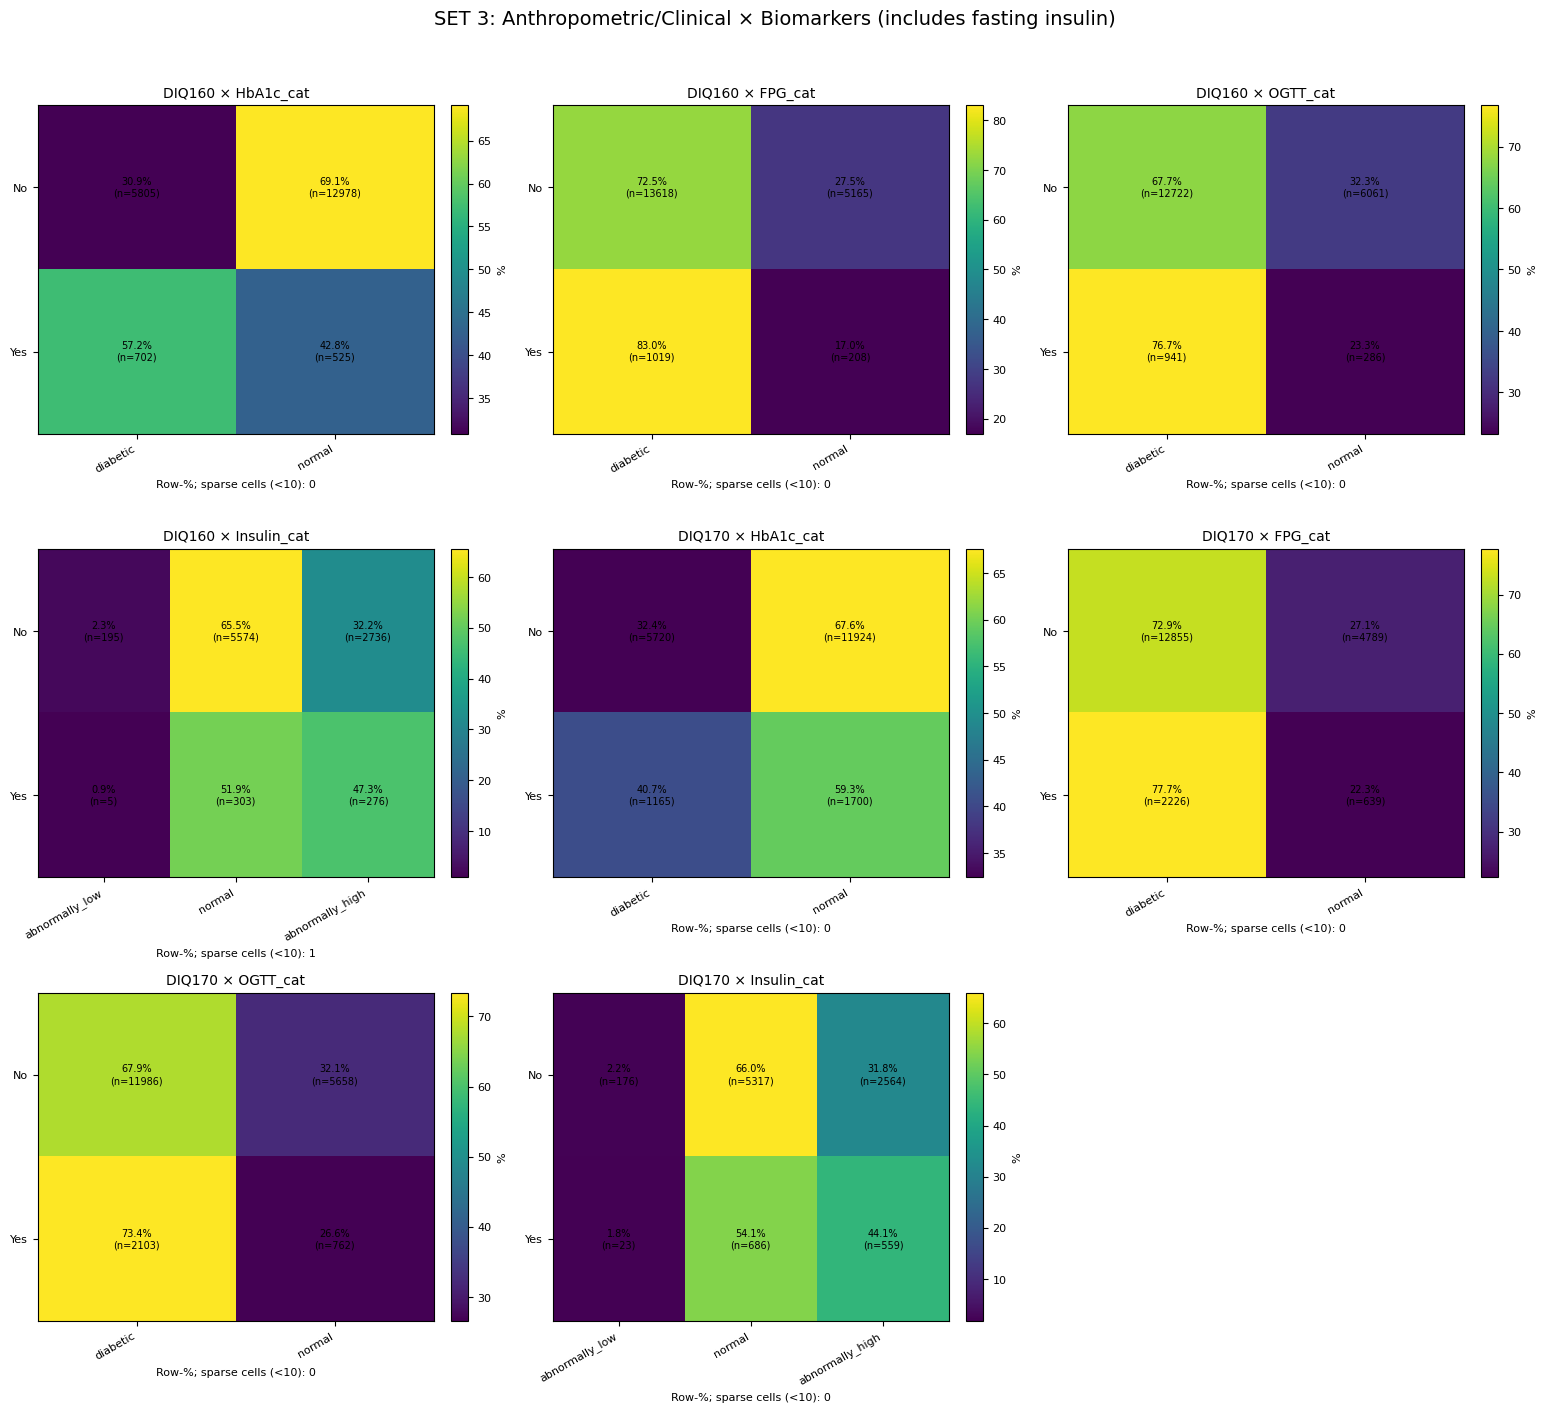

In [61]:
set3_pairs = [
    ("DIQ160", "HbA1c_cat"),
    ("DIQ160", "FPG_cat"),
    ("DIQ160", "OGTT_cat"),
    ("DIQ160", "Insulin_cat"),
    ("DIQ170", "HbA1c_cat"),
    ("DIQ170", "FPG_cat"),
    ("DIQ170", "OGTT_cat"),
    ("DIQ170", "Insulin_cat"),
]
plot_heatmap_set(df, set3_pairs, set_title="SET 3: Anthropometric/Clinical × Biomarkers (includes fasting insulin)")

**Overall analysis**

prediabetes diagnosis shows strong and consistent association with abnormal glycaemic biomarkers and insulin resistance while family history of diabetes demonstrates a moderate but consistent pattern across the biomarkers.

**Prediabetes diagnosis x biomarkers**

all individuals with prediabetes diagnosis show higher proportions of abnormal glycaemic biomarker levels. this pattern also extend to fasting insulin where the prediabetes group show higher propotions of abnormally high insulin levels, indicating insulin resistance. abnormally low insulin remains rare in both groups. This supports prediabetes dignosis as a strong clinical indicator of metabolic dysregulation

**Family History of diabetes**

individuals with a family history of diabetes show higher proportions of abnormak glycaemic biomakers but the differences are less noticiable compared to those observed prediabetes disgnosis. SImilar pattern for fasting insulin, higher proportion of abnormally high insulin among those positive diabetes family history. This suggest possible inherited or shared environmental contirbution to both glyaemic impairement and insulin resistance.

**Sparcity and binning considerations**

cell counts are adequte across both predictor heat maps, with minimal sparcity. Abnormally low fasting insuline remains a rare category but re-binning is not required due to reasoning from previous section.

###Socioeconimic status x Biomarkers

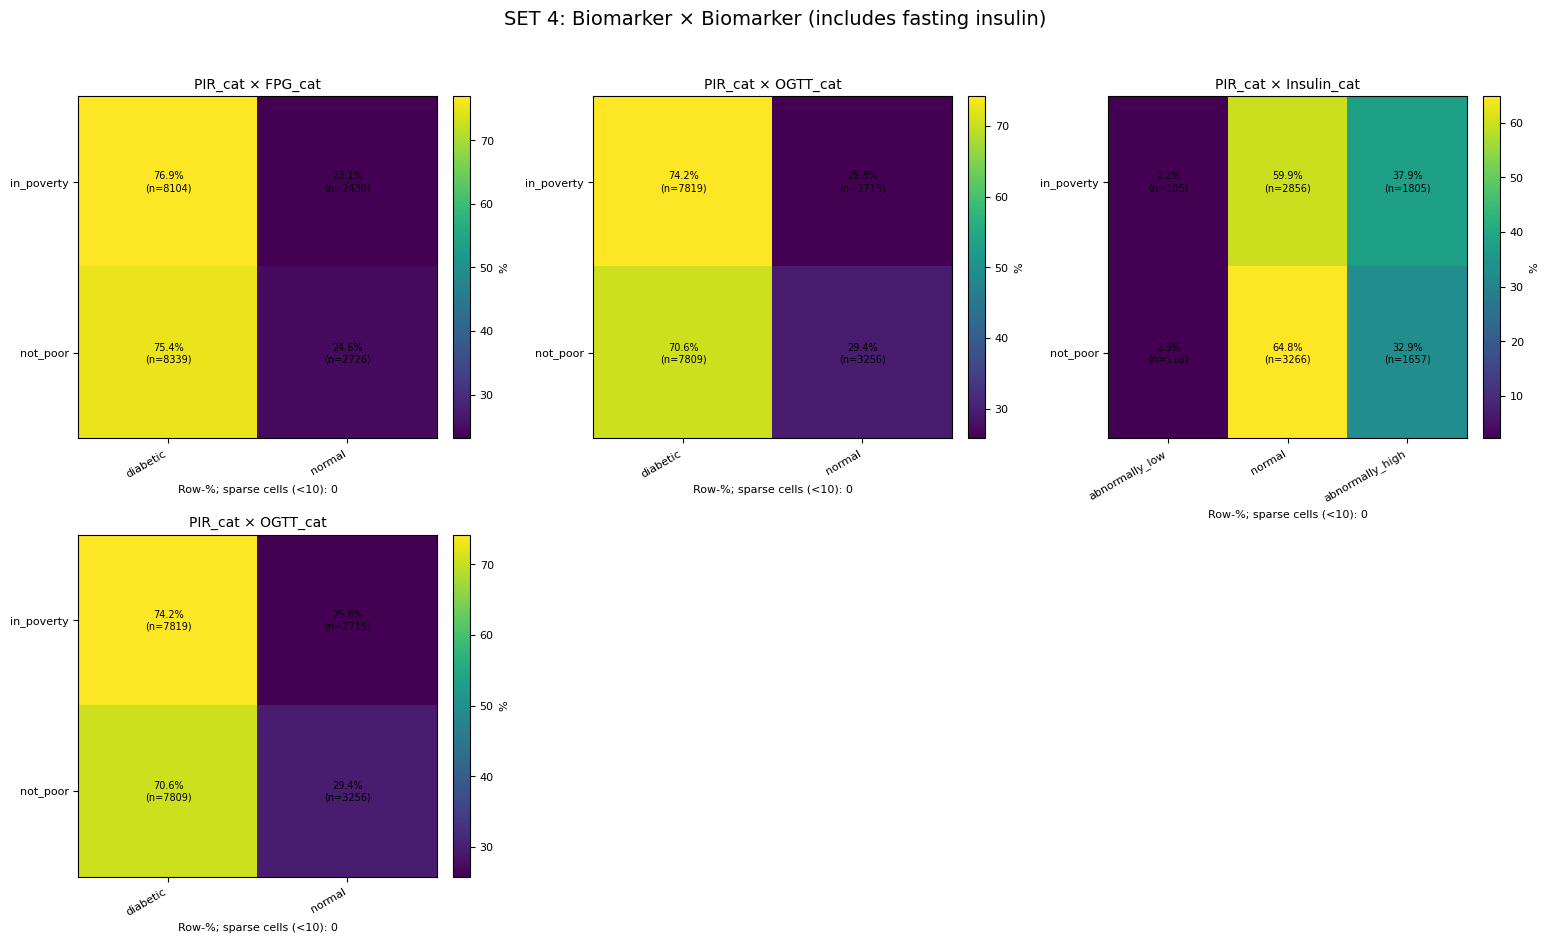

In [62]:
set4_pairs = [
    ("PIR_cat", "FPG_cat"),
    ("PIR_cat", "OGTT_cat"),
    ("PIR_cat", "Insulin_cat"),
    ("PIR_cat", "OGTT_cat"),
]
plot_heatmap_set(df, set4_pairs, set_title="SET 4: Biomarker × Biomarker (includes fasting insulin)")


**Poverty-to-income ratio**

overall, it shows a modest but consistent association with the biomarkers. Differences are relatively small but individuals classified as in poverty exhibit slightly higher proportions of abnormal glycaemic marker levels compared to those not in poverty. clearer pattern for fasting insulin observed with individuals in poverty having abnormally higher insulin resistance
these findings indicate that the socioecomonic disadvantage may be more strongly associated with insulin resistance than with the glycaemic biomarkers. PIR is a relevant predictor.


###Depression score x Biomarkers

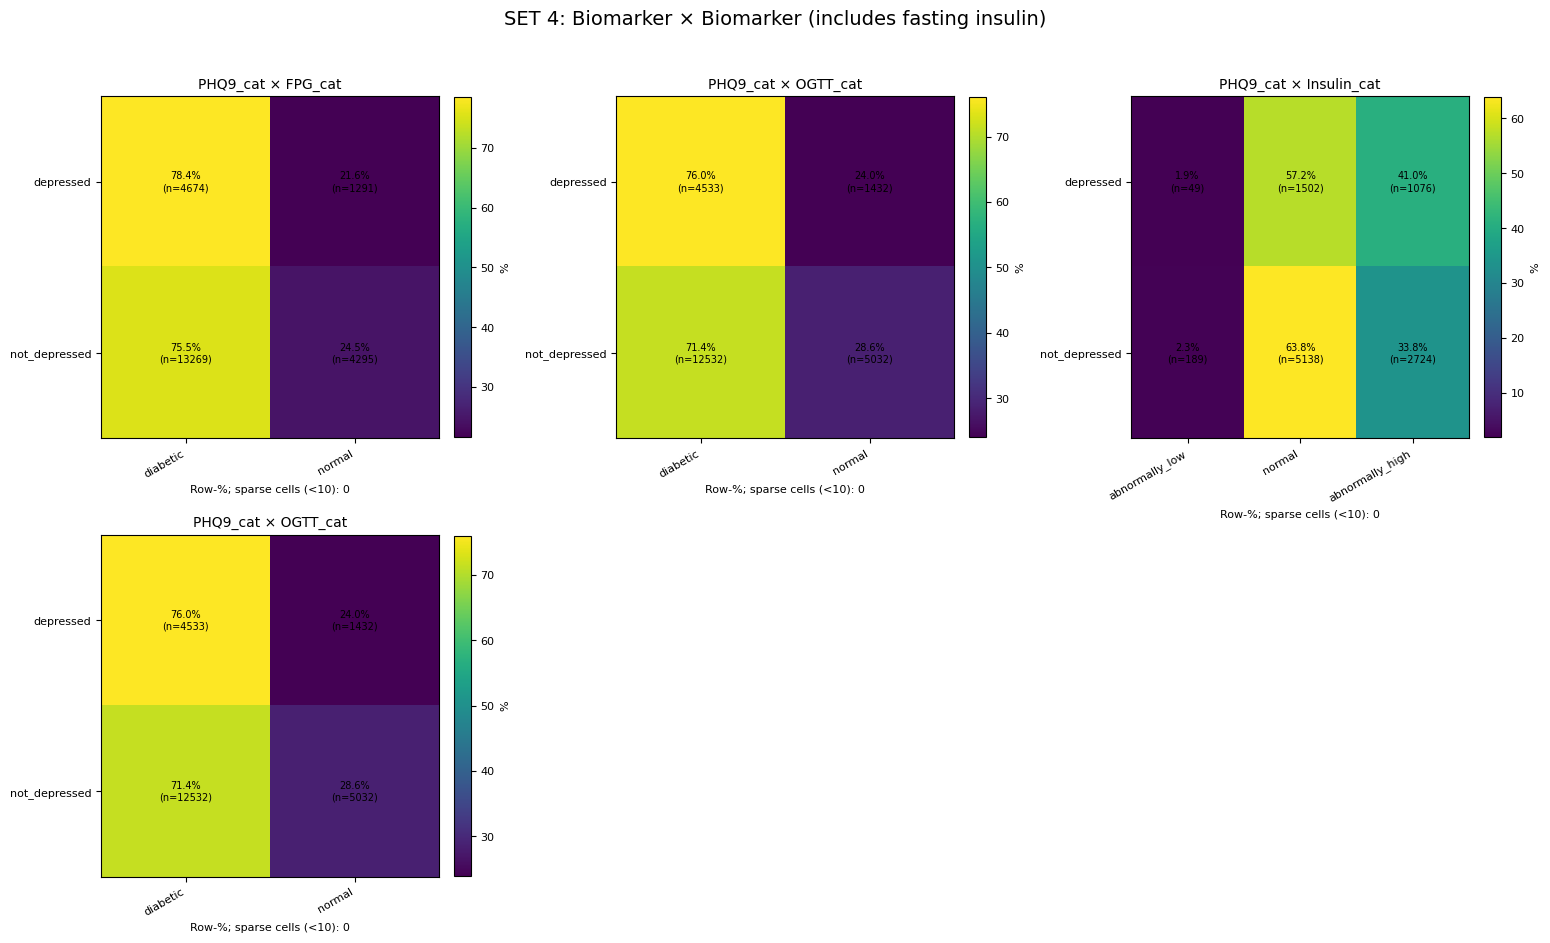

In [63]:
set4_pairs = [
    ("PHQ9_cat", "FPG_cat"),
    ("PHQ9_cat", "OGTT_cat"),
    ("PHQ9_cat", "Insulin_cat"),
    ("PHQ9_cat", "OGTT_cat"),
]
plot_heatmap_set(df, set4_pairs, set_title="SET 4: Biomarker × Biomarker (includes fasting insulin)")


**Depression Score**

individuals classfied as depressed show slightly higher proportions of abnormal glycaemic biomarkers compared to those not depressed. a clearer pattern observed for fasting insulin, where depressed group show a higher proportions of abnormally high insulin, showing greater insulin resistance.
This depressive sypmtoms are more strongly associated with insuline resistance than the overal glycaemic abnormalities. supporting the inclusion of mental health status as a potential predictor in subsequent analyses

##Prevalance bar charts

In [64]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.stats import chi2_contingency

# Function to prepare binary outcome (Abnormal/Normal) for plotting
def _prep_bin_outcome(df, outcome_col, abnormal_labels, normal_labels=None, dropna=True):
    d = df.copy()
    if dropna:
        d = d.dropna(subset=[outcome_col])

    # abnormal set
    if isinstance(abnormal_labels, (str, int, float)):
        abnormal_set = {abnormal_labels}
    else:
        abnormal_set = set(abnormal_labels)

    if normal_labels is not None:
        if isinstance(normal_labels, (str, int, float)):
            normal_set = {normal_labels}
        else:
            normal_set = set(normal_labels)
        d = d[d[outcome_col].isin(abnormal_set.union(normal_set))].copy()

    d["Outcome_bin"] = np.where(d[outcome_col].isin(abnormal_set), "Abnormal", "Normal")
    return d

# Function to calculate prevalence and Chi-square statistics
def _prevalence_table_and_chi2(d, predictor_col):
    dd = d.dropna(subset=[predictor_col, "Outcome_bin"])
    ct = pd.crosstab(dd[predictor_col], dd["Outcome_bin"])

    # ensure cols exist
    if "Abnormal" not in ct.columns:
        ct["Abnormal"] = 0
    if "Normal" not in ct.columns:
        ct["Normal"] = 0

    ct = ct[["Abnormal", "Normal"]]
    ct["Total"] = ct["Abnormal"] + ct["Normal"]
    ct["Prevalence_%"] = (ct["Abnormal"] / ct["Total"] * 100).round(1)

    # chi-square
    chi2_table = pd.crosstab(dd[predictor_col], dd["Outcome_bin"])
    if chi2_table.shape[1] < 2:
        chi2, p, dof = np.nan, np.nan, np.nan
    else:
        chi2, p, dof, _ = chi2_contingency(chi2_table)

    return ct, p

# Main function to generate prevalence bar charts for each predictor
def plot_prevalence_group_one_shot(
    df,
    outcome_col: str,
    abnormal_labels,
    predictor_list,
    group_title: str,
    normal_labels=None,
    ncols=3,
    dropna=True,
    min_count_per_group=0,
    figsize_per_plot=(5.2, 4.2)
):
    """
    ONE big figure: multiple prevalence bar charts (one per predictor) for ONE outcome.
    """
    # Prepare binary outcome once
    d = _prep_bin_outcome(df, outcome_col, abnormal_labels, normal_labels=normal_labels, dropna=dropna)

    n = len(predictor_list)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*figsize_per_plot[0], nrows*figsize_per_plot[1]))
    axes = np.array(axes).reshape(-1)

    for i, pred in enumerate(predictor_list):
        ax = axes[i]

        if pred not in df.columns:
            ax.axis("off")
            ax.set_title(f"Missing: {pred}")
            continue

        dd = d.dropna(subset=[pred]).copy()

        # optionally remove sparse predictor groups
        if min_count_per_group > 0:
            vc = dd[pred].value_counts()
            keep = vc[vc >= min_count_per_group].index
            dd = dd[dd[pred].isin(keep)].copy()

        ct, p = _prevalence_table_and_chi2(dd, pred)

        x = ct.index.astype(str)
        y = ct["Prevalence_%"].values
        bars = ax.bar(x, y)

        for j, b in enumerate(bars):
            n_abn = int(ct["Abnormal"].iloc[j])
            n_tot = int(ct["Total"].iloc[j])
            ax.text(
                b.get_x() + b.get_width()/2,
                b.get_height() + 0.8,
                f"{y[j]:.1f}%\n(n={n_abn}/{n_tot})",
                ha="center",
                va="bottom",
                fontsize=8
            )

        ax.set_ylabel("% abnormal")
        ax.set_xlabel(pred)
        ax.tick_params(axis="x", labelrotation=25)

        p_txt = "p=NA" if (p is None or np.isnan(p)) else f"p={p:.3g}"
        ax.set_title(f"{pred} → {outcome_col}\nχ² {p_txt}", fontsize=10)

        if len(y) > 0:
            ax.set_ylim(0, min(100, max(y) + 15))

    for k in range(n, len(axes)):
        axes[k].axis("off")

    if isinstance(abnormal_labels, (str, int, float)):
        abn_desc = str(abnormal_labels)
    else:
        abn_desc = ", ".join([str(x) for x in abnormal_labels])

    fig.suptitle(f"{group_title}\nOutcome: {outcome_col} | Abnormal = {abn_desc}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

###Demographic x biomarkers

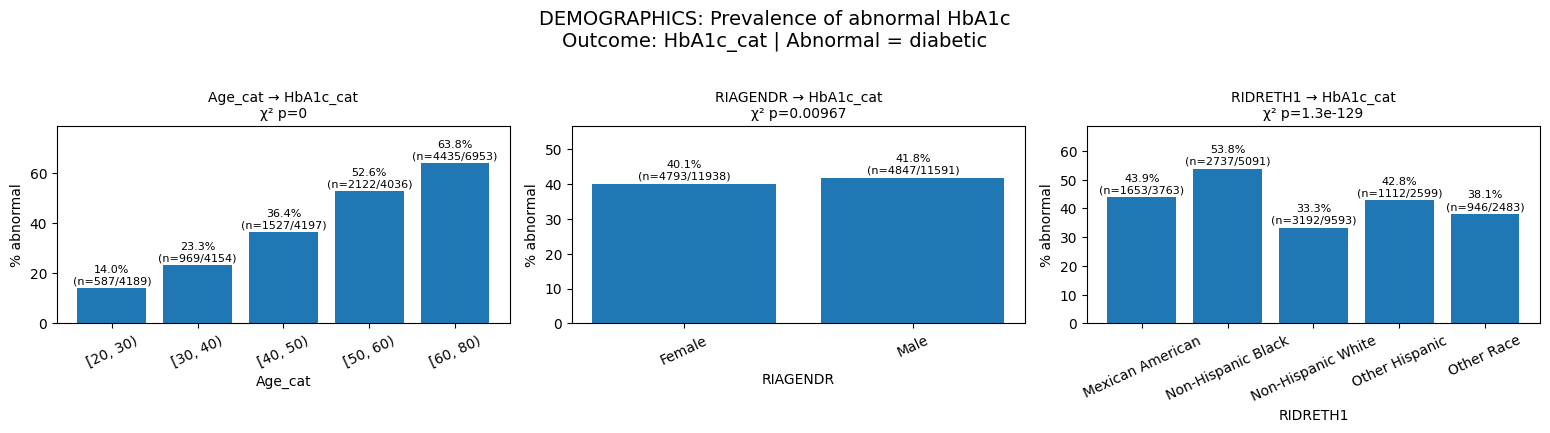

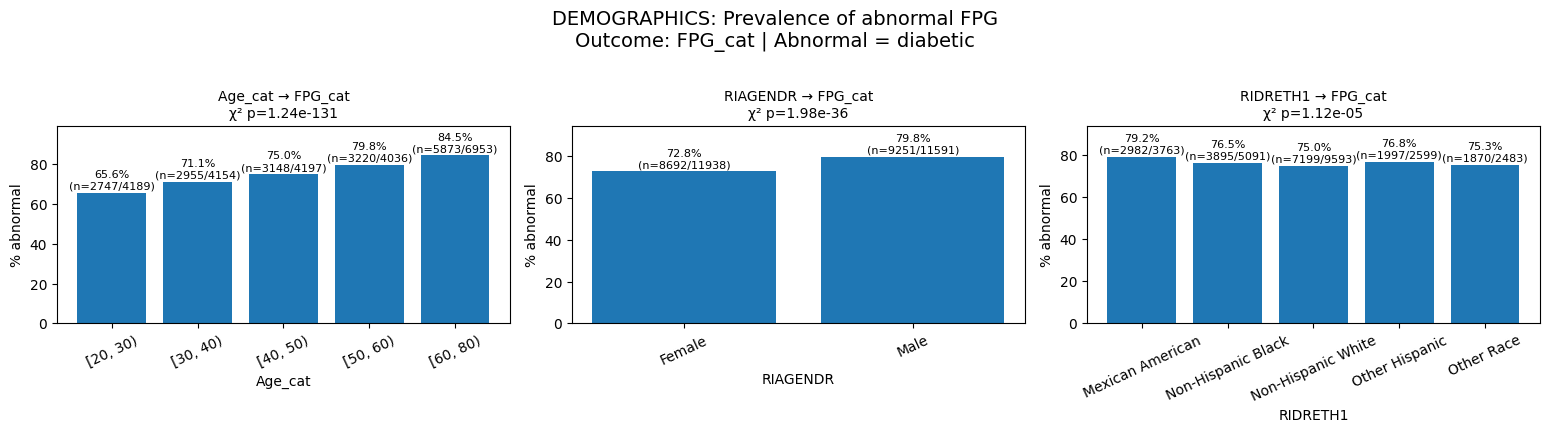

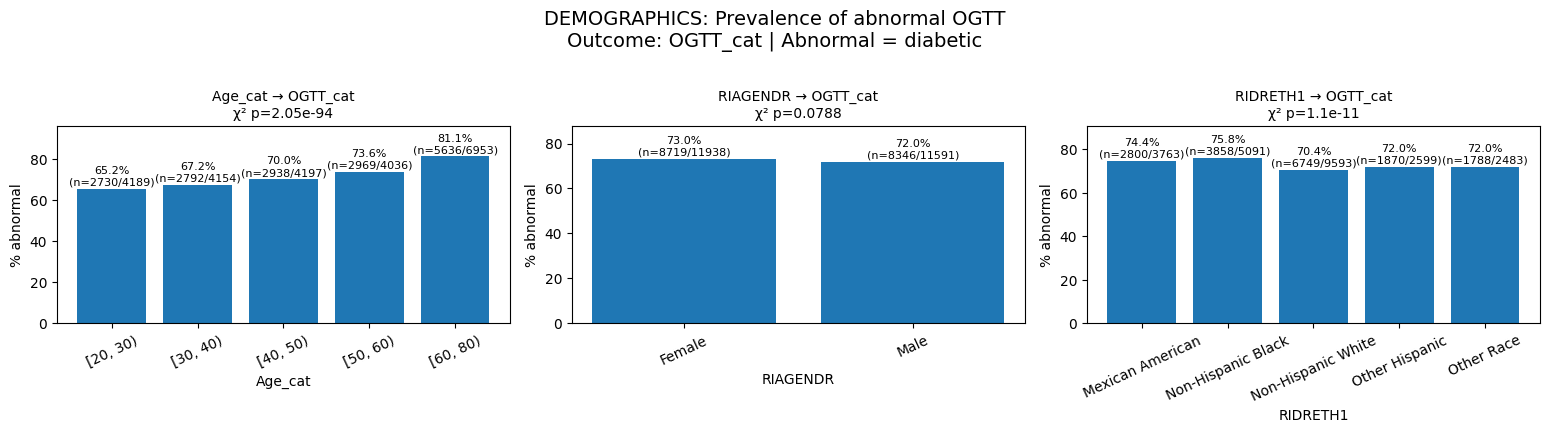

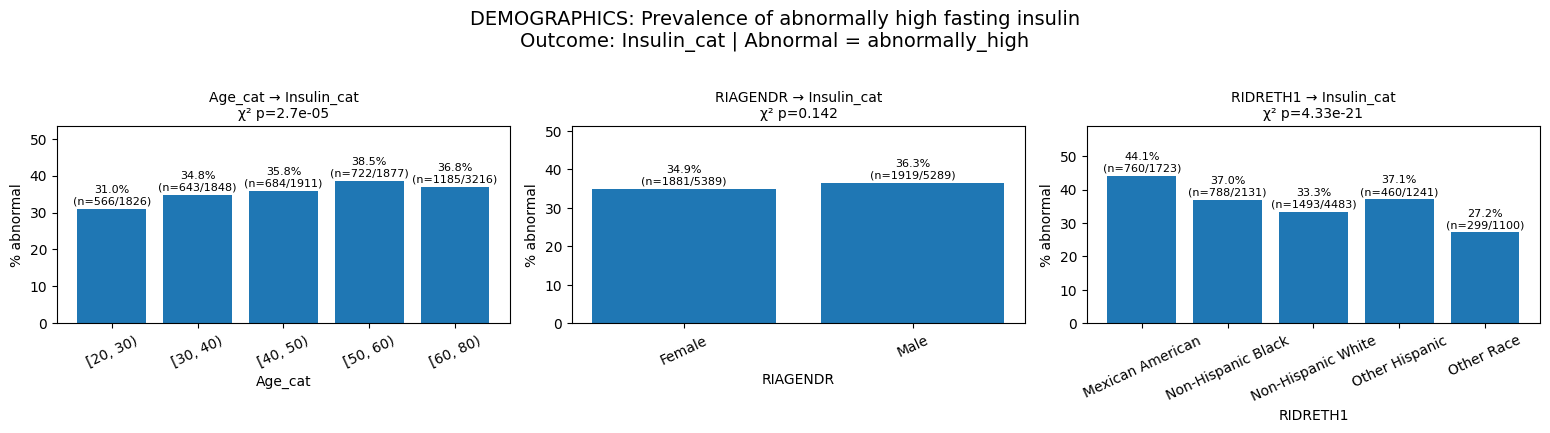

In [88]:
# DEMOGRAPHICS GROUP - Prevalence bar charts for HbA1c, FPG, OGTT, and Insulin

# Prevalence bar chart for HbA1c by demographics
plot_prevalence_group_one_shot(
    df_model,
    outcome_col="HbA1c_cat",
    abnormal_labels="diabetic",  # abnormal for HbA1c is 'diabetic'
    predictor_list=["Age_cat", "RIAGENDR", "RIDRETH1"],
    group_title="DEMOGRAPHICS: Prevalence of abnormal HbA1c"
)

# Prevalence bar chart for FPG by demographics
plot_prevalence_group_one_shot(
    df_model,
    outcome_col="FPG_cat",
    abnormal_labels="diabetic",  # abnormal for FPG is 'diabetic'
    predictor_list=["Age_cat", "RIAGENDR", "RIDRETH1"],
    group_title="DEMOGRAPHICS: Prevalence of abnormal FPG"
)

# Prevalence bar chart for OGTT by demographics
plot_prevalence_group_one_shot(
    df_model,
    outcome_col="OGTT_cat",
    abnormal_labels="diabetic",  # abnormal for OGTT is 'diabetic'
    predictor_list=["Age_cat", "RIAGENDR", "RIDRETH1"],
    group_title="DEMOGRAPHICS: Prevalence of abnormal OGTT"
)

# Prevalence bar chart for fasting insulin by demographics
plot_prevalence_group_one_shot(
    df_model,
    outcome_col="Insulin_cat",
    abnormal_labels="abnormally_high",  # abnormal for Insulin is 'abnormally_high'
    predictor_list=["Age_cat", "RIAGENDR", "RIDRETH1"],
    group_title="DEMOGRAPHICS: Prevalence of abnormally high fasting insulin"
)

**age and biomarkers**

X^2 test significance:
all p values for the association between age and all the biomarker are highly significant showing strong association between them age and the prevalence of abnormal biomarkers.


*   younger adults(20-29) show the show the lowest prevalence(14.0% for HbA1c) while older adults (60-80) show higher prevalence (63.8% for HbA1c, 84.5% for FPG, and 81.1% for OGTT)
*   for insulin, prevalence of abnormally high insulin also increaes with age, peaking at 36.8% in the 60-80 age group

Age is a strong predictor of impaired glucos regulation. older adults being more liekly to have abnormal glucose metabolism and insulin resistance. These trends suggest athat age plays a key role in diabetes development, older indidviduals at higher risk.

**gender and biomarkers**

X^2 test significance: p valhes for the association between gender and biomarkers are statistically significant, showing that gender plays a role in the likelihood of having abnormal biomarker levels


*   males generally show higher prevalence of abnormal FPG and insulin resistance than females
*   For HbA1c, the difference between mae and female is smaller with a difference of 1.7%
*   females show slightly higher prevalence of abnormaol OGTT comapared to males

Males tend to have higher insulin resistance and abnormal FPG while females show slightly higher rates of abnormal OGTT suggesting gender-specific factors such as insulin sensitivity or hormonal differences which contirbute to diabetes risk


**ethnicity and biomarkers**

X^2 test significance:
the p values for the associaton between ethnicity and biomarkers are highly significant showing ethnicity is a significant factor for influencing prevalence of abnormal biomarkers


*   mexican americans consistently show highest prevalence across all biomarkers.

the higher prevalence of abnormal biomarkers in mexican americans suggests that ethnicity is crucial in understanding the risk of diabetes. this could be due to varies factors including access to care and social determinants of health.





###Lifestyle x biomarkers

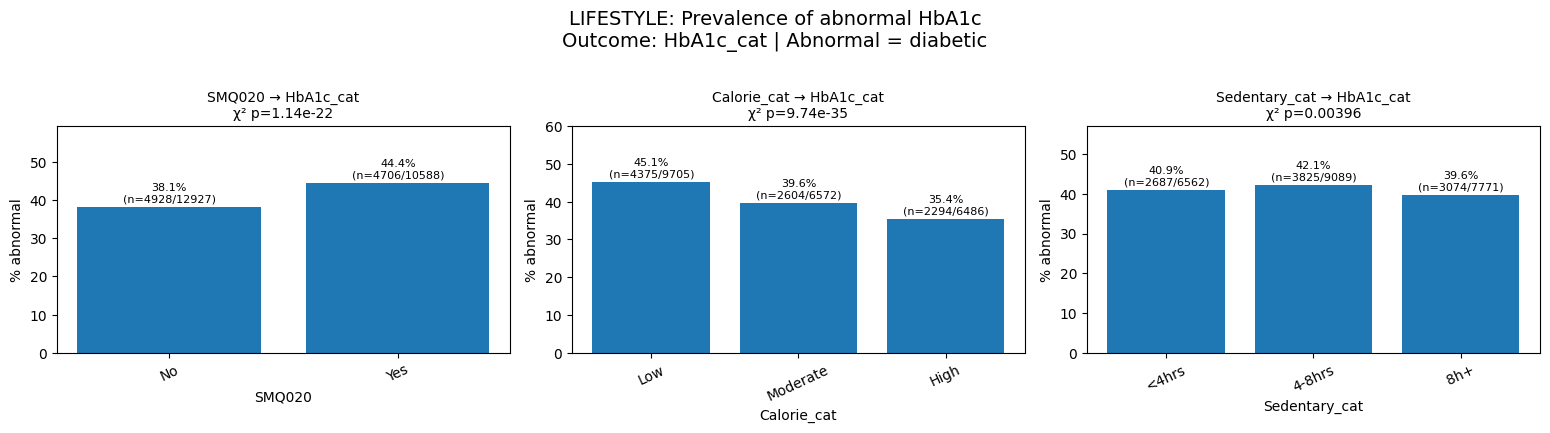

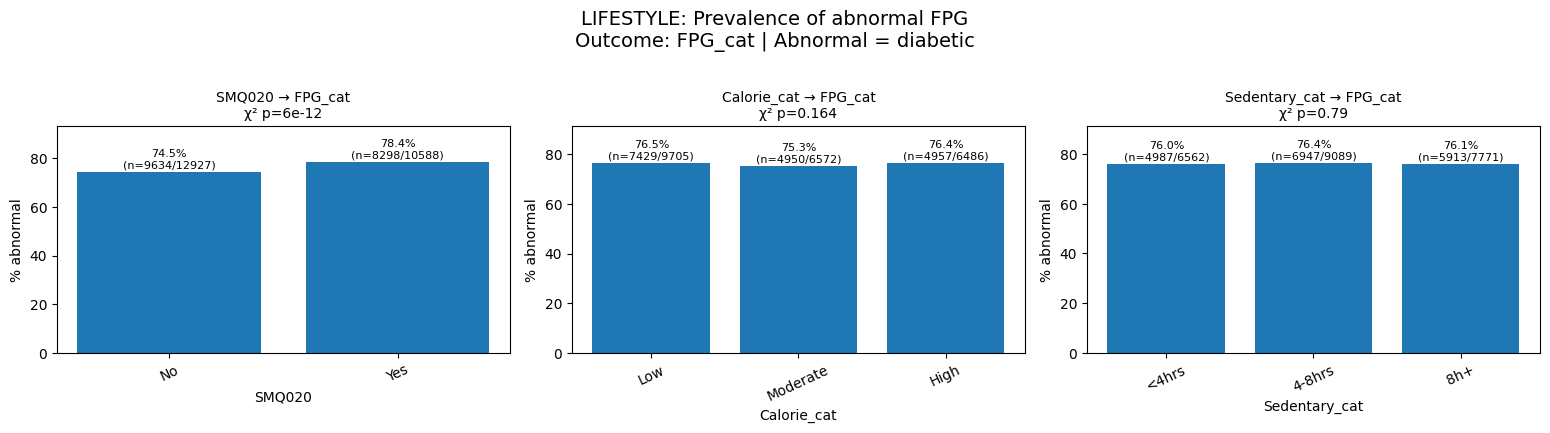

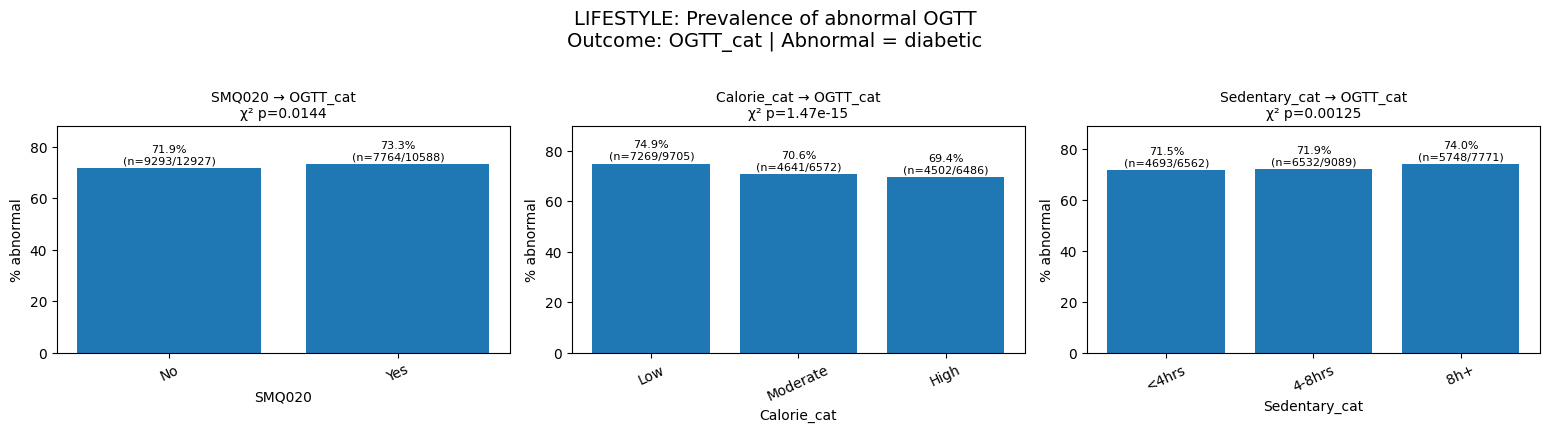

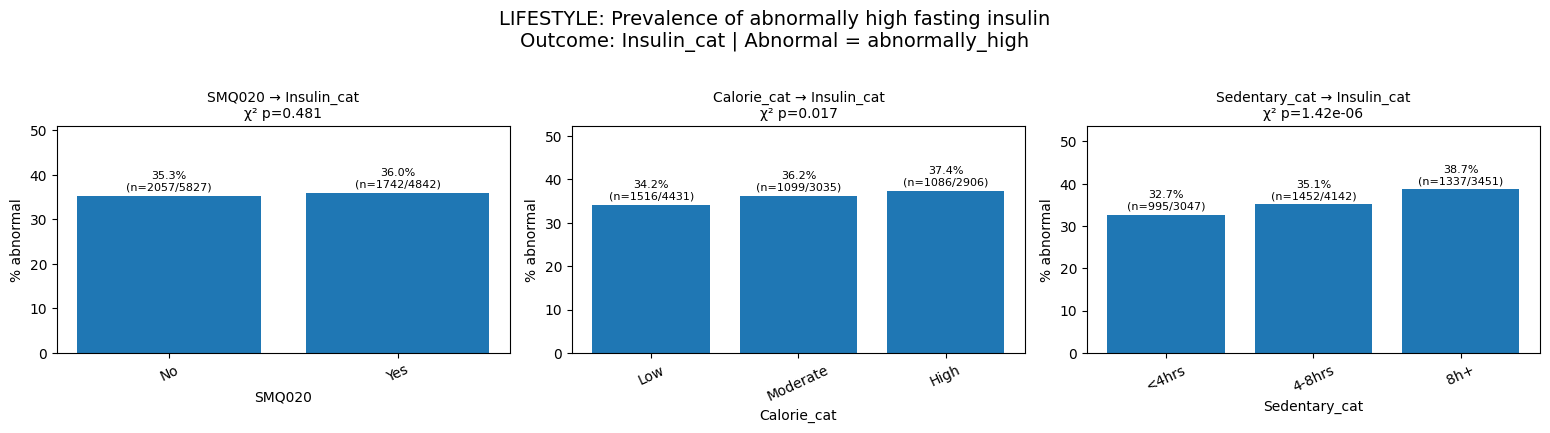

In [66]:
# LIFESTYLE GROUP - Prevalence bar charts for HbA1c, FPG, OGTT, and Insulin

# Prevalence bar chart for HbA1c by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="HbA1c_cat",
    abnormal_labels="diabetic",  # abnormal for HbA1c is 'diabetic'
    predictor_list=["SMQ020", "Calorie_cat", "Sedentary_cat"],
    group_title="LIFESTYLE: Prevalence of abnormal HbA1c"
)

# Prevalence bar chart for FPG by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="FPG_cat",
    abnormal_labels="diabetic",  # abnormal for FPG is 'diabetic'
    predictor_list=["SMQ020", "Calorie_cat", "Sedentary_cat"],
    group_title="LIFESTYLE: Prevalence of abnormal FPG"
)

# Prevalence bar chart for OGTT by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="OGTT_cat",
    abnormal_labels="diabetic",  # abnormal for OGTT is 'diabetic'
    predictor_list=["SMQ020", "Calorie_cat", "Sedentary_cat"],
    group_title="LIFESTYLE: Prevalence of abnormal OGTT"
)

# Prevalence bar chart for fasting insulin by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="Insulin_cat",
    abnormal_labels="abnormally_high",  # abnormal for Insulin is 'abnormally_high'
    predictor_list=["SMQ020", "Calorie_cat", "Sedentary_cat"],
    group_title="LIFESTYLE: Prevalence of abnormally high fasting insulin"
)

**smoking status x biomarkers**

X^2 significance test: all p values for the association between smoking status and all the biomarker are highly significant showing strong association between them age and the prevalence of abnormal biomarkers.






###Anthropometric/Clinical x biomarkers

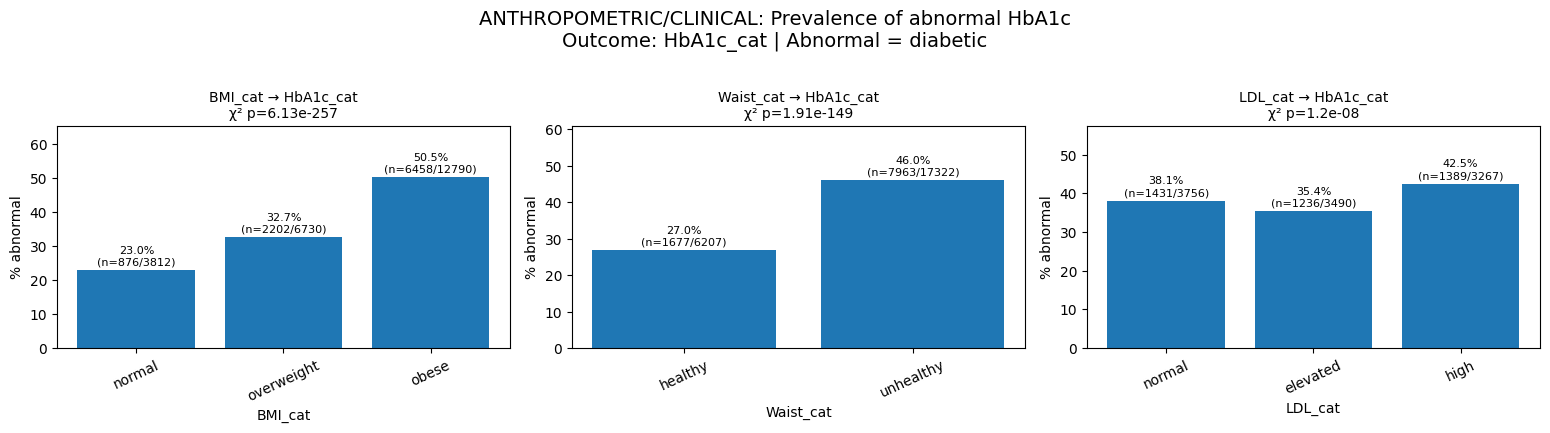

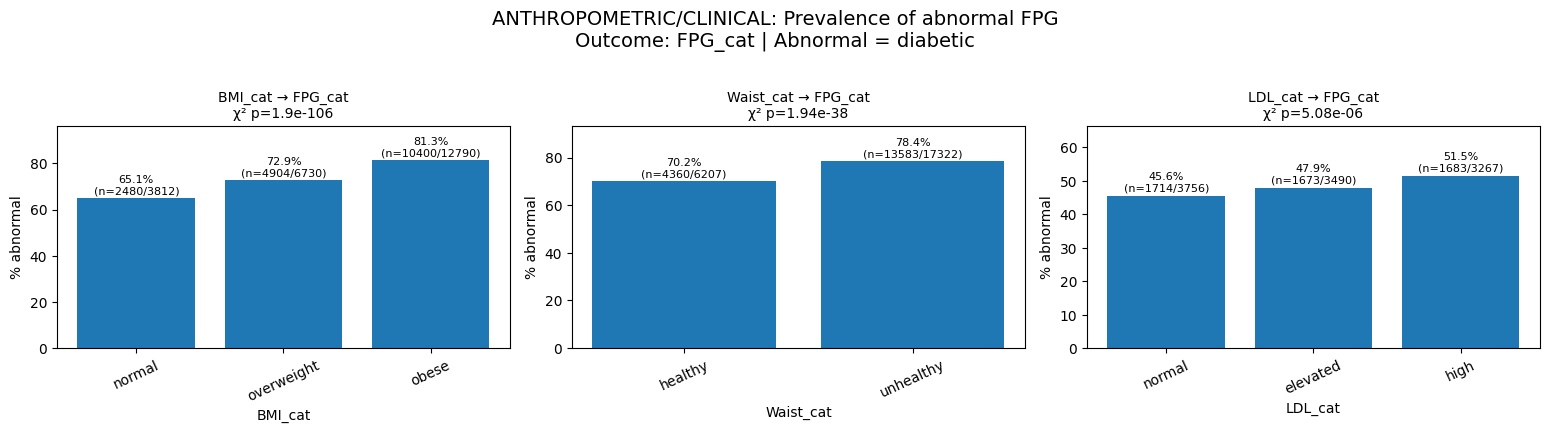

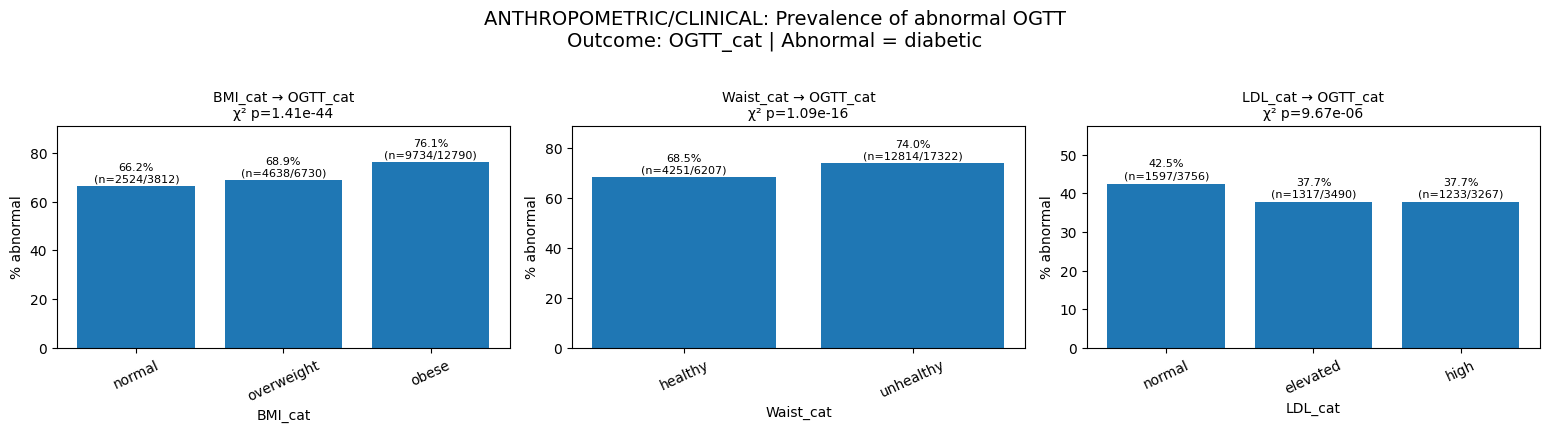

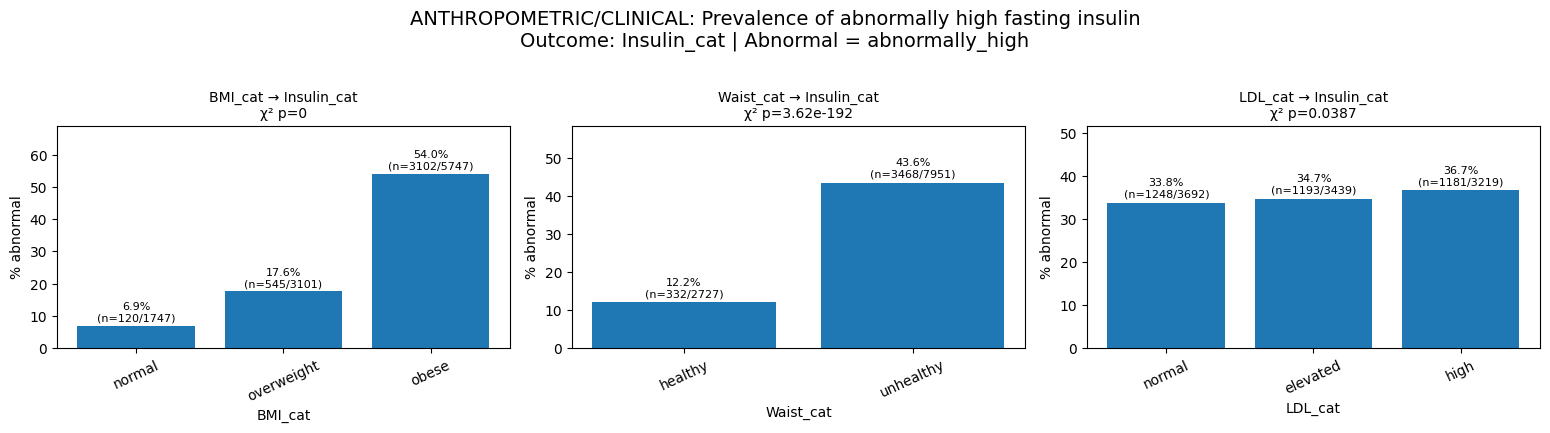

In [67]:
# ANTHROPOMETRIC/CLINICAL GROUP - Prevalence bar charts for HbA1c, FPG, OGTT, and Insulin

# Prevalence bar chart for HbA1c by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="HbA1c_cat",
    abnormal_labels="diabetic",  # abnormal for HbA1c is 'diabetic'
    predictor_list=["BMI_cat", "Waist_cat", "LDL_cat"],
    group_title="ANTHROPOMETRIC/CLINICAL: Prevalence of abnormal HbA1c"
)

# Prevalence bar chart for FPG by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="FPG_cat",
    abnormal_labels="diabetic",  # abnormal for FPG is 'diabetic'
    predictor_list=["BMI_cat", "Waist_cat", "LDL_cat"],
    group_title="ANTHROPOMETRIC/CLINICAL: Prevalence of abnormal FPG"
)

# Prevalence bar chart for OGTT by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="OGTT_cat",
    abnormal_labels="diabetic",  # abnormal for OGTT is 'diabetic'
    predictor_list=["BMI_cat", "Waist_cat", "LDL_cat"],
    group_title="ANTHROPOMETRIC/CLINICAL: Prevalence of abnormal OGTT"
)

# Prevalence bar chart for fasting insulin by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="Insulin_cat",
    abnormal_labels="abnormally_high",  # abnormal for Insulin is 'abnormally_high'
    predictor_list=["BMI_cat", "Waist_cat", "LDL_cat"],
    group_title="ANTHROPOMETRIC/CLINICAL: Prevalence of abnormally high fasting insulin"
)

###Diabetes History x biomarkers

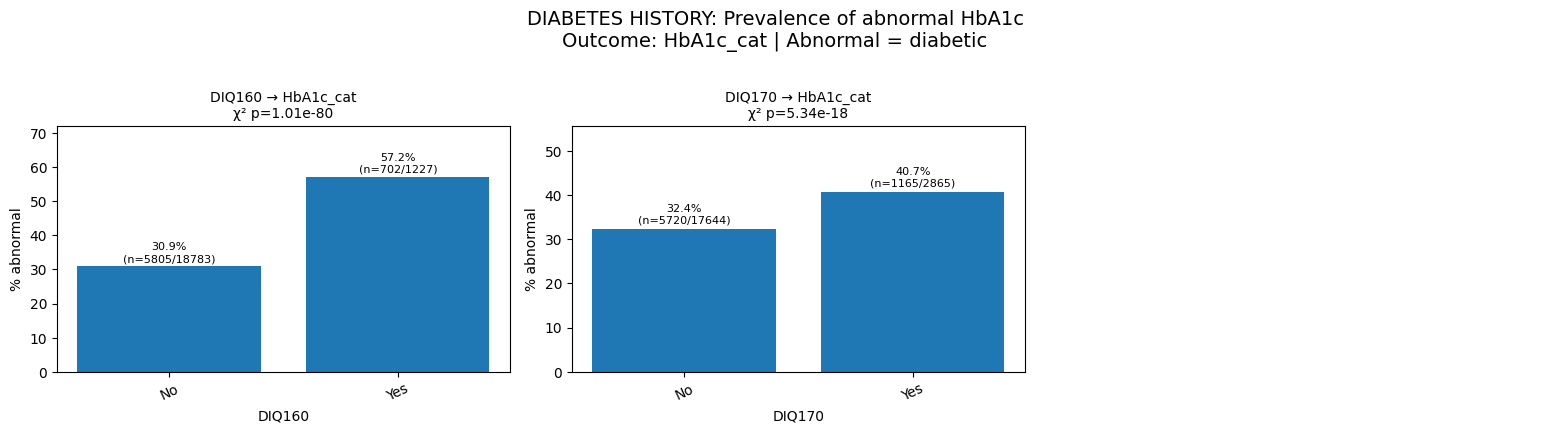

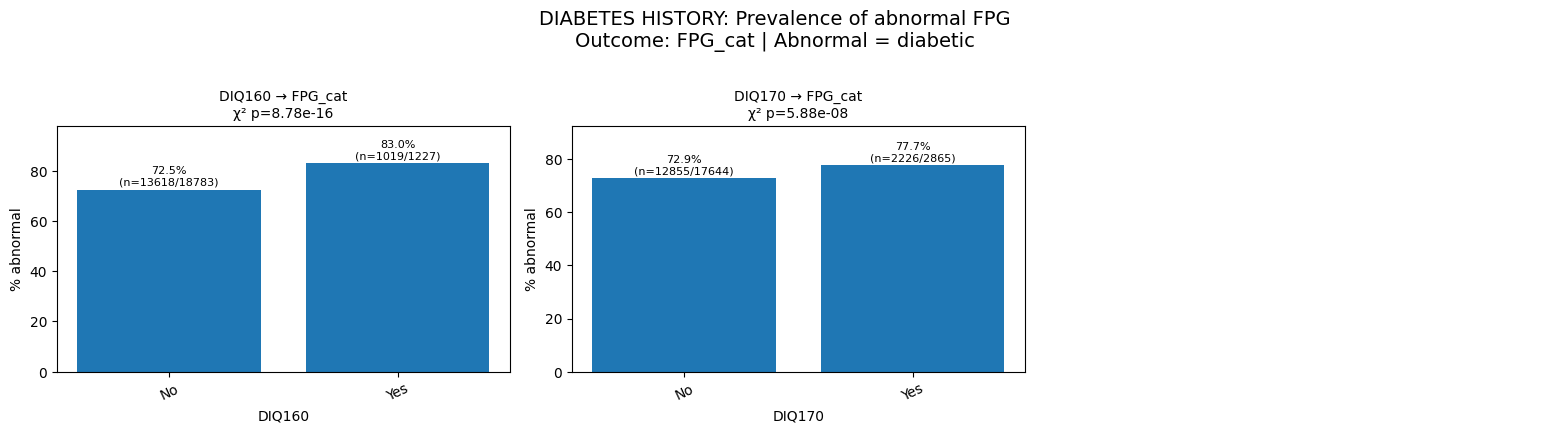

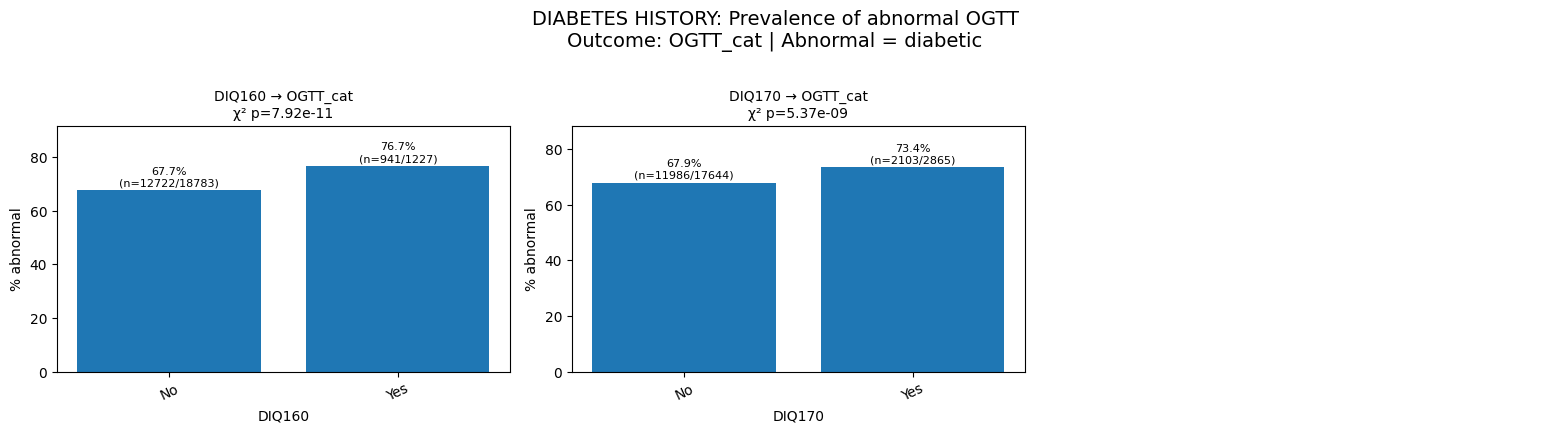

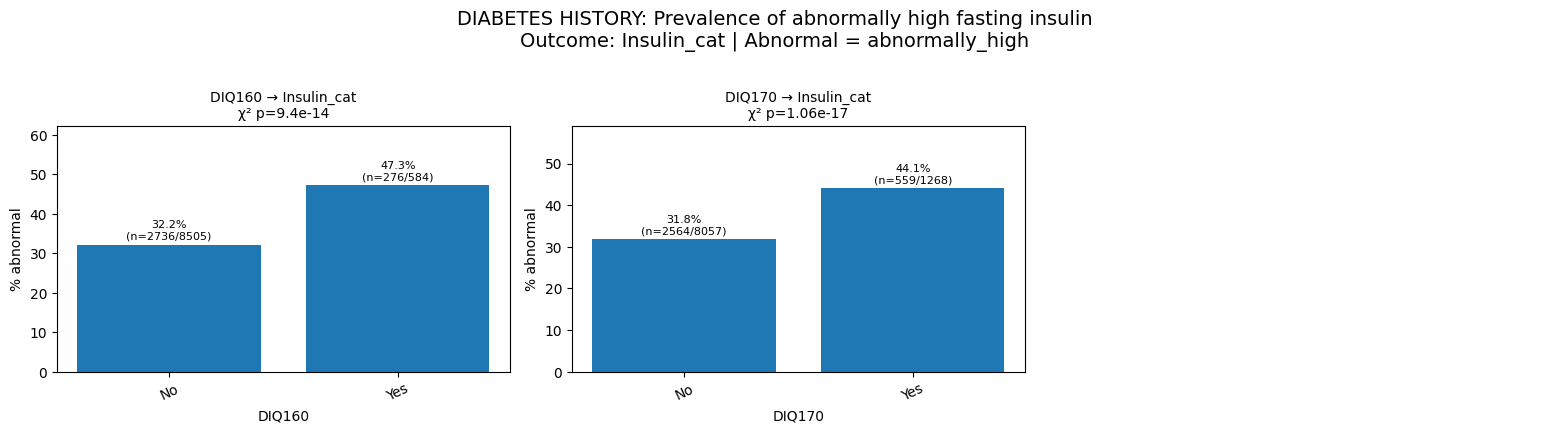

In [68]:
# DIABETES HISTORY GROUP - Prevalence bar charts for HbA1c, FPG, OGTT, and Insulin

# Prevalence bar chart for HbA1c by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="HbA1c_cat",
    abnormal_labels="diabetic",  # abnormal for HbA1c is 'diabetic'
    predictor_list=["DIQ160", "DIQ170"],
    group_title="DIABETES HISTORY: Prevalence of abnormal HbA1c"
)

# Prevalence bar chart for FPG by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="FPG_cat",
    abnormal_labels="diabetic",  # abnormal for FPG is 'diabetic'
    predictor_list=["DIQ160", "DIQ170"],
    group_title="DIABETES HISTORY: Prevalence of abnormal FPG"
)

# Prevalence bar chart for OGTT by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="OGTT_cat",
    abnormal_labels="diabetic",  # abnormal for OGTT is 'diabetic'
    predictor_list=["DIQ160", "DIQ170"],
    group_title="DIABETES HISTORY: Prevalence of abnormal OGTT"
)

# Prevalence bar chart for fasting insulin by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="Insulin_cat",
    abnormal_labels="abnormally_high",  # abnormal for Insulin is 'abnormally_high'
    predictor_list=["DIQ160", "DIQ170"],
    group_title="DIABETES HISTORY: Prevalence of abnormally high fasting insulin"
)

###Socioeconomic status x Biomarkers

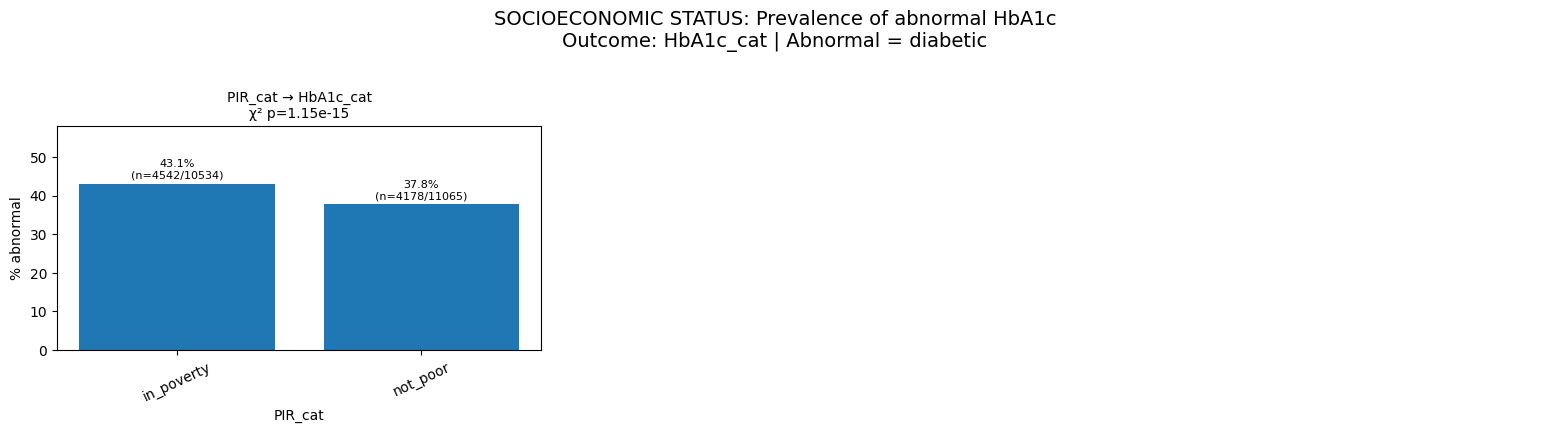

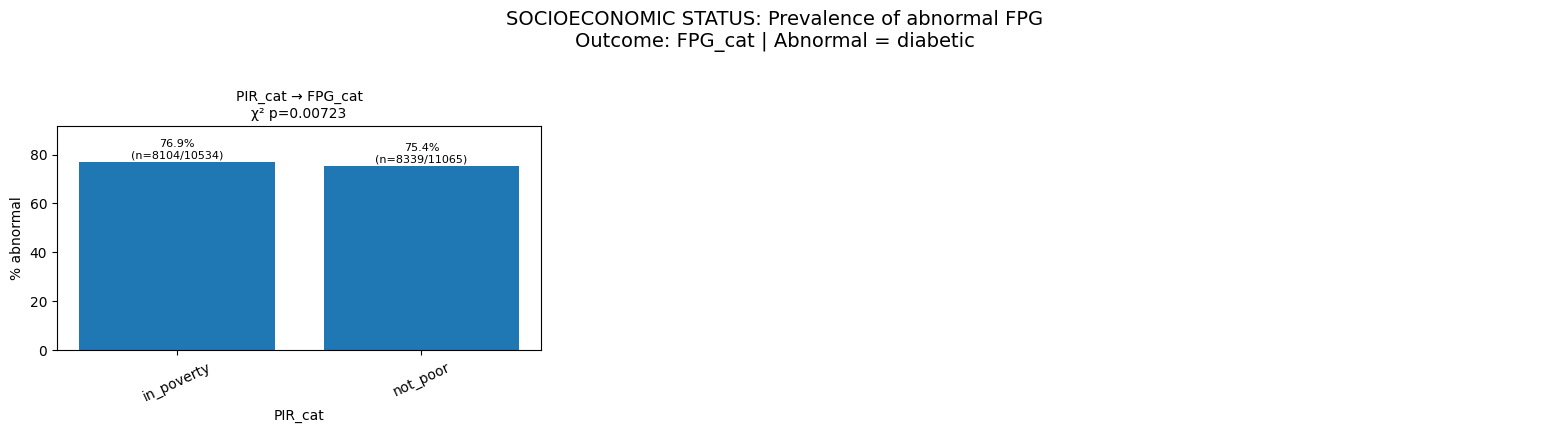

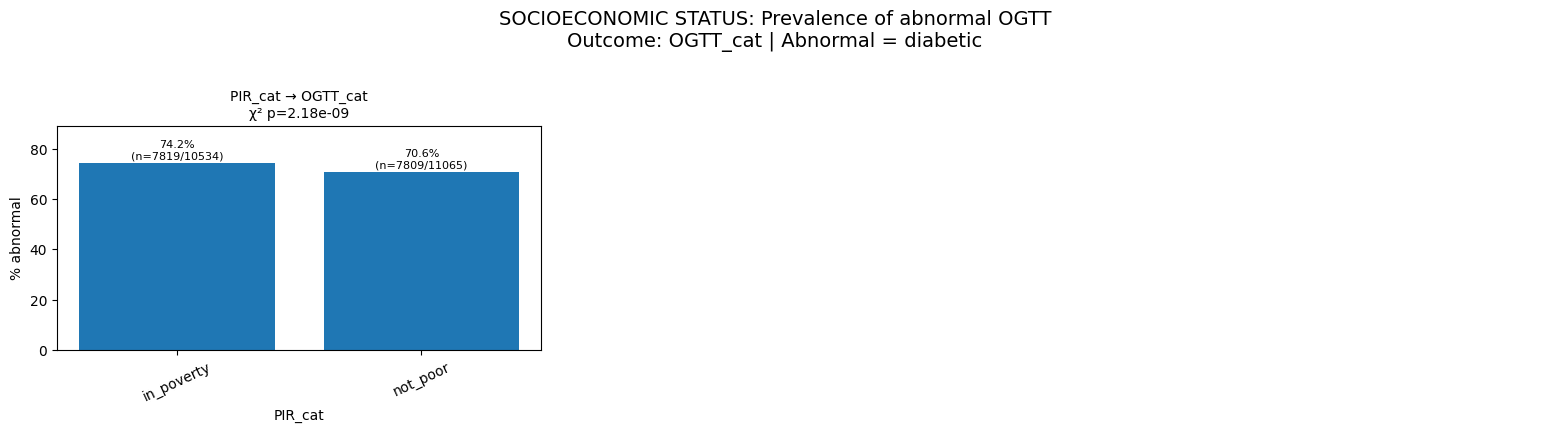

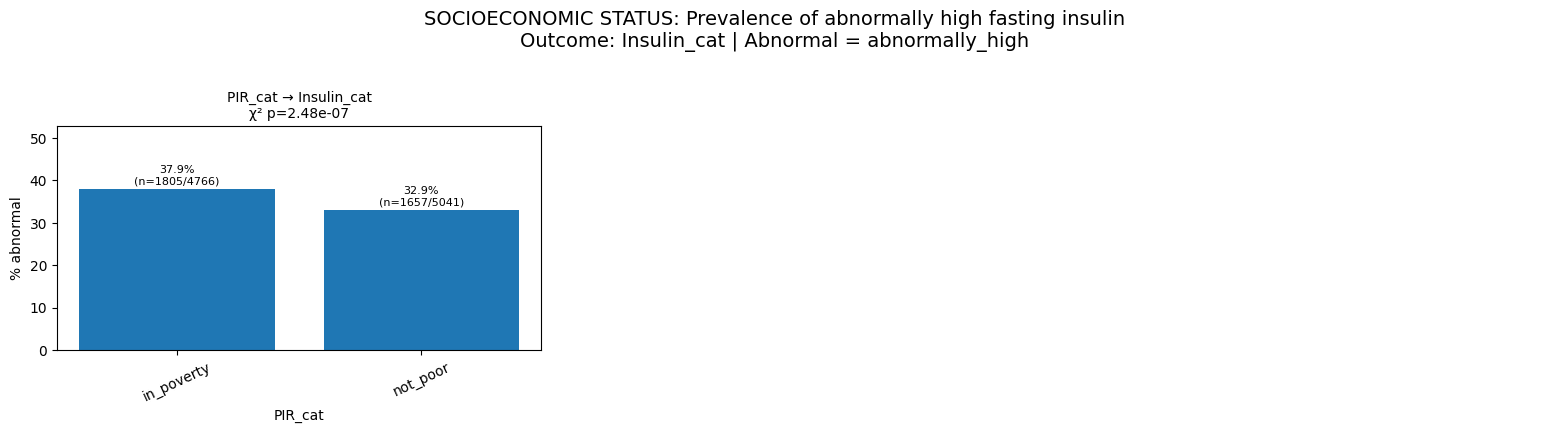

In [69]:
# SOCIOECONOMIC STATUS GROUP - Prevalence bar charts for HbA1c, FPG, OGTT, and Insulin

# Prevalence bar chart for HbA1c by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="HbA1c_cat",
    abnormal_labels="diabetic",  # abnormal for HbA1c is 'diabetic'
    predictor_list=["PIR_cat"],
    group_title="SOCIOECONOMIC STATUS: Prevalence of abnormal HbA1c"
)

# Prevalence bar chart for FPG by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="FPG_cat",
    abnormal_labels="diabetic",  # abnormal for FPG is 'diabetic'
    predictor_list=["PIR_cat"],
    group_title="SOCIOECONOMIC STATUS: Prevalence of abnormal FPG"
)

# Prevalence bar chart for OGTT by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="OGTT_cat",
    abnormal_labels="diabetic",  # abnormal for OGTT is 'diabetic'
    predictor_list=["PIR_cat"],
    group_title="SOCIOECONOMIC STATUS: Prevalence of abnormal OGTT"
)

# Prevalence bar chart for fasting insulin by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="Insulin_cat",
    abnormal_labels="abnormally_high",  # abnormal for Insulin is 'abnormally_high'
    predictor_list=["PIR_cat"],
    group_title="SOCIOECONOMIC STATUS: Prevalence of abnormally high fasting insulin"
)

###Depression Score x biomarkers

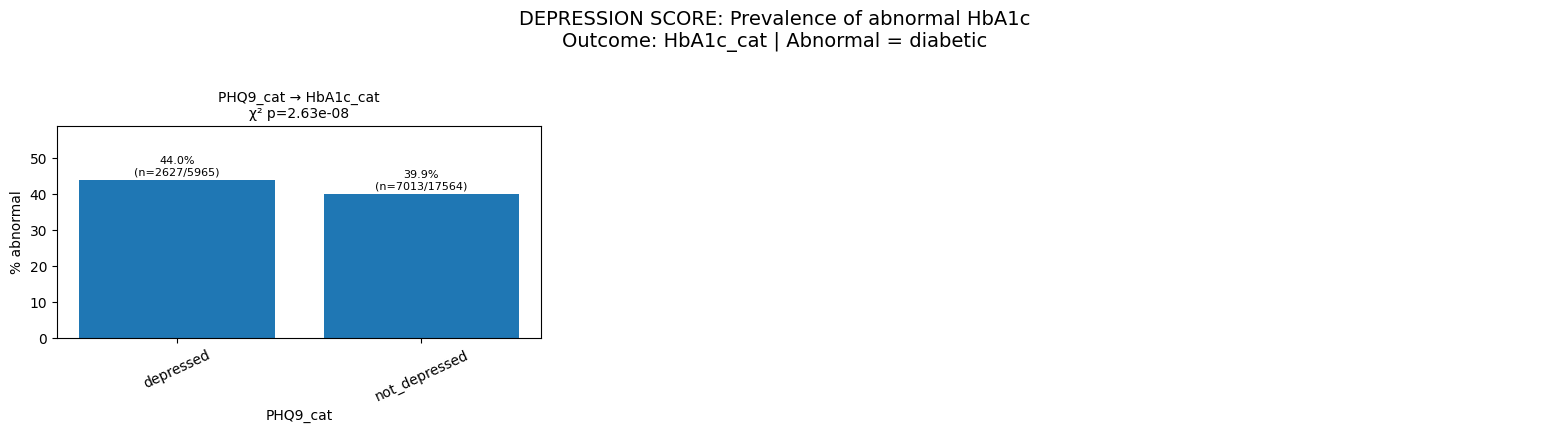

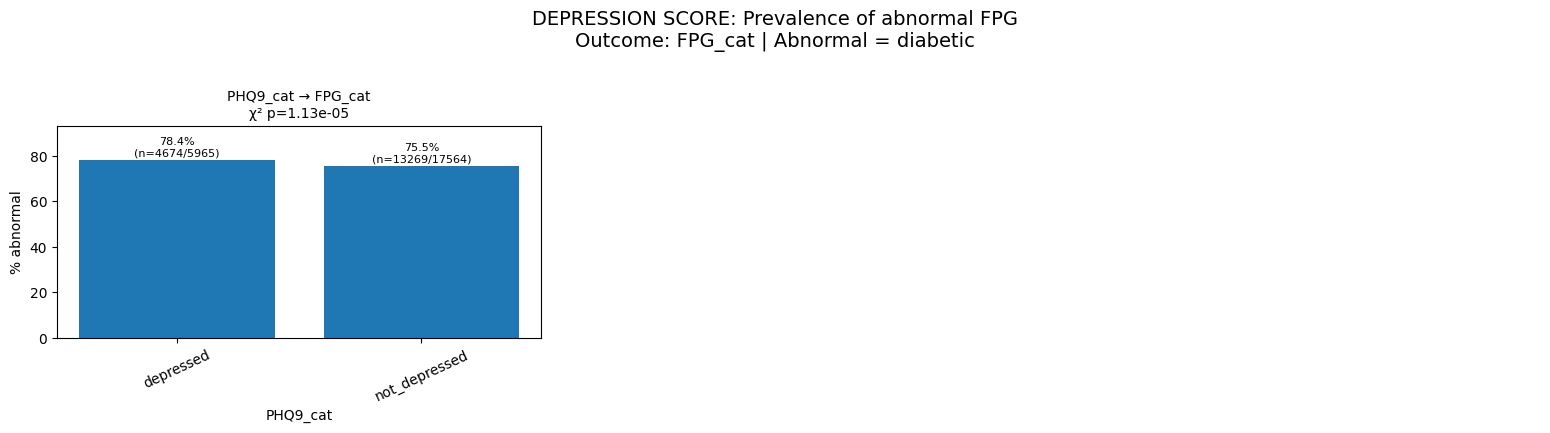

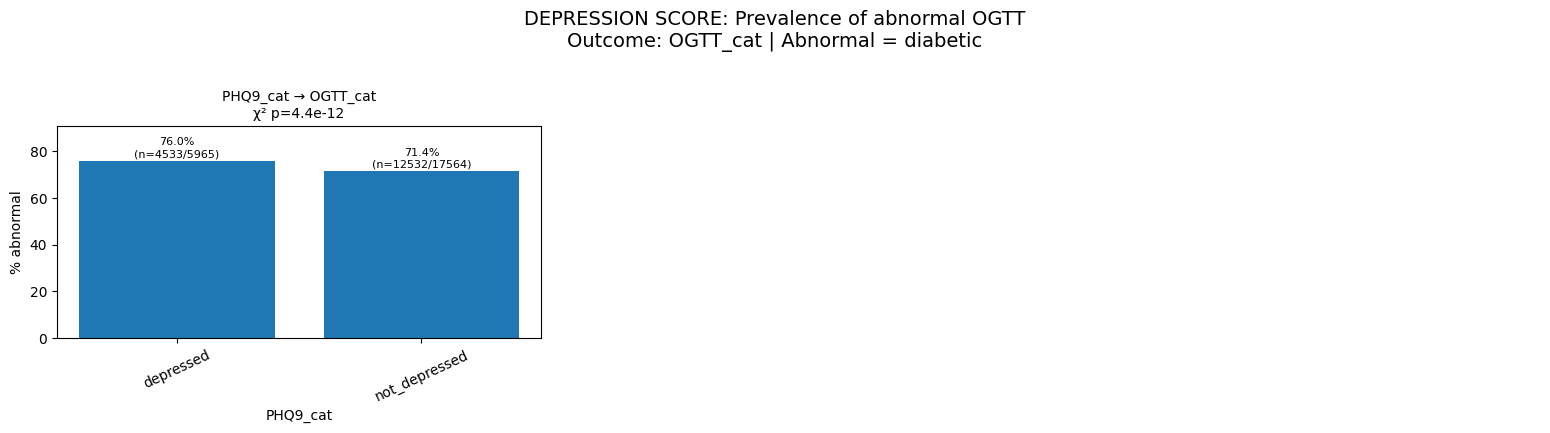

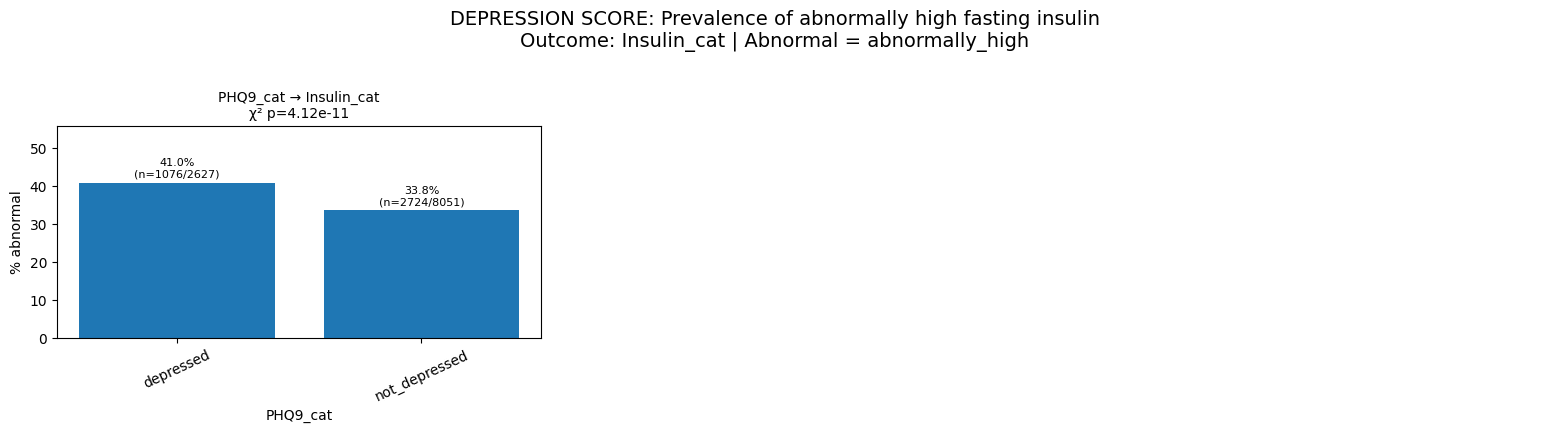

In [70]:
# DEPRESSION SCORE GROUP - Prevalence bar charts for HbA1c, FPG, OGTT, and Insulin

# Prevalence bar chart for HbA1c by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="HbA1c_cat",
    abnormal_labels="diabetic",  # abnormal for HbA1c is 'diabetic'
    predictor_list=["PHQ9_cat"],
    group_title="DEPRESSION SCORE: Prevalence of abnormal HbA1c"
)

# Prevalence bar chart for FPG by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="FPG_cat",
    abnormal_labels="diabetic",  # abnormal for FPG is 'diabetic'
    predictor_list=["PHQ9_cat"],
    group_title="DEPRESSION SCORE: Prevalence of abnormal FPG"
)

# Prevalence bar chart for OGTT by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="OGTT_cat",
    abnormal_labels="diabetic",  # abnormal for OGTT is 'diabetic'
    predictor_list=["PHQ9_cat"],
    group_title="DEPRESSION SCORE: Prevalence of abnormal OGTT"
)

# Prevalence bar chart for fasting insulin by demographics
plot_prevalence_group_one_shot(
    df,
    outcome_col="Insulin_cat",
    abnormal_labels="abnormally_high",  # abnormal for Insulin is 'abnormally_high'
    predictor_list=["PHQ9_cat"],
    group_title="DEPRESSION SCORE: Prevalence of abnormally high fasting insulin"
)

# **3. Logistic Regression (Associative modelling) - HbA1c outcome**

In [71]:
#Logistic Regression for HbA1c
#This section will only use elevated HbA1c to determine if person has diabetes or not

#list of all the categories to be used in the regression
columns = ["HbA1c_cat", "FPG_cat", "OGTT_cat", "Insulin_cat",
    "PHQ9_cat", "BMI_cat", "PIR_cat", "Waist_cat",
    "Sedentary_cat", "Age_cat", "LDL_cat", "Calorie_cat", "RIDRETH1", "DIQ160", "DIQ170", "SMQ020"
]

#Create new dataframe with variables of interest and remove rows with missing data
model_df = df_model[columns].dropna()

#Make dataframe using only predictors. This ix X. We are removing outcome variable.
X = model_df.drop(columns=['HbA1c_cat'])

#Define the outcome dataset (y)
#Convert outcome variable into binary numeric format to meet requirements of logistic regression
y = model_df['HbA1c_cat'].map({'normal': 0, 'diabetic': 1})

#Convert each categorical variable into binary (0/1) indicator variables
#Each dummy variable represents membership in a category.
#True = 1 and False = 0
# 0 means individual is not in the category. 1 means individual belongs in the category
#drop_first = True removes the reference category for each
X = pd.get_dummies(X, drop_first=True, dtype=int)
print("Dummy-encoded predictors shape:", X.shape)
X.head()


HbA1c_cat
0    5532
1    2291
Name: count, dtype: int64
Dummy-encoded predictors shape: (7823, 26)


,FPG_cat_normal,OGTT_cat_normal,Insulin_cat_normal,Insulin_cat_abnormally_high,PHQ9_cat_not_depressed,BMI_cat_overweight,BMI_cat_obese,PIR_cat_not_poor,Waist_cat_unhealthy,Sedentary_cat_4-8hrs,...,LDL_cat_high,Calorie_cat_Moderate,Calorie_cat_High,RIDRETH1_Non-Hispanic Black,RIDRETH1_Non-Hispanic White,RIDRETH1_Other Hispanic,RIDRETH1_Other Race,DIQ160_Yes,DIQ170_Yes,SMQ020_Yes
2,0,1,1,0,1,0,1,1,1,0,...,0,0,1,0,0,0,0,0,0,0
5,1,1,1,0,1,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
6,0,0,0,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
7,0,1,1,0,1,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
8,1,1,0,1,1,0,1,1,1,0,...,0,1,0,0,0,0,0,0,0,0


In [72]:
#Fit the logistic regression model
#Use statsmodels to get full stats output (coeff, SE, p-value, Cls)

#Add constant(intercept, β0) as statsmodels does not automatically include
#To prevent regression from being forced through 0, allowing model to predict baseline log-odds
X = sm.add_constant(X)

#Define logistic regression model
#y = outcome (must be 0/1)
#X = predictors (dummy + const)
logit_model = sm.Logit(y, X)

#Fit the model to estimate parameters
#Uses Maximum Likelihood Estimation (MLE)
result = logit_model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.474144
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:              HbA1c_cat   No. Observations:                 7823
Model:                          Logit   Df Residuals:                     7796
Method:                           MLE   Df Model:                           26
Date:                Fri, 23 Jan 2026   Pseudo R-squ.:                  0.2159
Time:                        11:36:25   Log-Likelihood:                -3709.2
converged:                       True   LL-Null:                       -4730.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -1.8114      0.269     -6.742      0.000   

#**Analysis of Logistc Regression for HbA1c outcome**


1. Model Overview

| Metric                         | Value     |
| ------------------------------ | --------- |
| Dependent Variable             | HbA1c_cat |
| Model                          | Logit     |
| Method                         | MLE       |
| No. Observations               | 7823      |
| Degrees of Freedom (Model)     | 26        |
| Degrees of Freedom (Residuals) | 7796      |
| Log-Likelihood                 | -3709.2   |
| LL-Null                        | -4730.5   |
| Pseudo R²                      | 0.2159    |
| LLR p-value                    | < 0.001   |
| Converged                      | True      |
| Iterations                     | 6         |

2. Key Predictors and Their Effects on HbA1c Category


Coefficients are in log-odds.

Ods Ratio (OR) = e^coef

OR > 1 → higher odds of elevated HbA1c

OR < 1 → lower odds of elevated HbA1c

| Predictor                           | Coef (log-odds) | Odds Ratio (OR) | p-value | Interpretation                                                                                              |
| ----------------------------------- | --------------- | --------------- | ------- | ----------------------------------------------------------------------------------------------------------- |
| **FPG_cat_normal**                  | -0.8838         | **0.41**        | <0.001  | Normal fasting plasma glucose is associated with ~59% lower odds of getting diabetes compared to abnormal FPG |
| **OGTT_cat_normal**                 | -0.5631         | **0.57**        | <0.001  | Normal OGTT is associated with ~43% lower odds of getting diabetes                                            |
| **BMI_cat_obese**                   | 0.4116          | **1.51**        | <0.001  | Obese individuals have ~51% higher odds of getting diabetes compared to normal BMI                            |
| **PIR_cat_not_poor**                | -0.1656         | **0.85**        | 0.007   | Higher income (not poor) is associated with ~15% lower odds of getting diabetes                               |
| **Sedentary_cat_8h+**               | -0.2494         | **0.78**        | 0.001   | ≥8 hours sedentary time shows lower odds of getting diabetes (possible confounding/reverse causation)         |
| **Age_cat_[30,40)**                 | 0.4913          | **1.63**        | <0.001  | Adults aged 30–39 have ~63% higher odds of getting diabetes compared to <30                                                     |
| **Age_cat_[40,50)**                 | 1.0416          | **2.83**        | <0.001  | Adults aged 40–49 have nearly 3× higher odds of getting diabetes                                                                |
| **Age_cat_[50,60)**                 | 1.5561          | **4.74**        | <0.001  | Adults aged 50–59 have ~4.7× higher odds of getting diabetes                                                                   |
| **Age_cat_[60,80)**                 | 2.0257          | **7.58**        | <0.001  | Adults aged 60–79 have over 7× higher odds of getting diabetes                                                                  |
| **LDL_cat_high**                    | 0.3772          | **1.46**        | <0.001  | High LDL cholesterol is associated with ~46% higher odds of getting diabetes                                                    |
| **RIDRETH1_Non-Hispanic Black**     | 0.7639          | **2.15**        | <0.001  | Non-Hispanic Black individuals have over 2× higher odds of getting diabetes                                                     |
| **RIDRETH1_Non-Hispanic White**     | -0.5022         | **0.61**        | <0.001  | Non-Hispanic White individuals have ~39% lower odds of getting diabetes                                                         |
| **DIQ160_Yes (Diabetes diagnosis)** | 0.4790          | **1.61**        | <0.001  | Self-reported diabetes is associated with ~61% higher odds of getting diabetes                                                  |
| **DIQ170_Yes (Prediabetes)**        | 0.2014          | **1.22**        | 0.019   | Prediabetes is associated with ~22% higher odds of getting diabetes                                                             |


3. Summary Interpretation

*   **Strongest positive predictors** of getting diabetes were older age (≥40 years), obesity, high LDL cholestrol, and Non-Hispanic Black ethnicity all remaining significant after adjustment.
*   Normal glycaemic measures (FPG and OGTT) were the **strongest protective factors**, showing substantially lower odds of getting diabetes.
*   Higher socioeconomic status was **independently protective**, indicating an income-related gradient in glycaemic risk.
*   Diabetes and prediabetes status remained **significant predictors**, consistent with progressive dysglycaemia.
*   PHQ-9, lifestyle (diet, smoking, sedentary time), insulin levels and overweight (non-obese BMI) were **not significant multivariable adjustment**.

4. Statistical Takeaways
| Statistic                                      | Meaning                                                                                                                                                                      |
| ---------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Most p-values < 0.05**                       | Strong evidence that several predictors (age, obesity, LDL, ethnicity, glycaemic markers) differ significantly from the null hypothesis (no effect).                         |
| **Pseudo R² ≈ 0.216**                          | Indicates **moderate explanatory power**, which is considered good for large population-based health survey data (typical range ≈ 0.10–0.30).                                |
| **Log-likelihood improvement (LLR p < 0.001)** | The full model fits the data **significantly better** than the null model with no predictors.                                                                                |
| **Intercept = −1.81**                          | Represents baseline log-odds of elevated HbA1c for the reference group (young, normal BMI, normal glucose, low-risk profile); corresponds to a **low baseline probability**. |
| **Clear dose–response patterns**               | Age categories show progressively increasing coefficients, supporting a **strong, monotonic risk relationship** rather than random association.                              |




In [73]:
from numpy._core.fromnumeric import var
#Helper section to interpret logistic regression results more clearly
#Identify the reference category for each categorical predictor
#Estimate baseline risk for the reference group by using the intercept to calculate the predicted probability of having high outcome value (elevated HbA1c)

cat_vars = [
    "FPG_cat",
    "OGTT_cat",
    "Insulin_cat",
    "PHQ9_cat",
    "BMI_cat",
    "PIR_cat",
    "Waist_cat",
    "Sedentary_cat",
    "Age_cat",
    "LDL_cat",
    "Calorie_cat",
    "RIDRETH1",
    "DIQ160",
    "DIQ170",
    "SMQ020"
]

#For "col" it collects all possible category levels
#Use (s.cat) as it uses pre-defined category order (can control which level is "first")
def levels_for(col):
  s = df[col]
  if hasattr(s, "cat"):
    return list(s.cat.categories)
  return sorted(s.dropna().astype(str).unique().tolist())

ref_cats = {col: levels_for(col)[0] for col in cat_vars}

#Predicting mean probability if everyone is set to one level (one variable at a time)
def mean_prob_for_level(var, level):
  X_mod = X.copy()
#Find all dummy columns for that variable
#Set all to 0
  mask = X_mod.columns.str.startswith(var + "_")
  X_mod.loc[:, mask] = 0
#If the level you want is not the reference, switch on the dummy(set to 1)
#If the level is the reference, keep all zeroes
  if level != ref_cats[var]:
    colname = f"{var}_{level}"
    if colname in X_mod.columns:
      X_mod.loc[:, colname] = 1
      return float(result.predict(X_mod).mean())

#Build a table for reference categories only
#For each variable, compute the mean predicted probability when everyone is forced to the reference category for that variable.
#Store as Baseline_p_hat
rows = []
for var in cat_vars:
  p_hat = mean_prob_for_level(var, ref_cats[var])
  if p_hat is None:
    continue
  rows.append({"Variable": var,
               "Reference_Category": ref_cats[var],
               "Baseline_p_hat": round(p_hat, 4)})
  ref_df = pd.DataFrame(rows)

  print("Baseline predicted probabilities for each reference level (others held as observed):")
  ref_df


In [74]:
#Tidying regression outputs for HbA1c outcome
#Generating a table showing the value of coefficients for the logistic refression, p-values and AME for analysis

#Coefficients/ORs/p-values/CIs
coef_df = pd.DataFrame({
    "coef": result.params,
    "p_value": result.pvalues,
})
ci = result.conf_int()
coef_df["OR"] = np.exp(ci[0])
coef_df["OR_CI_lower"] = np.exp(ci[0])
coef_df["OR_CI_upper"] = np.exp(ci[1])

#Average Marginal Effects (AMEs)
marg = result.get_margeff(at = "overall", method = "dydx", dummy = True)
ame_df = marg.summary_frame()

#print to see exact column names
print("AME columns:", ame_df.columns.tolist())

#Standardising
rename_map = {}
if "dy/dx" in ame_df.columns: rename_map["dy/dx"] = "AME"
if "Std. Err," in ame_df.columns: rename_map["Std. Err,"] = "Ame_SE"
if "z" in ame_df.columns: rename_map["z"] = "z"
if "P>|z|" in ame_df.columns: rename_map["P>|z|"] = "Ame_p_value"
if "[0.025" in ame_df.columns: rename_map["[0.025"] = "Ame_CI_lower"
if "0.975]" in ame_df.columns: rename_map["0.975]"] = "Ame_CI_upper"
ame_df = ame_df.rename(columns = rename_map)

#Join on index (variable names)
combined = coef_df.join(ame_df, how = "left")
combined.index.name = "Variable"

#Round to 3 decimal places
combined = combined.round(3)

display(combined)


AME columns: ['dy/dx', 'Std. Err.', 'z', 'Pr(>|z|)', 'Conf. Int. Low', 'Cont. Int. Hi.']


,coef,p_value,OR,OR_CI_lower,OR_CI_upper,AME,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
Variable,,,,,,,,,,,
const,-1.811,0.000,0.097,0.097,0.277,NaN,NaN,NaN,NaN,NaN,NaN
FPG_cat_normal,-0.884,0.000,0.366,0.366,0.466,-0.147,0.011,-13.977,0.000,-0.167,-0.126
OGTT_cat_normal,-0.563,0.000,0.504,0.504,0.643,-0.093,0.011,-8.683,0.000,-0.113,-0.072
Insulin_cat_normal,-0.005,0.981,0.639,0.639,1.548,-0.001,0.035,-0.024,0.981,-0.070,0.068
Insulin_cat_abnormally_high,0.432,0.065,0.974,0.974,2.434,0.069,0.039,1.796,0.072,-0.006,0.145
PHQ9_cat_not_depressed,0.002,0.975,0.874,0.874,1.149,0.000,0.011,0.031,0.975,-0.021,0.022
BMI_cat_overweight,0.102,0.339,0.899,0.899,1.364,0.016,0.017,0.954,0.340,-0.017,0.048
BMI_cat_obese,0.412,0.000,1.203,1.203,1.894,0.065,0.018,3.532,0.000,0.029,0.100
PIR_cat_not_poor,-0.166,0.007,0.751,0.751,0.956,-0.026,0.010,-2.695,0.007,-0.045,-0.007


#**Interpretation for HbA1c outcome** - Using both the log-odds (coeff/OR) and probability (AMAE) perspectives.

1. Glycaemic Markers (FPG and OGTT)
| Category   | Coef   | OR   | AME    | Interpretation                                                                                                                                                                                |
| ---------- | ------ | ---- | ------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Normal FPG | −0.884 | 0.37 | −0.147 | Compared to **abnormal FPG**, individuals with normal fasting glucose have **63% lower odds** of getting diabetes and an average **14.7 percentage point lower probability** of getting diabetes. |

Summary: Normal fasting glucose is a **strong protective factor**, showing both a large reduction in relative odds and a substantial absolute decrease in predicted probability. This confirms FPG as one of the most influential predictors of diabetes.

| Category    | Coef   | OR   | AME    | Interpretation                                                                                                                                                           |
| ----------- | ------ | ---- | ------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Normal OGTT | −0.563 | 0.50 | −0.093 | Compared to individuals with abnormal OGTT results, those with a normal OGTT have **50% lower odds** and a **9.3 percentage point lower probability** of getting diabetes. |

Summary: Normal post-challenge glucose regulation is strongly protective against getting diabetes, with consistent effects on both the relative odds and absolute probability scales, highlighting the clinical relevance of OGTT in glycaemic risk assessment.

2. Body Mass Index (BMI)

| Category   | Coef  | OR   | AME   | Interpretation                                                                                                                                          |
| ---------- | ----- | ---- | ----- | ------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Overweight | 0.102 | 0.90 | 0.016 | Overweight individuals do not show a meaningful difference in odds or probability of getting diabetes compared to those with normal BMI after adjustment. |
| Obese      | 0.412 | 1.20 | 0.065 | Obese individuals have **20% higher odds** and a **6.5 percentage point higher probability** of getting diabetes compared to those with normal BMI.       |

Summary: BMI shows a **threshold effect**, where overweight status is not independently associated with getting diabetes, but **obesity** is associated with a significant increase in both relative odds and absolute probability, indicating that glycaemic risk becomes evident only at higher levels of adiposity.

3. Age
| Category | Coef  | OR   | AME   | Interpretation                                                                                                              |
| -------- | ----- | ---- | ----- | --------------------------------------------------------------------------------------------------------------------------- |
| 30–40    | 0.491 | 1.30 | 0.078 | Adults aged 30–40 have **30% higher odds** and an **8 pp higher probability** of getting diabetes compared to those under 30. |
| 40–50    | 1.042 | 2.27 | 0.167 | Adults aged 40–50 have **more than double the odds** and a **16.7 pp higher probability**.                                  |
| 50–60    | 1.556 | 3.79 | 0.261 | Adults aged 50–60 have **nearly fourfold higher odds** and a **26.1 pp higher probability**.                                |
| 60–80    | 2.026 | 6.11 | 0.354 | Adults aged 60–80 have **over sixfold higher odds** and a **35.4 pp higher probability** of getting diabetes                 |

Summary: Age demonstrates a **strong dose-response relationship**, with progressively increasing odds, translating into large absolute risk increases, making age the **dominant predictor** in the model.

4. Ethnicity (Race)
| Category           | Coef   | OR   | AME    | Interpretation                                                                                                                                  |
| ------------------ | ------ | ---- | ------ | ----------------------------------------------------------------------------------------------------------------------------------------------- |
| Non-Hispanic Black | 0.764  | 1.78 | 0.126  | Non-Hispanic Black individuals have **78% higher odds** and a **12.6 pp higher probability** of getting diabetes compared to the reference group. |
| Non-Hispanic White | −0.502 | 0.51 | −0.078 | Non-Hispanic White individuals have **49% lower odds** and a **7.8 pp lower probability**.                                                      |

Summary: Ethnic disparities persist after adjustment, with differenes evident in both **relative odds** and **absolute risk**, suggesting influences beyond measured covariates.

5. Lipids and Socioeconomic Status
| Category       | Coef   | OR   | AME    | Interpretation                                                                                                      |
| -------------- | ------ | ---- | ------ | ------------------------------------------------------------------------------------------------------------------- |
| High LDL       | 0.377  | 1.27 | 0.060  | Individuals with high LDL cholesterol have **27% higher odds** and a **6 pp higher probability** of getting diabetes. |
| Not Poor (PIR) | −0.166 | 0.75 | −0.026 | Individuals who are not poor have **25% lower odds** and a **2.6 pp lower probability** of getting diabetes.          |

Summary:
Metabolic risk and socioeconomic status independently contribute to higher odds of getting diabetes, through their absolute effects are smaller thanthose of age or glycaemic markers.

**Overall Interpretation**
| Aspect                                | Log-Odds / OR Insight                                                     | AME (Probability) Insight                                                     |
| ------------------------------------- | ------------------------------------------------------------------------- | ----------------------------------------------------------------------------- |
| **Age**                               | Strong, dose–response risk (OR increases up to **≈ 6.1** in older adults) | Large absolute increase in probability (**+8 to +35 pp** with increasing age) |
| **Glycaemic markers (FPG, OGTT)**     | Strongly protective (OR **< 0.5** for normal values)                      | Substantial probability reduction (**−9 to −15 pp**)                          |
| **Body Mass Index (Obesity)**         | Moderate risk (OR ≈ **1.2**)                                              | Meaningful probability increase (**+6.5 pp**)                                 |
| **Ethnicity (Non-Hispanic Black)**    | Elevated risk (OR ≈ **1.8**)                                              | Notable probability increase (**+12.6 pp**)                                   |
| **Ethnicity (Non-Hispanic White)**    | Protective (OR ≈ **0.5**)                                                 | Lower probability (**−7.8 pp**)                                               |
| **LDL cholesterol (High)**            | Moderate metabolic risk (OR ≈ **1.27**)                                   | Increased probability (**+6 pp**)                                             |
| **Socioeconomic status (Not poor)**   | Protective (OR ≈ **0.75**)                                                | Small but significant probability reduction (**−2.6 pp**)                     |
| **Lifestyle & psychological factors** | No independent association after adjustment (OR ≈ 1)                      | Minimal or null probability changes                                           |

Summary:
After adjustments to demographic, metabolic and socioeconomic factors,
* Older age is the dominant predictor of diabetes, with progressively higher odds and large increases in predicted probability.
* FPG and OGTT are the strongest protective factors, substantially lowering both relative odds and absolute risk.
* Obesity, high LDL cholestrol, and Non-Hispanic Black ethnicity remain independently associated with higher odds of getting diabetes.
* Higher socioeconomic status is modestly protective.
* Lifestyle (diet, sedentary time, smoking), psychological status, and insulin levels do not show independent associations after multivariable adjustment.

Overall, the model demonstrates that metabolic and demographic factors drive HbA1c risk, with effects that are consistent across both relative (OR) and absolute (AME) scales.

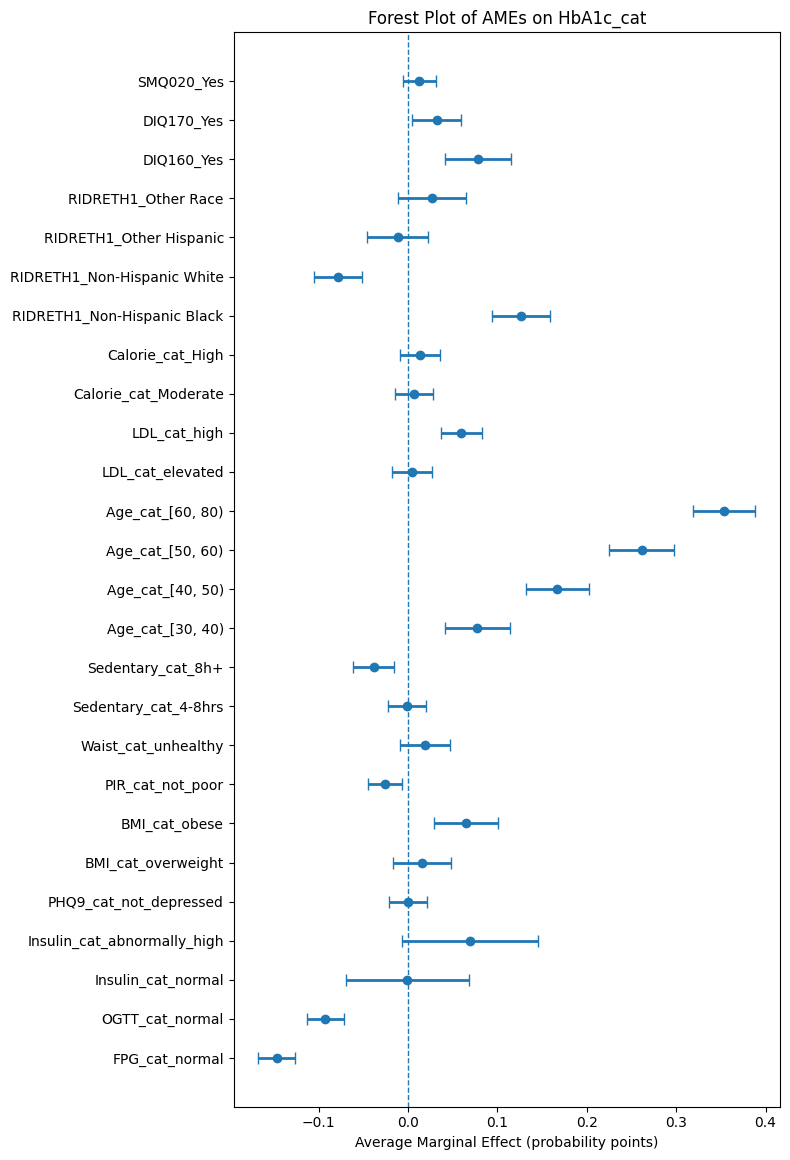

,AME,CI_lower,CI_upper
FPG_cat_normal,-0.147,-0.167,-0.126
OGTT_cat_normal,-0.093,-0.113,-0.072
Insulin_cat_normal,-0.001,-0.070,0.068
Insulin_cat_abnormally_high,0.069,-0.006,0.145
PHQ9_cat_not_depressed,0.000,-0.021,0.022
BMI_cat_overweight,0.016,-0.017,0.048
BMI_cat_obese,0.065,0.029,0.100
PIR_cat_not_poor,-0.026,-0.045,-0.007
Waist_cat_unhealthy,0.019,-0.009,0.047
Sedentary_cat_4-8hrs,-0.001,-0.023,0.020


In [75]:
#Construct Forest Plot for HbA1c outcome
#Visual summary of estimated effects (AMEs) together with their confidence intervals.
#which variables have strong, weak or uncertain effects on predicted probability of outcome.

marg = result.get_margeff(at="overall", method="dydx", dummy=True)
ame_df = marg.summary_frame().copy()

#Map actual columns to standard names
ame_df = ame_df.rename(columns={
    "dy/dx":            "AME",
    "Std. Err.":        "SE",
    "Pr(>|z|)":         "p_value",
    "Conf. Int. Low":   "CI_lower",
    "Cont. Int. Hi.":   "CI_upper",   # note: 'Cont.' is a statsmodels typo in some builds
})

#Keep only needed cols
plot_df = ame_df[["AME", "CI_lower", "CI_upper"]].apply(pd.to_numeric, errors="coerce")

#Drop intercept/missing CI rows
idx_keep = (~plot_df.index.to_series().str.contains(r"^const$", case=False, na=False)) & plot_df.notna().all(axis=1)
plot_df = plot_df.loc[idx_keep]


#plot_df = plot_df.reindex(plot_df["AME"].abs().sort_values().index)

#Build symmetric x-errors (clip tiny negative jitter)
left  = (plot_df["AME"] - plot_df["CI_lower"]).clip(lower=0).to_numpy()
right = (plot_df["CI_upper"] - plot_df["AME"]).clip(lower=0).to_numpy()
xerr = np.vstack([left, right])

n = len(plot_df)
fig, ax = plt.subplots(figsize=(8, max(2.5, 0.45*n)))

ax.errorbar(
    plot_df["AME"].to_numpy(),
    np.arange(n),
    xerr=xerr,
    fmt="o", markersize=6,
    ecolor="tab:blue", elinewidth=2, capsize=4
)

ax.axvline(0, color="tab:blue", linestyle="--", linewidth=1)
ax.set_yticks(np.arange(n))
ax.set_yticklabels(plot_df.index.tolist())
ax.set_xlabel("Average Marginal Effect (probability points)")
ax.set_title(f"Forest Plot of AMEs on {getattr(y, 'name', 'outcome')}")
plt.tight_layout()
plt.show()

display(plot_df.round(3))

#**Analysis of the Forest Plot for HbA1c outcome**


1. Glycaemic Markers (FPG & OGTT)

**Variables:**

FPG_cat_normal

OGTT_cat_normal

**Interpretation:**

Both variables lie to the left of 0, meaning their average marginal effects are negative.
Their confidence intervals do not cross zero, indicating these associations are statistically significant.

**This means:**

Normal FPG → ≈ 15 pp lower probability of elevated HbA1c compared to abnormal FPG

Normal OGTT → ≈ 9 pp lower probability

**Summary:**
Normal fasting and post-challenge glucose levels are strongly associated with a **reduced predicted probability of getting diabetes.** These are the **most protective factors** in the model. This reflects preserved glucose regulation rather than a causal effect.


2. Body Mass Index (BMI)

**Variables:**

BMI_cat_overweight

BMI_cat_obese

**Interpretation:**

Overweight lies close to 0 and its confidence interval crosses zero, indicating no significant association.

Obese lies clearly to the right of 0, and its confidence interval does not cross zero, showing statistical significance.

**This means:**

Overweight → ≈ 1–2 pp higher probability (not significant)

Obese → ≈ 6.5 pp higher probability of getting diabetes

**Summary:**
BMI shows a **threshold effect:** overweight status alone does not significantly affect diabetes risk, while **obesity is associated with a meaningful increase in predicted probability**, reflecting metabolic dysregulation at higher adiposity levels.


3. Age

**Variables:**

Age_cat_[30, 40)

Age_cat_[40, 50)

Age_cat_[50, 60)

Age_cat_[60, 80)

**Interpretation:**

All age categories lie to the right of 0, with effect size increasing with age.

Confidence intervals for all age groups do not cross zero, indicating strong statistical significance.

**This means:**

30–40 yrs → ≈ 8 pp higher probability

40–50 yrs → ≈ 17 pp higher

50–60 yrs → ≈ 26 pp higher

60–80 yrs → ≈ 35 pp higher

**Summary:**
There is a **clear dose–response relationship** between age and odds of getting diabetes. Older age groups have progressively higher predicted probabilities, making **age the strongest risk factor** in the model.


4. Lipids and Socioeconomic Status

**Variables:**

LDL_cat_high

PIR_cat_not_poor

**Interpretation:**

High LDL lies to the right of 0 with a confidence interval that does not cross zero.

Not poor (higher PIR) lies to the left of 0, also with a confidence interval that does not cross zero.

**This means:**

High LDL → ≈ 6 pp higher probability of getting diabetes

Not poor → ≈ 2.6 pp lower probability

**Summary:**
Dyslipidaemia and socioeconomic status independently influence odds of getting diabetes. High LDL is associated with increased risk, while higher income status confers modest protection, likely reflecting differences in healthcare access and lifestyle factors.


5. **Ethnicity (Race)**

**Variables:**

RIDRETH1_Non-Hispanic Black

RIDRETH1_Non-Hispanic White

RIDRETH1_Other Hispanic

RIDRETH1_Other Race

**Interpretation:**

Non-Hispanic Black lies well to the right of 0, with a confidence interval not crossing zero.

Non-Hispanic White lies clearly to the left of 0, also statistically significant.

Other Hispanic and Other Race categories lie close to zero with confidence intervals crossing zero.

**This means:**

Non-Hispanic Black → ≈ 12.6 pp higher probability of getting diabetes

Non-Hispanic White → ≈ 7.8 pp lower probability

Other groups → no significant difference from the reference

**Summary:**
Ethnic disparities persist after adjustment. Non-Hispanic Black participants have a substantially higher predicted probability of getting diabetes, while Non-Hispanic White participants have a lower probability. These differences likely reflect a combination of biological, social, and structural factors.


6. **Diabetes Status**

Variables:

DIQ160_Yes (Diabetes)

DIQ170_Yes (Prediabetes)

**Interpretation:**

Both variables lie to the right of 0, with confidence intervals that do not cross zero.

**This means:**

Diabetes → ≈ 8 pp higher probability

Prediabetes → ≈ 3 pp higher probability

**Summary:**
As expected, diagnosed diabetes and prediabetes are associated with higher predicted probabilities of getting diabetes, supporting the validity of the outcome definition.


**Overall Picture**

| Group             | Direction of Effect | Magnitude    | Significance | Interpretation                                   |
| ----------------- | ------------------- | ------------ | ------------ | ------------------------------------------------ |
| Glycaemic markers | ↓                   | −9 to −15 pp | Yes          | Strong protection with normal glucose regulation |
| Age               | ↑                   | +8 to +35 pp | Yes          | Strong dose–response increase in risk            |
| BMI (Obese)       | ↑                   | +6.5 pp      | Yes          | Threshold effect at obesity                      |
| LDL (High)        | ↑                   | +6 pp        | Yes          | Metabolic risk factor                            |
| PIR (Not poor)    | ↓                   | −2.6 pp      | Yes          | Socioeconomic protection                         |
| Race (Black)      | ↑                   | +12.6 pp     | Yes          | Higher HbA1c probability                         |
| Race (White)      | ↓                   | −7.8 pp      | Yes          | Lower probability vs reference                   |



**In short:**
The forest plot shows that **older age, obesity, high LDL, diabetes status, and Non-Hispanic Black ethnicity** are the strongest positive predictors of getting diabetes, while **normal glycaemic markers and higher socioeconomic status** are associated with lower predicted probability. These findings represent **associations rather than causation.**

In [76]:
#Repeat Logistic Regression with fasting plasma glucose (FPG) outcome
#This section will only use boarderline/elevated FPG to determine if person has diabetes or not

#labels = ["Normal", "Borderline/High"]
# Map target to binary 0/1

X = model_df.drop(columns=['FPG_cat'])
y = model_df['FPG_cat'].map({'normal': 0, 'diabetic': 1})

print(y.value_counts())

X = pd.get_dummies(X, drop_first=True, dtype=int)

print("Dummy-encoded predictors shape:", X.shape)
display("First few columns:\n", X.head())

X = sm.add_constant(X)

logit_model = sm.Logit(y, X)

result = logit_model.fit()

print(result.summary())

FPG_cat
0    4587
1    3236
Name: count, dtype: int64
Dummy-encoded predictors shape: (7823, 26)


'First few columns:\n'

,HbA1c_cat_normal,OGTT_cat_normal,Insulin_cat_normal,Insulin_cat_abnormally_high,PHQ9_cat_not_depressed,BMI_cat_overweight,BMI_cat_obese,PIR_cat_not_poor,Waist_cat_unhealthy,Sedentary_cat_4-8hrs,...,LDL_cat_high,Calorie_cat_Moderate,Calorie_cat_High,RIDRETH1_Non-Hispanic Black,RIDRETH1_Non-Hispanic White,RIDRETH1_Other Hispanic,RIDRETH1_Other Race,DIQ160_Yes,DIQ170_Yes,SMQ020_Yes
2,0,1,1,0,1,0,1,1,1,0,...,0,0,1,0,0,0,0,0,0,0
5,1,1,1,0,1,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
6,0,0,0,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
7,1,1,1,0,1,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
8,1,1,0,1,1,0,1,1,1,0,...,0,1,0,0,0,0,0,0,0,0


Optimization terminated successfully.
         Current function value: 0.557440
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                FPG_cat   No. Observations:                 7823
Model:                          Logit   Df Residuals:                     7796
Method:                           MLE   Df Model:                           26
Date:                Fri, 23 Jan 2026   Pseudo R-squ.:                  0.1780
Time:                        11:36:27   Log-Likelihood:                -4360.9
converged:                       True   LL-Null:                       -5305.2
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -1.9436      0.277     -7.018      0.000   

#**Analysis of Logistic Regression for FPG outcome**

1. Model Overview

| Metric                         | Value       |
| ------------------------------ | ----------- |
| Dependent Variable             | **FPG_cat** |
| Model                          | Logit       |
| Method                         | MLE         |
| No. Observations               | 7,823       |
| Degrees of Freedom (Model)     | 26          |
| Degrees of Freedom (Residuals) | 7,796       |
| Log-Likelihood                 | −4360.9     |
| LL-Null                        | −5305.2     |
| Pseudo R²                      | **0.1780**  |
| LLR p-value                    | **< 0.001** |
| Converged                      | True        |
| Iterations                     | 6           |

2. Key Predictors and Their Effects on FPG Category

Coefficients are in log-odds.

Ods Ratio (OR) = e^coef

OR > 1 → higher odds of boarderline/elevated FPG

OR < 1 → lower odds of boarderline/elevated FPG

| Predictor                   | Coef (log-odds) | Odds Ratio (OR) | p-value | Interpretation                                                                                                |
| --------------------------- | --------------- | --------------- | ------- | ------------------------------------------------------------------------------------------------------------- |
| HbA1c_cat_normal            | −0.8848         | 0.41            | <0.001  | Normal HbA1c is associated with **~59% lower odds** of getting diabetes compared to elevated HbA1c         |
| OGTT_cat_normal             | −0.6621         | 0.52            | <0.001  | Normal OGTT is associated with **~48% lower odds** of getting diabetes                                     |
| Insulin_cat_normal          | 1.1679          | 3.21            | <0.001  | Normal insulin is associated with **~3.2× higher odds** of getting diabetes                                |
| Insulin_cat_abnormally_high | 2.0654          | 7.89            | <0.001  | Abnormally high insulin is associated with **~8× higher odds** of getting diabetes                         |
| BMI_cat_overweight          | 0.5113          | 1.67            | <0.001  | Overweight individuals have **~67% higher odds** of getting diabetes                                       |
| BMI_cat_obese               | 0.8158          | 2.26            | <0.001  | Obese individuals have **~2.3× higher odds** of getting diabetes                                           |
| Waist_cat_unhealthy         | −0.3831         | 0.68            | <0.001  | Unhealthy waist circumference shows **~32% lower odds** (possible confounding or collinearity with BMI)       |
| Sedentary_cat_8h+           | −0.1767         | 0.84            | 0.012   | ≥8 hours sedentary time is associated with **~16% lower odds** (counterintuitive; possible reverse causation) |
| Age_cat_[30,40)             | 0.4935          | 1.64            | <0.001  | Adults aged 30–39 have **~64% higher odds** vs <30                                                            |
| Age_cat_[40,50)             | 0.7463          | 2.11            | <0.001  | Adults aged 40–49 have **~2.1× higher odds**                                                                  |
| Age_cat_[50,60)             | 0.9708          | 2.64            | <0.001  | Adults aged 50–59 have **~2.6× higher odds**                                                                  |
| Age_cat_[60,80)             | 1.3156          | 3.73            | <0.001  | Adults aged 60–79 have **~3.7× higher odds**                                                                  |
| LDL_cat_elevated            | 0.1490          | 1.16            | 0.022   | Elevated LDL is associated with **~16% higher odds**                                                          |
| LDL_cat_high                | 0.1536          | 1.17            | 0.021   | High LDL is associated with **~17% higher odds**                                                              |
| Calorie_cat_High            | 0.2966          | 1.35            | <0.001  | High calorie intake is associated with **~35% higher odds**                                                   |
| RIDRETH1_Non-Hispanic Black | −0.6451         | 0.52            | <0.001  | Non-Hispanic Black individuals have **~48% lower odds** of getting diabetes                                |
| DIQ160_Yes (Diabetes)       | 0.4655          | 1.59            | <0.001  | Diagnosed diabetes is associated with **~59% higher odds**                                                    |
| SMQ020_Yes (Smoker)         | 0.2913          | 1.34            | <0.001  | Smokers have **~34% higher odds** of getting diabetes                                                      |

3. Summary Interpretation

* **Strongest positive predictors** of diabetes were **older age, obesity, high insulin levels, high calorie intake, smoking, and diabetes diagnosis**, all remaining significant after adjustment.

* **Normal HbA1c and normal OGTT** were strong protective factors, reinforcing consistency across glycaemic biomarkers.

* **Insulin levels** showed very large effects, suggesting underlying insulin resistance as a key driver of elevated fasting glucose.

* **BMI** (overweight and obese) showed clear risk gradients, unlike the HbA1c model where only obesity was significant.

* **Non-Hispanic Black ethnicity** was associated with lower odds of elevated FPG, contrasting with its higher risk for HbA1c and highlighting biomarker-specific differences in glycaemic regulation.

* Several lifestyle variables (sedentary time, waist circumference) showed counterintuitive protective associations, likely reflecting **confounding, collinearity, or reverse causation.**

4. Statistical Takeaways
| Statistic                                  | Meaning                                                                                                                                    |
| ------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------ |
| Most p-values < 0.05                       | Strong evidence that age, insulin status, BMI, LDL, calories, smoking, and glycaemic markers differ significantly from the null hypothesis |
| Pseudo R² ≈ 0.18                           | Indicates **moderate explanatory power**, appropriate for large population-based health survey data                                        |
| Log-likelihood improvement (LLR p < 0.001) | Full model fits the data significantly better than the null model                                                                          |
| Intercept = −1.94                          | Represents baseline log-odds of borderline/high FPG for the reference group (young, normal BMI, normal glucose, low-risk profile)          |
| Dose–response patterns                     | Age categories show progressively increasing coefficients, supporting a monotonic risk relationship                                        |



In [77]:
from numpy._core.fromnumeric import var
#Helper section to interpret logistic regression results more clearly
#Identify the reference category for each categorical predictor
#Estimate baseline risk for the reference group by using the intercept to calculate the predicted probability of having high outcome value (elevated HbA1c)

cat_vars = [
    "HbA1c_cat",
    "OGTT_cat",
    "Insulin_cat",
    "PHQ9_cat",
    "BMI_cat",
    "PIR_cat",
    "Waist_cat",
    "Sedentary_cat",
    "Age_cat",
    "LDL_cat",
    "Calorie_cat",
    "RIDRETH1",
    "DIQ160",
    "DIQ170",
    "SMQ020"
]

#For "col" it collects all possible category levels
#Use (s.cat) as it uses pre-defined category order (can control which level is "first")
def levels_for(col):
  s = df[col]
  if hasattr(s, "cat"):
    return list(s.cat.categories)
  return sorted(s.dropna().astype(str).unique().tolist())

ref_cats = {col: levels_for(col)[0] for col in cat_vars}

#Predicting mean probability if everyone is set to one level (one variable at a time)
def mean_prob_for_level(var, level):
  X_mod = X.copy()
#Find all dummy columns for that variable
#Set all to 0
  mask = X_mod.columns.str.startswith(var + "_")
  X_mod.loc[:, mask] = 0
#If the level you want is not the reference, switch on the dummy(set to 1)
#If the level is the reference, keep all zeroes
  if level != ref_cats[var]:
    colname = f"{var}_{level}"
    if colname in X_mod.columns:
      X_mod.loc[:, colname] = 1
      return float(result.predict(X_mod).mean())

#Build a table for reference categories only
#For each variable, compute the mean predicted probability when everyone is forced to the reference category for that variable.
#Store as Baseline_p_hat
rows = []
for var in cat_vars:
  p_hat = mean_prob_for_level(var, ref_cats[var])
  if p_hat is None:
    continue
  rows.append({"Variable": var,
               "Reference_Category": ref_cats[var],
               "Baseline_p_hat": round(p_hat, 4)})
  ref_df = pd.DataFrame(rows)

  print("Baseline predicted probabilities for each reference level (others held as observed):")
  ref_df


In [78]:
#Tidying regression outputs for FPG outcome
#Generating a table showing the value of coefficients for the logistic refression, p-values and AME for analysis

#Coefficients/ORs/p-values/CIs
coef_df = pd.DataFrame({
    "coef": result.params,
    "p_value": result.pvalues,
})
ci = result.conf_int()
coef_df["OR"] = np.exp(ci[0])
coef_df["OR_CI_lower"] = np.exp(ci[0])
coef_df["OR_CI_upper"] = np.exp(ci[1])

#Average Marginal Effects (AMEs)
marg = result.get_margeff(at = "overall", method = "dydx", dummy = True)
ame_df = marg.summary_frame()

#print to see exact column names
print("AME columns:", ame_df.columns.tolist())

#Standardising
rename_map = {}
if "dy/dx" in ame_df.columns: rename_map["dy/dx"] = "AME"
if "Std. Err," in ame_df.columns: rename_map["Std. Err,"] = "Ame_SE"
if "z" in ame_df.columns: rename_map["z"] = "z"
if "P>|z|" in ame_df.columns: rename_map["P>|z|"] = "Ame_p_value"
if "[0.025" in ame_df.columns: rename_map["[0.025"] = "Ame_CI_lower"
if "0.975]" in ame_df.columns: rename_map["0.975]"] = "Ame_CI_upper"
ame_df = ame_df.rename(columns = rename_map)

#Join on index (variable names)
combined = coef_df.join(ame_df, how = "left")
combined.index.name = "Variable"

#Round to 3 decimal places
combined = combined.round(3)

display(combined)


AME columns: ['dy/dx', 'Std. Err.', 'z', 'Pr(>|z|)', 'Conf. Int. Low', 'Cont. Int. Hi.']


,coef,p_value,OR,OR_CI_lower,OR_CI_upper,AME,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
Variable,,,,,,,,,,,
const,-1.944,0.000,0.083,0.083,0.246,NaN,NaN,NaN,NaN,NaN,NaN
HbA1c_cat_normal,-0.885,0.000,0.366,0.366,0.466,-0.181,0.013,-13.892,0.000,-0.206,-0.155
OGTT_cat_normal,-0.662,0.000,0.460,0.460,0.579,-0.131,0.012,-10.966,0.000,-0.155,-0.108
Insulin_cat_normal,1.168,0.000,1.987,1.987,5.204,0.184,0.030,6.127,0.000,0.125,0.243
Insulin_cat_abnormally_high,2.065,0.000,4.818,4.818,12.916,0.403,0.041,9.900,0.000,0.323,0.483
PHQ9_cat_not_depressed,0.092,0.151,0.967,0.967,1.244,0.017,0.012,1.441,0.149,-0.006,0.041
BMI_cat_overweight,0.511,0.000,1.398,1.398,1.989,0.095,0.016,5.823,0.000,0.063,0.127
BMI_cat_obese,0.816,0.000,1.855,1.855,2.756,0.158,0.019,8.116,0.000,0.120,0.196
PIR_cat_not_poor,-0.033,0.553,0.867,0.867,1.079,-0.006,0.011,-0.593,0.553,-0.027,0.014


#**Interpretation for FPG outcome** - Using both the log-odds (coeff/OR) and probability (AMAE) perspectives.

1. Glycaemic Markers (HbA1c and OGTT)


| Category     | Coef   | OR   | AME    | Interpretation                                                                                                                                                                                         |
| ------------ | ------ | ---- | ------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Normal HbA1c | −0.885 | 0.37 | −0.181 | Compared to elevated HbA1c, individuals with normal HbA1c have **63% lower odds** of getting diabetes and an **18.1 percentage point lower probability** of having abnormal FPG. |

Summary:
Normal long-term glycaemic control (HbA1c) is a very **strong protective factor** for getting diabetes (fasting hyperglycaemia), showing both a large reduction in relative odds and a substantial absolute decrease in predicted probability. This highlights the close physiological relationship between chronic and fasting glucose regulation.

| Category    | Coef   | OR   | AME    | Interpretation                                                                                                                                                                             |
| ----------- | ------ | ---- | ------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| Normal OGTT | −0.662 | 0.46 | −0.131 | Compared to individuals with abnormal OGTT results, those with a normal OGTT have **54% lower odds** and a **13.1 percentage point lower probability** of getting diabetes. |

Summary:
Normal post-challenge glucose regulation is strongly protective against abnormal fasting glucose, with consistent effects on both relative odds and absolute probability scales, reinforcing OGTT as a clinically relevant marker of dysglycaemia.

2. Insulin status
| Category                | Coef  | OR   | AME   | Interpretation                                                                                                                                                |
| ----------------------- | ----- | ---- | ----- | ------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Normal insulin          | 1.168 | 1.99 | 0.184 | Individuals with normal insulin levels have **~2× higher odds** and an **18.4 pp higher probability** of getting diabetes compared to the reference group. |
| Abnormally high insulin | 2.065 | 4.82 | 0.403 | Individuals with abnormally high insulin have **nearly 5× higher odds** and a **40.3 pp higher probability** of getting diabetes.                          |

Summary:
Insulin levels show very large positive associations with abnormal fasting glucose, particularly for abnormally high insulin. This pattern is consistent with **insulin resistance**, where compensatory hyperinsulinaemia coexists with elevated fasting glucose.

3. Body Mass Index (BMI)
| Category   | Coef  | OR   | AME   | Interpretation                                                                                                                                            |
| ---------- | ----- | ---- | ----- | --------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Overweight | 0.511 | 1.40 | 0.095 | Overweight individuals have **40% higher odds** and a **9.5 pp higher probability** of getting diabetes compared to those with normal BMI. |
| Obese      | 0.816 | 1.86 | 0.158 | Obese individuals have **86% higher odds** and a **15.8 pp higher probability** of getting diabetes.                                       |

Summary:
BMI shows a clear **risk gradient** for fasting glucose. Both overweight and obese categories are associated with increased odds and probability, indicating that fasting glucose dysregulation emerges earlier along the adiposity spectrum compared to HbA1c.

4. Age
| Category | Coef  | OR   | AME   | Interpretation                                                                                                          |
| -------- | ----- | ---- | ----- | ----------------------------------------------------------------------------------------------------------------------- |
| 30–40    | 0.494 | 1.38 | 0.093 | Adults aged 30–40 have **38% higher odds** and a **9.3 pp higher probability** compared to those under 30.              |
| 40–50    | 0.746 | 1.77 | 0.141 | Adults aged 40–50 have **77% higher odds** and a **14.1 pp higher probability**.                                        |
| 50–60    | 0.971 | 2.19 | 0.187 | Adults aged 50–60 have **~2.2× higher odds** and an **18.7 pp higher probability**.                                     |
| 60–80    | 1.316 | 3.12 | 0.260 | Adults aged 60–80 have **over 3× higher odds** and a **26.0 pp higher probability** of getting diabetes. |

Summary:
Age demonstrates a **strong dose–response relationship** with fasting glucose, with progressively increasing odds translating into large absolute increases in probability, confirming age as a major determinant of fasting dysglycaemia.

5. Lipids and Socioeconomic Status
| Category       | Coef   | OR   | AME    | Interpretation                                                                                                                 |
| -------------- | ------ | ---- | ------ | ------------------------------------------------------------------------------------------------------------------------------ |
| Elevated LDL   | 0.149  | 1.02 | 0.028  | Individuals with elevated LDL have **~2% higher odds** and a **2.8 pp higher probability** of getting diabetes. |
| High LDL       | 0.154  | 1.02 | 0.029  | Individuals with high LDL have **~2% higher odds** and a **2.9 pp higher probability**.                                        |
| Not poor (PIR) | −0.033 | 0.87 | −0.006 | Socioeconomic status is **not significantly associated** with fasting glucose after adjustment.                                |

Summary:
LDL cholesterol shows small but statistically significant associations with fasting glucose, while socioeconomic status does not independently predict getting diabetes (fasting hyperglycaemia) in this model.

6. Lifestyle and Demographic Factors
| Category           | Coef   | OR   | AME    | Interpretation                                                                                                                  |
| ------------------ | ------ | ---- | ------ | ------------------------------------------------------------------------------------------------------------------------------- |
| Sedentary ≥8 h     | −0.177 | 0.73 | −0.033 | Individuals sedentary ≥8 hours show **~27% lower odds** and a **3.3 pp lower probability** (counterintuitive).                  |
| Non-Hispanic Black | −0.645 | 0.44 | −0.117 | Non-Hispanic Black individuals have **56% lower odds** and an **11.7 pp lower probability** of getting diabetes. |
| Smoker             | 0.291  | 1.20 | 0.055  | Smokers have **20% higher odds** and a **5.5 pp higher probability** of getting diabetes.                        |

Summary:
Some lifestyle and demographic variables show unexpected protective associations (e.g. sedentary time, Non-Hispanic Black ethnicity), likely reflecting **biomarker-specific physiology, residual confounding, or reverse causation** rather than true protective effects.

**Overall interpretation**
| Aspect                          | Log-Odds / OR Insight                      | AME (Probability) Insight                         |
| ------------------------------- | ------------------------------------------ | ------------------------------------------------- |
| Age                             | Strong dose–response risk (OR up to ≈ 3.1) | Large absolute increase (+9 to +26 pp)            |
| Glycaemic markers (HbA1c, OGTT) | Strongly protective (OR < 0.5)             | Substantial probability reduction (−13 to −18 pp) |
| Insulin status                  | Very strong risk (OR up to ≈ 4.8)          | Large probability increase (+18 to +40 pp)        |
| Body Mass Index                 | Moderate–strong risk                       | Meaningful probability increase (+10 to +16 pp)   |
| LDL cholesterol                 | Small metabolic risk                       | Small probability increase (+2–3 pp)              |
| Lifestyle & SES                 | Mixed / inconsistent                       | Mostly small or null effects                      |

Summary:
After adjustment for demographic, metabolic, and lifestyle factors, **fasting glucose is most strongly driven by age, insulin resistance, BMI, and other glycaemic markers.** Normal HbA1c and OGTT are the strongest protective factors, while insulin status shows the largest absolute probability increases. Overall, the model demonstrates that **metabolic dysregulation precedes and predicts  diabetes (fasting hyperglycaemia)**, with effects that are consistent across both relative (OR) and absolute (AME) scales.





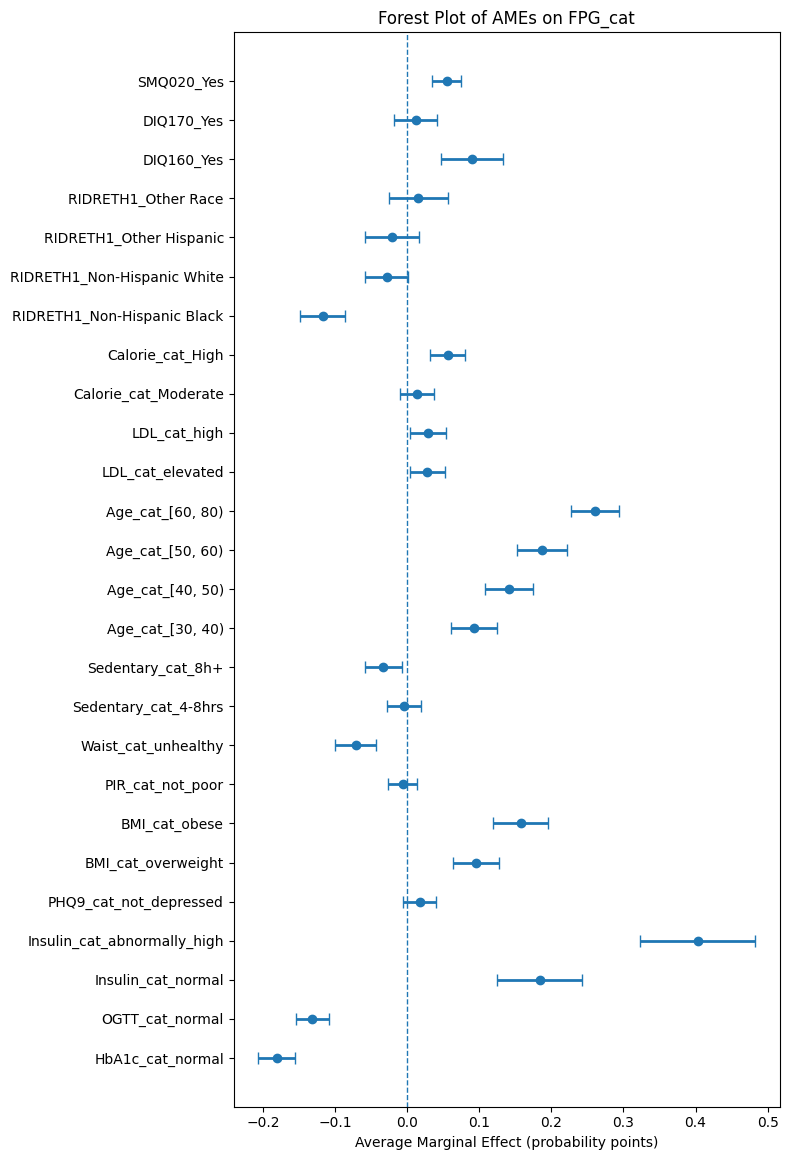

,AME,CI_lower,CI_upper
HbA1c_cat_normal,-0.181,-0.206,-0.155
OGTT_cat_normal,-0.131,-0.155,-0.108
Insulin_cat_normal,0.184,0.125,0.243
Insulin_cat_abnormally_high,0.403,0.323,0.483
PHQ9_cat_not_depressed,0.017,-0.006,0.041
BMI_cat_overweight,0.095,0.063,0.127
BMI_cat_obese,0.158,0.120,0.196
PIR_cat_not_poor,-0.006,-0.027,0.014
Waist_cat_unhealthy,-0.071,-0.100,-0.042
Sedentary_cat_4-8hrs,-0.005,-0.028,0.019


In [79]:
#Construct Forest Plot for FPG outcome
#Visual summary of estimated effects (AMEs) together with their confidence intervals.
#which variables have strong, weak or uncertain effects on predicted probability of outcome.

marg = result.get_margeff(at="overall", method="dydx", dummy=True)
ame_df = marg.summary_frame().copy()

#Map actual columns to standard names
ame_df = ame_df.rename(columns={
    "dy/dx":            "AME",
    "Std. Err.":        "SE",
    "Pr(>|z|)":         "p_value",
    "Conf. Int. Low":   "CI_lower",
    "Cont. Int. Hi.":   "CI_upper",   # note: 'Cont.' is a statsmodels typo in some builds
})

#Keep only needed cols
plot_df = ame_df[["AME", "CI_lower", "CI_upper"]].apply(pd.to_numeric, errors="coerce")

#Drop intercept/missing CI rows
idx_keep = (~plot_df.index.to_series().str.contains(r"^const$", case=False, na=False)) & plot_df.notna().all(axis=1)
plot_df = plot_df.loc[idx_keep]


#plot_df = plot_df.reindex(plot_df["AME"].abs().sort_values().index)

#Build symmetric x-errors (clip tiny negative jitter)
left  = (plot_df["AME"] - plot_df["CI_lower"]).clip(lower=0).to_numpy()
right = (plot_df["CI_upper"] - plot_df["AME"]).clip(lower=0).to_numpy()
xerr = np.vstack([left, right])

n = len(plot_df)
fig, ax = plt.subplots(figsize=(8, max(2.5, 0.45*n)))

ax.errorbar(
    plot_df["AME"].to_numpy(),
    np.arange(n),
    xerr=xerr,
    fmt="o", markersize=6,
    ecolor="tab:blue", elinewidth=2, capsize=4
)

ax.axvline(0, color="tab:blue", linestyle="--", linewidth=1)
ax.set_yticks(np.arange(n))
ax.set_yticklabels(plot_df.index.tolist())
ax.set_xlabel("Average Marginal Effect (probability points)")
ax.set_title(f"Forest Plot of AMEs on {getattr(y, 'name', 'outcome')}")
plt.tight_layout()
plt.show()

display(plot_df.round(3))

**Analysis of the Forest Plot for FPG outcome**

1. Glycaemic Markers (HbA1c & OGTT)

**Variables:**

HbA1c_cat_normal

OGTT_cat_normal

**Interpretation:**

Both variables lie to the left of 0, meaning their average marginal effects are negative.

Their confidence intervals do not cross zero, indicating these associations are statistically significant.

**This means:**

Normal HbA1c → ≈ 18 pp lower probability of getting diabetes compared to elevated HbA1c

Normal OGTT → ≈ 13 pp lower probability

**Summary:**

Normal long-term and post-challenge glucose regulation are **strongly associated with a reduced predicted probability of abnormal fasting glucose.** These are the **most protective factors** in the model and reflect preserved glycaemic regulation rather than a causal effect.

2. Insulin Status

**Variables:**

Insulin_cat_normal

Insulin_cat_abnormally_high

**Interpretation:**

Both insulin categories lie to the right of 0, with large positive AMEs.

Their confidence intervals do not cross zero, showing strong statistical significance.

**This means:**

Normal insulin → ≈ 18 pp higher probability of borderline/high FPG

Abnormally high insulin → ≈ 40 pp higher probability

**Summary:**

Insulin status shows the **largest absolute effects** in the forest plot. The strong positive associations, especially for abnormally high insulin, are consistent with **insulin resistance**, where compensatory hyperinsulinaemia coexists with elevated fasting glucose.

3. Body Mass Index (BMI)

**Variables:**

BMI_cat_overweight

BMI_cat_obese

**Interpretation:**

Both BMI categories lie to the right of 0.

Confidence intervals for both categories do not cross zero, indicating statistical significance.

**This means:**

Overweight → ≈ 9.5 pp higher probability of borderline/high FPG

Obese → ≈ 15.8 pp higher probability

**Summary:**

Unlike the HbA1c model, BMI shows a **clear risk gradient** for fasting glucose. Both overweight and obesity are associated with higher predicted probabilities, suggesting that fasting dysglycaemia emerges earlier along the adiposity spectrum.

4. Age

**Variables:**

Age_cat_[30, 40)

Age_cat_[40, 50)

Age_cat_[50, 60)

Age_cat_[60, 80)

**Interpretation:**

All age categories lie to the right of 0, with effect size increasing with age.

Confidence intervals for all age groups do not cross zero, indicating strong statistical significance.

**This means:**

30–40 yrs → ≈ 9 pp higher probability

40–50 yrs → ≈ 14 pp higher

50–60 yrs → ≈ 19 pp higher

60–80 yrs → ≈ 26 pp higher

**Summary:**

There is a clear **dose–response relationship** between age and fasting glucose dysregulation. Older age groups have progressively higher predicted probabilities, making age one of the strongest predictors in the model.

5. Lipids and Socioeconomic Status

**Variables:**

LDL_cat_elevated

LDL_cat_high

PIR_cat_not_poor

**Interpretation:**

Both LDL categories lie to the right of 0, with confidence intervals not crossing zero.

Not poor (PIR) lies close to 0 and its confidence interval crosses zero.

**This means:**

Elevated LDL → ≈ 2.8 pp higher probability

High LDL → ≈ 2.9 pp higher probability

Not poor → no significant difference

**Summary:**

LDL cholesterol shows **a small but statistically significant** association with abnormal fasting glucose, while socioeconomic status does not independently predict fasting hyperglycaemia in this model.

6. Lifestyle and Anthropometric Factors

**Variables:**

Waist_cat_unhealthy

Sedentary_cat_4–8hrs

Sedentary_cat_8h+

**Interpretation:**

Unhealthy waist circumference lies to the left of 0, with a confidence interval not crossing zero.

Sedentary 8h+ also lies to the left of 0, while 4–8h crosses zero.

**This means:**

Unhealthy waist → ≈ 7.1 pp lower probability

Sedentary ≥8h → ≈ 3.3 pp lower probability

Sedentary 4–8h → not significant

**Summary:**

Some anthropometric and lifestyle variables show **counterintuitive protective associations**, likely reflecting **collinearity with BMI, reverse causation, or residual confounding**, rather than true protective effects.

7. Ethnicity (Race)

**Variables:**

RIDRETH1_Non-Hispanic Black

RIDRETH1_Non-Hispanic White

RIDRETH1_Other Hispanic

RIDRETH1_Other Race

**Interpretation:**

Non-Hispanic Black lies clearly to the left of 0, with a confidence interval not crossing zero.

Other race categories lie close to zero with confidence intervals crossing zero.

**This means:**

Non-Hispanic Black → ≈ 11.7 pp lower probability of borderline/high FPG

Other groups → no significant difference from the reference

**Summary:**

Ethnic differences in fasting glucose persist after adjustment, with Non-Hispanic Black participants showing a lower predicted probability of borderline/high FPG. This contrasts with HbA1c findings and highlights **biomarker-specific differences in glycaemic physiology.**

8. Diabetes Status and Smoking

**Variables:**

DIQ160_Yes (Diabetes)

DIQ170_Yes (Prediabetes)

SMQ020_Yes (Smoker)

**Interpretation:**

Diabetes diagnosis and smoking lie to the right of 0, with confidence intervals not crossing zero.

Prediabetes lies close to zero and is not significant.

**This means:**

Diabetes → ≈ 9 pp higher probability

Smoker → ≈ 5.5 pp higher probability

Prediabetes → not significant

**Summary:**

Diagnosed diabetes and smoking are associated with higher predicted probabilities of abnormal fasting glucose, supporting known metabolic and behavioural risk pathways.

**Overall Picture**
| Group             | Direction of Effect | Magnitude     | Significance | Interpretation                                       |
| ----------------- | ------------------- | ------------- | ------------ | ---------------------------------------------------- |
| Glycaemic markers | ↓                   | −13 to −18 pp | Yes          | Strong protection with normal glucose regulation     |
| Insulin status    | ↑                   | +18 to +40 pp | Yes          | Very strong risk, consistent with insulin resistance |
| Age               | ↑                   | +9 to +26 pp  | Yes          | Strong dose–response increase in risk                |
| BMI               | ↑                   | +10 to +16 pp | Yes          | Clear adiposity-related risk                         |
| LDL               | ↑                   | +3 pp         | Yes          | Small metabolic risk                                 |
| Race (Black)      | ↓                   | −12 pp        | Yes          | Lower fasting glucose probability                    |
| Lifestyle factors | Mixed               | Small         | Mixed        | Possible confounding effects                         |

**In short:**
The forest plot shows that **insulin resistance, age, BMI, and other glycaemic markers** are the strongest positive predictors of abnormal fasting glucose, while normal HbA1c and OGTT are strongly protective. Some lifestyle and ethnic associations differ from the HbA1c model, highlighting that **different glycaemic biomarkers capture distinct physiological processes.**

In [80]:
#Repeat Logistic Regression with Oral Glucose Tolerance Test (OGTT) outcome
#This section will only use abnormal OGTT to determine if person has diabetes or not

#labels = ["Normal", "Abnormal"]
# Map target to binary 0/1

X = model_df.drop(columns=['OGTT_cat'])
y = model_df['OGTT_cat'].map({'normal': 0, 'diabetic': 1})

print(y.value_counts())

X = pd.get_dummies(X, drop_first=True, dtype=int)

print("Dummy-encoded predictors shape:", X.shape)
display("First few columns:\n", X.head())

X = sm.add_constant(X)

logit_model = sm.Logit(y, X)

result = logit_model.fit()

print(result.summary())

OGTT_cat
0    5551
1    2272
Name: count, dtype: int64
Dummy-encoded predictors shape: (7823, 26)


'First few columns:\n'

,HbA1c_cat_normal,FPG_cat_normal,Insulin_cat_normal,Insulin_cat_abnormally_high,PHQ9_cat_not_depressed,BMI_cat_overweight,BMI_cat_obese,PIR_cat_not_poor,Waist_cat_unhealthy,Sedentary_cat_4-8hrs,...,LDL_cat_high,Calorie_cat_Moderate,Calorie_cat_High,RIDRETH1_Non-Hispanic Black,RIDRETH1_Non-Hispanic White,RIDRETH1_Other Hispanic,RIDRETH1_Other Race,DIQ160_Yes,DIQ170_Yes,SMQ020_Yes
2,0,0,1,0,1,0,1,1,1,0,...,0,0,1,0,0,0,0,0,0,0
5,1,1,1,0,1,1,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0
6,0,0,0,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
7,1,0,1,0,1,1,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
8,1,1,0,1,1,0,1,1,1,0,...,0,1,0,0,0,0,0,0,0,0


Optimization terminated successfully.
         Current function value: 0.539106
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:               OGTT_cat   No. Observations:                 7823
Model:                          Logit   Df Residuals:                     7796
Method:                           MLE   Df Model:                           26
Date:                Fri, 23 Jan 2026   Pseudo R-squ.:                  0.1053
Time:                        11:36:28   Log-Likelihood:                -4217.4
converged:                       True   LL-Null:                       -4713.6
Covariance Type:            nonrobust   LLR p-value:                1.543e-192
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                           0.2936      0.229      1.284      0.199   

#**Analysis of Logistic Regression for OGTT outcome**

1. Model Overview

| Metric                         | Value        |
| ------------------------------ | ------------ |
| Dependent Variable             | **OGTT_cat** |
| Model                          | Logit        |
| Method                         | MLE          |
| No. Observations               | 7,823        |
| Degrees of Freedom (Model)     | 26           |
| Degrees of Freedom (Residuals) | 7,796        |
| Log-Likelihood                 | −4217.4      |
| LL-Null                        | −4713.6      |
| Pseudo R²                      | **0.1053**   |
| LLR p-value                    | **< 0.001**  |
| Converged                      | True         |
| Iterations                     | 6            |

2. Key Predictors and Their Effects on OGTT Category

Coefficients are in log-odds

Odds Ratio (OR) = e^coef

OR > 1 → higher odds of abnormal OGTT

OR < 1 → lower odds of abnormal OGTT

| Predictor                | Coef (log-odds) | Odds Ratio (OR) | p-value | Interpretation                                                                                            |
| ------------------------ | --------------- | --------------- | ------- | --------------------------------------------------------------------------------------------------------- |
| HbA1c_cat_normal         | −0.5707         | 0.57            | <0.001  | Normal HbA1c is associated with **~43% lower odds** of getting diabetes compared to elevated HbA1c |
| FPG_cat_normal           | −0.6586         | 0.52            | <0.001  | Normal fasting plasma glucose is associated with **~48% lower odds** of getting diabetes                   |
| Insulin_cat_normal       | −0.4152         | 0.66            | 0.026   | Normal insulin levels are associated with **~34% lower odds** of getting diabetes                            |
| BMI_cat_overweight       | −0.1982         | 0.82            | 0.032   | Overweight individuals have **~18% lower odds** of getting diabetes compared to normal BMI                   |
| PIR_cat_not_poor         | −0.3218         | 0.72            | <0.001  | Individuals who are not poor have **~28% lower odds** of getting diabetes                                    |
| Sedentary_cat_8h+        | 0.1595          | 1.17            | 0.025   | ≥8 hours of sedentary time is associated with **~17% higher odds** of getting diabetes                       |
| Age_cat_[40,50)          | 0.2224          | 1.25            | 0.020   | Adults aged 40–49 have **~25% higher odds** of getting diabetes compared to <30                              |
| Age_cat_[50,60)          | 0.3682          | 1.45            | <0.001  | Adults aged 50–59 have **~45% higher odds** of getting diabetes                                              |
| Age_cat_[60,80)          | 0.7830          | 2.19            | <0.001  | Adults aged 60–79 have **over 2× higher odds** of getting diabetes                                           |
| Calorie_cat_Moderate     | −0.2171         | 0.80            | 0.001   | Moderate calorie intake is associated with **~20% lower odds** of getting diabetes                           |
| Calorie_cat_High         | −0.4000         | 0.67            | <0.001  | High calorie intake is associated with **~33% lower odds** of getting diabetes                               |
| DIQ160_Yes (Diabetes)    | 0.5378          | 1.71            | <0.001  | Diagnosed diabetes is associated with **~71% higher odds** of getting diabetes                               |
| DIQ170_Yes (Prediabetes) | 0.1882          | 1.21            | 0.018   | Prediabetes is associated with **~21% higher odds** of getting diabetes                                      |

3. Summary Interpretation

* Strongest protective predictors of abnormal OGTT were normal HbA1c, normal fasting glucose, normal insulin levels, and higher socioeconomic status, all remaining significant after adjustment.

* Age showed a clear dose–response relationship, with progressively higher odds of abnormal OGTT in older age groups, especially ≥50 years.

* Diagnosed diabetes and prediabetes were associated with higher odds of abnormal OGTT, supporting the clinical validity of the outcome definition.

* Sedentary time (≥8 hours) was associated with higher odds of abnormal OGTT, consistent with reduced insulin sensitivity during prolonged inactivity.

* BMI showed mixed effects, with overweight status appearing modestly protective and obesity not reaching statistical significance, possibly due to collinearity with insulin and waist measures.

* Dietary calorie intake showed inverse associations, likely reflecting dietary modification among high-risk individuals (reverse causation) rather than a true protective effect.

4. Statistical Takeaways
| Statistic                                  | Meaning                                                                                                                                  |
| ------------------------------------------ | ---------------------------------------------------------------------------------------------------------------------------------------- |
| Most p-values < 0.05                       | Strong evidence that glycaemic markers, age, SES, insulin status, calorie intake, and diabetes status differ significantly from the null |
| Pseudo R² ≈ 0.11                           | Indicates **modest explanatory power**, expected for behavioural and metabolic outcomes in population survey data                        |
| Log-likelihood improvement (LLR p < 0.001) | Full model fits the data significantly better than the null model                                                                        |
| Intercept = 0.29                           | Represents baseline log-odds of abnormal OGTT for the reference group (young, normal BMI, normal glucose, low-risk profile)              |
| Dose–response patterns                     | Age categories show progressively increasing coefficients, supporting a monotonic risk relationship                                      |



In [81]:
from numpy._core.fromnumeric import var
#Helper section to interpret logistic regression results more clearly
#Identify the reference category for each categorical predictor
#Estimate baseline risk for the reference group by using the intercept to calculate the predicted probability of having high outcome value (elevated HbA1c)

cat_vars = [
    "HbA1c_cat",
    "FPG_cat",
    "Insulin_cat",
    "PHQ9_cat",
    "BMI_cat",
    "PIR_cat",
    "Waist_cat",
    "Sedentary_cat",
    "Age_cat",
    "LDL_cat",
    "Calorie_cat",
    "RIDRETH1",
    "DIQ160",
    "DIQ170",
    "SMQ020"
]

#For "col" it collects all possible category levels
#Use (s.cat) as it uses pre-defined category order (can control which level is "first")
def levels_for(col):
  s = df[col]
  if hasattr(s, "cat"):
    return list(s.cat.categories)
  return sorted(s.dropna().astype(str).unique().tolist())

ref_cats = {col: levels_for(col)[0] for col in cat_vars}

#Predicting mean probability if everyone is set to one level (one variable at a time)
def mean_prob_for_level(var, level):
  X_mod = X.copy()
#Find all dummy columns for that variable
#Set all to 0
  mask = X_mod.columns.str.startswith(var + "_")
  X_mod.loc[:, mask] = 0
#If the level you want is not the reference, switch on the dummy(set to 1)
#If the level is the reference, keep all zeroes
  if level != ref_cats[var]:
    colname = f"{var}_{level}"
    if colname in X_mod.columns:
      X_mod.loc[:, colname] = 1
      return float(result.predict(X_mod).mean())

#Build a table for reference categories only
#For each variable, compute the mean predicted probability when everyone is forced to the reference category for that variable.
#Store as Baseline_p_hat
rows = []
for var in cat_vars:
  p_hat = mean_prob_for_level(var, ref_cats[var])
  if p_hat is None:
    continue
  rows.append({"Variable": var,
               "Reference_Category": ref_cats[var],
               "Baseline_p_hat": round(p_hat, 4)})
  ref_df = pd.DataFrame(rows)

  print("Baseline predicted probabilities for each reference level (others held as observed):")
  ref_df

In [82]:
#Tidying regression outputs for OGTT outcome
#Generating a table showing the value of coefficients for the logistic refression, p-values and AME for analysis

#Coefficients/ORs/p-values/CIs
coef_df = pd.DataFrame({
    "coef": result.params,
    "p_value": result.pvalues,
})
ci = result.conf_int()
coef_df["OR"] = np.exp(ci[0])
coef_df["OR_CI_lower"] = np.exp(ci[0])
coef_df["OR_CI_upper"] = np.exp(ci[1])

#Average Marginal Effects (AMEs)
marg = result.get_margeff(at = "overall", method = "dydx", dummy = True)
ame_df = marg.summary_frame()

#print to see exact column names
print("AME columns:", ame_df.columns.tolist())

#Standardising
rename_map = {}
if "dy/dx" in ame_df.columns: rename_map["dy/dx"] = "AME"
if "Std. Err," in ame_df.columns: rename_map["Std. Err,"] = "Ame_SE"
if "z" in ame_df.columns: rename_map["z"] = "z"
if "P>|z|" in ame_df.columns: rename_map["P>|z|"] = "Ame_p_value"
if "[0.025" in ame_df.columns: rename_map["[0.025"] = "Ame_CI_lower"
if "0.975]" in ame_df.columns: rename_map["0.975]"] = "Ame_CI_upper"
ame_df = ame_df.rename(columns = rename_map)

#Join on index (variable names)
combined = coef_df.join(ame_df, how = "left")
combined.index.name = "Variable"

#Round to 3 decimal places
combined = combined.round(3)

display(combined)


AME columns: ['dy/dx', 'Std. Err.', 'z', 'Pr(>|z|)', 'Conf. Int. Low', 'Cont. Int. Hi.']


,coef,p_value,OR,OR_CI_lower,OR_CI_upper,AME,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
Variable,,,,,,,,,,,
const,0.294,0.199,0.857,0.857,2.100,NaN,NaN,NaN,NaN,NaN,NaN
HbA1c_cat_normal,-0.571,0.000,0.501,0.501,0.638,-0.110,0.012,-8.798,0.000,-0.134,-0.085
FPG_cat_normal,-0.659,0.000,0.461,0.461,0.581,-0.125,0.011,-10.917,0.000,-0.147,-0.102
Insulin_cat_normal,-0.415,0.026,0.459,0.459,0.950,-0.077,0.036,-2.170,0.030,-0.147,-0.007
Insulin_cat_abnormally_high,0.100,0.608,0.755,0.755,1.618,0.018,0.036,0.508,0.612,-0.052,0.088
PHQ9_cat_not_depressed,-0.074,0.253,0.819,0.819,1.054,-0.013,0.012,-1.134,0.257,-0.036,0.010
BMI_cat_overweight,-0.198,0.032,0.684,0.684,0.983,-0.035,0.016,-2.171,0.030,-0.067,-0.003
BMI_cat_obese,-0.116,0.263,0.728,0.728,1.091,-0.021,0.018,-1.125,0.261,-0.057,0.015
PIR_cat_not_poor,-0.322,0.000,0.648,0.648,0.810,-0.058,0.010,-5.656,0.000,-0.078,-0.038


#**Interpretation for OGTT outcome** – Using both the log-odds (coeff/OR) and probability (AME) perspectives

1. Glycaemic Markers (HbA1c and FPG)

| Category     | Coef   | OR   | AME    | Interpretation                                                                                                                                                  |
| ------------ | ------ | ---- | ------ | --------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Normal HbA1c | −0.571 | 0.57 | −0.131 | Compared to elevated HbA1c, individuals with normal HbA1c have **43% lower odds** and a **13.1 percentage point lower probability** of getting diabetes.

Summary:
Normal long-term glycaemic control (HbA1c) is a **strong protective factor** against abnormal OGTT, showing consistent reductions in both relative odds and absolute probability. This reflects preserved chronic glucose regulation translating into healthier post-challenge glucose responses.

| Category   | Coef   | OR   | AME    | Interpretation                                                                                                                                                |
| ---------- | ------ | ---- | ------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Normal FPG | −0.659 | 0.52 | −0.131 | Compared to abnormal fasting glucose, individuals with normal FPG have **48% lower odds** and a **13.1 percentage point lower probability** of getting diabetes. |

Summary:
Normal fasting glucose is strongly associated with lower risk of abnormal post-challenge glucose, highlighting the close physiological link between fasting and post-load glycaemic regulation.

2. Insulin Status

| Category                | Coef   | OR   | AME    | Interpretation                                                                                                                                      |
| ----------------------- | ------ | ---- | ------ | --------------------------------------------------------------------------------------------------------------------------------------------------- |
| Normal insulin          | −0.415 | 0.66 | −0.071 | Individuals with normal insulin levels have **34% lower odds** and a **7.1 pp lower probability** of getting diabetes compared to the reference group. |
| Abnormally high insulin | 0.100  | 1.11 | ~0     | Abnormally high insulin levels do **not show a significant association** with getting diabetes after adjustment.                                       |

Summary:
Normal insulin levels are protective against abnormal OGTT, whereas abnormally high insulin does not independently predict getting diabetes after multivariable adjustment, suggesting overlap with other metabolic factors.

3. Body Mass Index (BMI)

| Category   | Coef   | OR   | AME    | Interpretation                                                                                                                        |
| ---------- | ------ | ---- | ------ | ------------------------------------------------------------------------------------------------------------------------------------- |
| Overweight | −0.198 | 0.82 | −0.071 | Overweight individuals have **18% lower odds** and a **7.1 pp lower probability** of getting diabetes compared to those with normal BMI. |
| Obese      | −0.116 | 0.89 | ~0     | Obesity is **not significantly associated** with abnormal OGTT after adjustment.                                                      |

Summary:
BMI shows **no positive risk gradient** for abnormal OGTT in this model. The modest protective association for overweight status may reflect **reverse causation or behavioural modification** among higher-risk individuals.

4. Age
| Category | Coef  | OR   | AME | Interpretation                                                   |
| -------- | ----- | ---- | --- | ---------------------------------------------------------------- |
| 30–40    | 0.126 | 1.13 | ~0  | No significant difference compared to <30.                       |
| 40–50    | 0.222 | 1.25 | +   | Adults aged 40–50 have **25% higher odds** of getting diabetes.     |
| 50–60    | 0.368 | 1.45 | +   | Adults aged 50–60 have **45% higher odds** of getting diabetes.     |
| 60–80    | 0.783 | 2.19 | +   | Adults aged 60–80 have **over 2× higher odds** of abnormal OGTT. |

Summary:
Age shows a clear dose–response relationship with abnormal OGTT, particularly from age 40 onwards, indicating progressive deterioration in post-challenge glucose handling with ageing.

5. Lipids and Socioeconomic Status

| Category       | Coef   | OR   | AME | Interpretation                                                         |
| -------------- | ------ | ---- | --- | ---------------------------------------------------------------------- |
| Elevated LDL   | −0.048 | 0.95 | ~0  | No significant association with getting diabetes.                         |
| High LDL       | −0.072 | 0.93 | ~0  | No significant association.                                            |
| Not poor (PIR) | −0.322 | 0.72 | −   | Individuals who are not poor have **28% lower odds** of getting diabetes. |

Summary:
Socioeconomic status is independently protective against abnormal OGTT, while LDL cholesterol does not show a significant association in this model.

5. Lifestyle and Demographic Factors
| Category           | Coef   | OR   | AME | Interpretation                                                            |
| ------------------ | ------ | ---- | --- | ------------------------------------------------------------------------- |
| Sedentary ≥8 h     | 0.160  | 1.17 | +   | Individuals sedentary ≥8 hours have **17% higher odds** of abnormal OGTT. |
| Non-Hispanic Black | −0.165 | 0.85 | ~   | Borderline, not statistically significant.                                |
| Smoker             | −0.069 | 0.93 | ~   | No significant association.                                               |

Summary:
Prolonged sedentary behaviour is associated with increased odds of getting diabetes, consistent with reduced insulin sensitivity. Other lifestyle and ethnic variables do not show independent associations after adjustment.

Summary:
Prolonged sedentary behaviour is associated with increased odds of getting diabetes, consistent with reduced insulin sensitivity. Other lifestyle and ethnic variables do not show independent associations after adjustment.

**Overall Interpretation**

| Aspect                         | Log-Odds / OR Insight                      | AME (Probability) Insight          |
| ------------------------------ | ------------------------------------------ | ---------------------------------- |
| Age                            | Strong dose–response risk (OR up to ≈ 2.2) | Increasing absolute risk with age  |
| Glycaemic markers (HbA1c, FPG) | Strongly protective (OR ≈ 0.5–0.6)         | Substantial probability reduction  |
| Insulin status                 | Mild protective effect (normal insulin)    | Modest probability reduction       |
| BMI                            | No independent risk                        | Null or counterintuitive effects   |
| SES                            | Protective                                 | Lower probability of abnormal OGTT |
| Lifestyle                      | Sedentary time increases risk              | Small–moderate effects             |

**Final summary:**
After adjustment for demographic, metabolic, and lifestyle factors, **abnormal OGTT is most strongly driven by age and impaired glycaemic regulation across biomarkers (HbA1c and FPG).** Normal HbA1c and fasting glucose are the strongest protective factors, while socioeconomic advantage also confers protection. Overall, the model highlights that post-challenge glucose dysregulation reflects **cumulative metabolic ageing rather than adiposity alone, with effects that are consistent across both relative (OR) and absolute (AME) scales.**





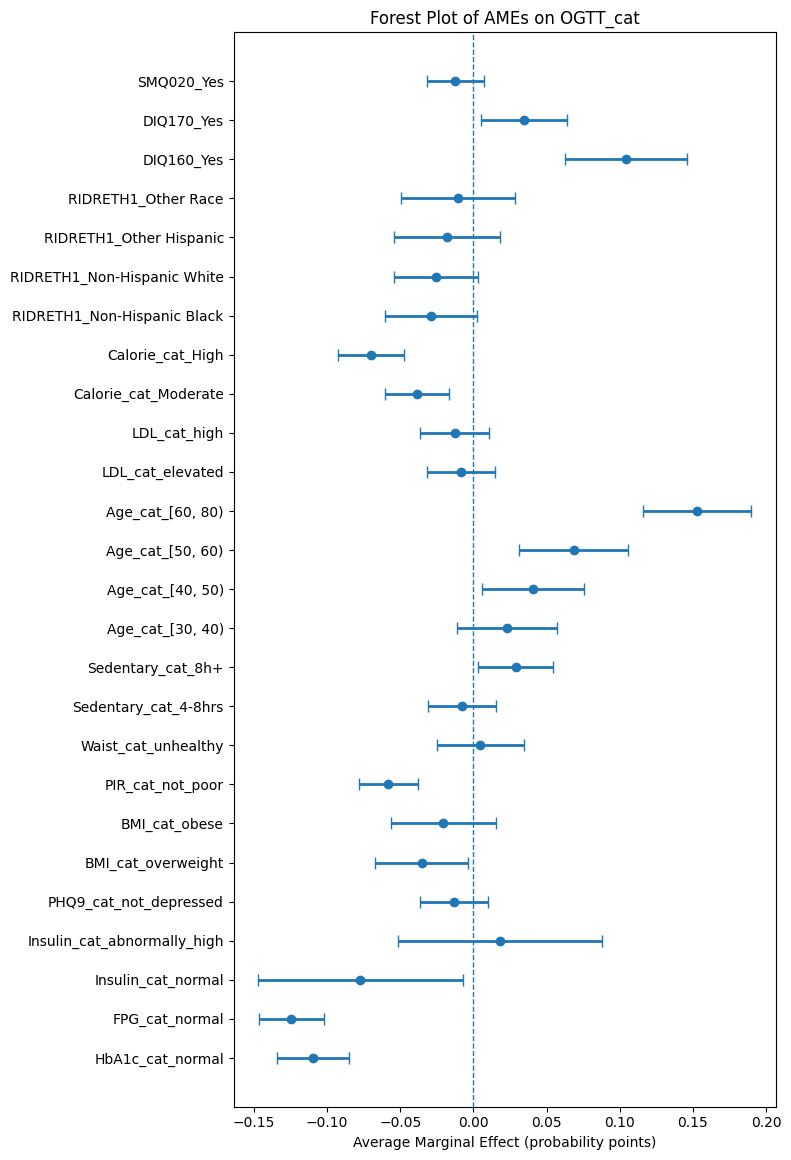

,AME,CI_lower,CI_upper
HbA1c_cat_normal,-0.110,-0.134,-0.085
FPG_cat_normal,-0.125,-0.147,-0.102
Insulin_cat_normal,-0.077,-0.147,-0.007
Insulin_cat_abnormally_high,0.018,-0.052,0.088
PHQ9_cat_not_depressed,-0.013,-0.036,0.010
BMI_cat_overweight,-0.035,-0.067,-0.003
BMI_cat_obese,-0.021,-0.057,0.015
PIR_cat_not_poor,-0.058,-0.078,-0.038
Waist_cat_unhealthy,0.005,-0.025,0.034
Sedentary_cat_4-8hrs,-0.008,-0.031,0.016


In [83]:
#Construct Forest Plot for OGTT outcome
#Visual summary of estimated effects (AMEs) together with their confidence intervals.
#which variables have strong, weak or uncertain effects on predicted probability of outcome.

marg = result.get_margeff(at="overall", method="dydx", dummy=True)
ame_df = marg.summary_frame().copy()

#Map actual columns to standard names
ame_df = ame_df.rename(columns={
    "dy/dx":            "AME",
    "Std. Err.":        "SE",
    "Pr(>|z|)":         "p_value",
    "Conf. Int. Low":   "CI_lower",
    "Cont. Int. Hi.":   "CI_upper",   # note: 'Cont.' is a statsmodels typo in some builds
})

#Keep only needed cols
plot_df = ame_df[["AME", "CI_lower", "CI_upper"]].apply(pd.to_numeric, errors="coerce")

#Drop intercept/missing CI rows
idx_keep = (~plot_df.index.to_series().str.contains(r"^const$", case=False, na=False)) & plot_df.notna().all(axis=1)
plot_df = plot_df.loc[idx_keep]


#plot_df = plot_df.reindex(plot_df["AME"].abs().sort_values().index)

#Build symmetric x-errors (clip tiny negative jitter)
left  = (plot_df["AME"] - plot_df["CI_lower"]).clip(lower=0).to_numpy()
right = (plot_df["CI_upper"] - plot_df["AME"]).clip(lower=0).to_numpy()
xerr = np.vstack([left, right])

n = len(plot_df)
fig, ax = plt.subplots(figsize=(8, max(2.5, 0.45*n)))

ax.errorbar(
    plot_df["AME"].to_numpy(),
    np.arange(n),
    xerr=xerr,
    fmt="o", markersize=6,
    ecolor="tab:blue", elinewidth=2, capsize=4
)

ax.axvline(0, color="tab:blue", linestyle="--", linewidth=1)
ax.set_yticks(np.arange(n))
ax.set_yticklabels(plot_df.index.tolist())
ax.set_xlabel("Average Marginal Effect (probability points)")
ax.set_title(f"Forest Plot of AMEs on {getattr(y, 'name', 'outcome')}")
plt.tight_layout()
plt.show()

display(plot_df.round(3))

#**Analysis of the Forest Plot for OGTT outcome**


1. Glycaemic Markers (HbA1c & FPG)

**Variables:**

HbA1c_cat_normal

FPG_cat_normal

**Interpretation:**

Both variables lie to the left of 0, meaning their average marginal effects (AMEs) are negative.

Their confidence intervals do not cross zero, indicating these associations are statistically significant.

**This means:**

Normal HbA1c → ≈ 11 pp lower probability of getting diabetes compared to elevated HbA1c

Normal FPG → ≈ 12.5 pp lower probability of getting diabetes

**Summary:**
Normal long-term glycaemic control (HbA1c) and normal fasting glucose are strongly protective against abnormal post-challenge glucose. These are among the most influential protective factors in the model and reflect preserved glycaemic regulation rather than causation.

2. Insulin Status

**Variables:**

Insulin_cat_normal

Insulin_cat_abnormally_high

**Interpretation:**

Normal insulin lies to the left of 0, with a confidence interval that does not cross zero, indicating statistical significance.

Abnormally high insulin lies close to 0 and its confidence interval crosses zero, indicating no significant association.

**This means:**

Normal insulin → ≈ 7.7 pp lower probability of getting diabetes

Abnormally high insulin → no significant difference

**Summary:**

Normal insulin levels are associated with a lower predicted probability of getting diabetes. In contrast, abnormally high insulin does not independently predict OGTT outcomes after adjustment, suggesting overlap with other metabolic variables.

3. Body Mass Index (BMI)

**Variables:**

BMI_cat_overweight

BMI_cat_obese

**Interpretation:**

Overweight lies slightly to the left of 0, with a confidence interval just not crossing zero, indicating a small but statistically significant association.

Obese lies close to 0 with a confidence interval that crosses zero, indicating no significant association.

**This means:**

Overweight → ≈ 3.5 pp lower probability of abnormal OGTT

Obese → no significant difference

**Summary:**

BMI does not show a positive risk gradient for abnormal OGTT. The small protective association seen for overweight may reflect behavioural modification, selection effects, or residual confounding rather than a true protective effect.

4. Age

**Variables:**

Age_cat_[30, 40)

Age_cat_[40, 50)

Age_cat_[50, 60)

Age_cat_[60, 80)

**Interpretation:**

All age categories lie to the right of 0, with effect size increasing with age.

Confidence intervals for 40–50, 50–60, and 60–80 do not cross zero, indicating statistical significance.

**This means:**

30–40 yrs → not significant

40–50 yrs → ≈ 4 pp higher probability

50–60 yrs → ≈ 7 pp higher probability

60–80 yrs → ≈ 15 pp higher probability

**Summary:**

There is a clear dose–response relationship between age and getting diabetes. Older age groups have progressively higher predicted probabilities, confirming age as one of the strongest determinants of post-challenge glucose dysregulation.

5. Lipids and Socioeconomic Status

**Variables:**

LDL_cat_elevated

LDL_cat_high

PIR_cat_not_poor

**Interpretation:**

Both LDL categories lie close to 0, with confidence intervals crossing zero, indicating no significant association.

Not poor (PIR) lies clearly to the left of 0, with a confidence interval that does not cross zero.

**This means:**

Elevated / High LDL → no significant difference

Not poor → ≈ 5.8 pp lower probability of getting diabetes

**Summary:**

Socioeconomic advantage is independently protective against diabetes, while LDL cholesterol does not appear to play a major role in post-challenge glucose regulation after adjustment.

6. Lifestyle and Anthropometric Factors

**Variables:**

Waist_cat_unhealthy

Sedentary_cat_4–8hrs

Sedentary_cat_8h+

**Interpretation:**

Waist circumference and sedentary 4–8 hours lie close to 0 and are not significant.

Sedentary ≥8h lies to the right of 0, with a confidence interval that does not cross zero.

**This means:**

Sedentary ≥8h → ≈ 2.9 pp higher probability of getting diabetes

Other lifestyle measures → not significant

**Summary:**

Prolonged sedentary behaviour is associated with a modestly higher probability of getting diabetes, consistent with reduced insulin sensitivity and impaired post-prandial glucose handling.

7. Ethnicity (Race)

**Variables:**

RIDRETH1_Non-Hispanic Black

RIDRETH1_Non-Hispanic White

RIDRETH1_Other Hispanic

RIDRETH1_Other Race

**Interpretation:**

All ethnicity categories lie close to 0, with confidence intervals crossing zero.

**This means:**

No significant ethnic differences in predicted probability of getting diabetes after adjustment.

**Summary:**

Unlike HbA1c, ethnicity does not independently predict diabetes in this model, suggesting that post-challenge glucose dysregulation may be less influenced by ethnic differences once metabolic and socioeconomic factors are accounted for.

8. Diabetes Status and Smoking

**Variables:**

DIQ160_Yes (Diabetes)

DIQ170_Yes (Prediabetes)

SMQ020_Yes (Smoker)

**Interpretation:**

Diabetes and prediabetes lie to the right of 0, with confidence intervals not crossing zero.

Smoking lies close to 0 and is not significant.

**This means:**

Diabetes → ≈ 10.5 pp higher probability of getting diabetes

Prediabetes → ≈ 3.5 pp higher probability

Smoking → no significant association

**Summary:**

Diagnosed diabetes and prediabetes are associated with higher predicted probabilities of getting diabetes, supporting the internal validity of the outcome definition.

**Overall picture**

| Group                          | Direction of Effect | Magnitude     | Significance | Interpretation             |
| ------------------------------ | ------------------- | ------------- | ------------ | -------------------------- |
| Glycaemic markers (HbA1c, FPG) | ↓                   | −11 to −13 pp | Yes          | Strong protection          |
| Age                            | ↑                   | +4 to +15 pp  | Yes          | Clear dose–response risk   |
| Insulin (normal)               | ↓                   | −8 pp         | Yes          | Protective                 |
| BMI                            | Mixed               | Small         | Partial      | No clear risk gradient     |
| Socioeconomic status           | ↓                   | −6 pp         | Yes          | Protective                 |
| Sedentary ≥8h                  | ↑                   | +3 pp         | Yes          | Modest lifestyle risk      |
| Ethnicity                      | ~                   | Null          | No           | No independent association |

**In short:**
The forest plot shows that **age and impaired glycaemic regulation (HbA1c and FPG)** are the strongest predictors of diabetes, **while normal glucose markers and higher socioeconomic status are protective.** Lifestyle effects are modest, and BMI and ethnicity do not independently predict post-challenge glucose dysregulation. **These findings reflect associations rather than causation** and highlight that OGTT captures a distinct aspect of glycaemic physiology compared with fasting glucose or HbA1c.

In [84]:
#Repeat Logistic Regression with Fasting Insulin (Insulin Cat) outcome
#This section will only use both abnormally low and high Insulin amounts to determine if person has diabetes or not

#labels = ["Normal", "Abnormal"]
# Map target to binary 0/1

#Define X and y
X = model_df.drop(columns=["Insulin_cat"])

#Standardize labels (avoid Normal vs normal issues)
ins = model_df["Insulin_cat"].astype(str).str.strip().str.lower()

#Collapse categories into binary outcome
y = ins.map({
    "normal": 0,
    "abnormally_low": 1,
    "abnormally_high": 1
})

#Drop rows where y is NaN (unmapped labels)
mask = y.notna()
X = X.loc[mask].copy()
y = y.loc[mask].astype(int)

print(y.value_counts())

#Dummy encode predictors + fit model
X = pd.get_dummies(X, drop_first=True, dtype=int)
X = sm.add_constant(X)

logit_model = sm.Logit(y, X)
result = logit_model.fit()
print(result.summary())


Insulin_cat
0    5122
1    2701
Name: count, dtype: int64
Optimization terminated successfully.
         Current function value: 0.542474
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            Insulin_cat   No. Observations:                 7823
Model:                          Logit   Df Residuals:                     7797
Method:                           MLE   Df Model:                           25
Date:                Fri, 23 Jan 2026   Pseudo R-squ.:                  0.1583
Time:                        11:36:29   Log-Likelihood:                -4243.8
converged:                       True   LL-Null:                       -5041.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const           

#**Analysis of Logistic Regression for Fasting Insulin outcome**

1. Model Overview

| Metric                             | Value                            |
| ---------------------------------- | -------------------------------- |
| **Dependent Variable**             | Insulin_cat (abnormal vs normal) |
| **Model**                          | Logit                            |
| **Method**                         | MLE                              |
| **No. Observations**               | 7,823                            |
| **Degrees of Freedom (Model)**     | 25                               |
| **Degrees of Freedom (Residuals)** | 7,797                            |
| **Log-Likelihood**                 | −4243.8                          |
| **LL-Null**                        | −5041.7                          |
| **Pseudo R²**                      | 0.1583                           |
| **LLR p-value**                    | < 0.001                          |
| **Converged**                      | True                             |
| **Iterations**                     | 6                                |

2. Key Predictors and Their Effects on Insulin Category

Coefficients are in log-odds

Odds Ratio (OR) = eᶜᵒᵉᶠ

OR > 1 → higher odds of abnormal insulin

OR < 1 → lower odds of abnormal insulin

| Predictor                       | Coef (log-odds) | Odds Ratio (OR) | p-value | Interpretation                                                                        |
| ------------------------------- | --------------- | --------------- | ------- | ------------------------------------------------------------------------------------- |
| **HbA1c_cat_normal**            | −0.371          | 0.69            | <0.001  | Normal HbA1c is associated with ~31% lower odds of getting diabetes                   |
| **FPG_cat_normal**              | −0.733          | 0.48            | <0.001  | Normal fasting glucose is associated with ~52% lower odds of getting diabetes         |
| **OGTT_cat_normal**             | −0.502          | 0.61            | <0.001  | Normal OGTT is associated with ~39% lower odds of getting diabetes                    |
| **PHQ9_cat_not_depressed**      | −0.150          | 0.86            | 0.019   | Not being depressed is associated with ~14% lower odds of getting diabetes            |
| **BMI_cat_obese**               | 1.251           | 3.49            | <0.001  | Obese individuals have ~3.5× higher odds of getting diabetes                          |
| **Waist_cat_unhealthy**         | 0.443           | 1.56            | <0.001  | Unhealthy waist circumference is associated with ~56% higher odds of getting diabetes |
| **Sedentary_cat_8h+**           | 0.155           | 1.17            | 0.028   | ≥8 hours sedentary time is associated with ~17% higher odds of getting diabetes       |
| **Age_cat_[40,50)**             | −0.362          | 0.70            | <0.001  | Adults aged 40–49 have ~30% lower odds of getting diabetes                            |
| **Age_cat_[50,60)**             | −0.336          | 0.71            | <0.001  | Adults aged 50–59 have ~29% lower odds                                                |
| **Age_cat_[60,80)**             | −0.604          | 0.55            | <0.001  | Adults aged 60–79 have ~45% lower odds                                                |
| **Calorie_cat_Moderate**        | 0.191           | 1.21            | 0.003   | Moderate calorie intake is associated with ~21% higher odds                           |
| **Calorie_cat_High**            | 0.260           | 1.30            | <0.001  | High calorie intake is associated with ~30% higher odds                               |
| **DIQ170_Yes (Prediabetes)**    | 0.216           | 1.24            | 0.006   | Prediabetes is associated with ~24% higher odds of getting diabetes                   |
| **RIDRETH1_Non-Hispanic White** | −0.270          | 0.76            | 0.001   | Non-Hispanic White individuals have ~24% lower odds                                   |

3. Summary Interpretation

* **Strongest protective predictors** of getting diabetes were **normal HbA1c, normal fasting glucose, and normal OGTT**, highlighting the tight physiological coupling between insulin regulation and glycaemic control.

* **Obesity** showed the **largest positive association**, with obese individuals having over 3-fold higher odds of getting diabetes, consistent with insulin resistance.

* **Unhealthy waist circumference and prolonged sedentary time (≥8 h)** were independently associated with higher odds of getting diabetes, reinforcing the role of central adiposity and inactivity.

* **Age showed an inverse relationship,** with older age groups having lower odds of getting diabetes, likely reflecting **beta-cell failure and declining insulin secretion** in later disease stages rather than protection.

* **Higher calorie intake** was associated with increased odds of getting diabetes, consistent with excess energy intake contributing to insulin dysregulation.

* **Prediabetes** was associated with higher odds of getting diabetes, supporting insulin dysregulation as an early metabolic abnormality.

4. Statistical Takeaways
| Statistic                                      | Meaning                                                                                                                                       |
| ---------------------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------- |
| **Most p-values < 0.05**                       | Strong evidence that glycaemic markers, obesity, waist circumference, age, calorie intake, and prediabetes differ significantly from the null |
| **Pseudo R² ≈ 0.16**                           | Indicates **moderate explanatory power**, relatively strong for metabolic outcomes in population data                                         |
| **Log-likelihood improvement (LLR p < 0.001)** | Model fits significantly better than the null                                                                                                 |
| **Intercept = −0.18**                          | Baseline log-odds of abnormal insulin for the reference group (young, normal BMI, normal glucose, low-risk profile)                           |
| **Opposing age pattern**                       | Declining odds with age suggest insulin abnormalities peak earlier, before overt beta-cell failure                                            |


In [85]:
from numpy._core.fromnumeric import var
#Helper section to interpret logistic regression results more clearly
#Identify the reference category for each categorical predictor
#Estimate baseline risk for the reference group by using the intercept to calculate the predicted probability of having high outcome value (elevated HbA1c)

cat_vars = [
    "HbA1c_cat",
    "OGTT_cat",
    "FPG_cat",
    "PHQ9_cat",
    "BMI_cat",
    "PIR_cat",
    "Waist_cat",
    "Sedentary_cat",
    "Age_cat",
    "LDL_cat",
    "Calorie_cat",
    "RIDRETH1",
    "DIQ160",
    "DIQ170",
    "SMQ020"
]

#For "col" it collects all possible category levels
#Use (s.cat) as it uses pre-defined category order (can control which level is "first")
def levels_for(col):
  s = df[col]
  if hasattr(s, "cat"):
    return list(s.cat.categories)
  return sorted(s.dropna().astype(str).unique().tolist())

ref_cats = {col: levels_for(col)[0] for col in cat_vars}

#Predicting mean probability if everyone is set to one level (one variable at a time)
def mean_prob_for_level(var, level):
  X_mod = X.copy()
#Find all dummy columns for that variable
#Set all to 0
  mask = X_mod.columns.str.startswith(var + "_")
  X_mod.loc[:, mask] = 0
#If the level you want is not the reference, switch on the dummy(set to 1)
#If the level is the reference, keep all zeroes
  if level != ref_cats[var]:
    colname = f"{var}_{level}"
    if colname in X_mod.columns:
      X_mod.loc[:, colname] = 1
      return float(result.predict(X_mod).mean())

#Build a table for reference categories only
#For each variable, compute the mean predicted probability when everyone is forced to the reference category for that variable.
#Store as Baseline_p_hat
rows = []
for var in cat_vars:
  p_hat = mean_prob_for_level(var, ref_cats[var])
  if p_hat is None:
    continue
  rows.append({"Variable": var,
               "Reference_Category": ref_cats[var],
               "Baseline_p_hat": round(p_hat, 4)})
  ref_df = pd.DataFrame(rows)

  print("Baseline predicted probabilities for each reference level (others held as observed):")
  ref_df

In [86]:
#Tidying regression outputs for Fasting Insulin outcome
#Generating a table showing the value of coefficients for the logistic refression, p-values and AME for analysis

#Coefficients/ORs/p-values/CIs
coef_df = pd.DataFrame({
    "coef": result.params,
    "p_value": result.pvalues,
})
ci = result.conf_int()
coef_df["OR"] = np.exp(ci[0])
coef_df["OR_CI_lower"] = np.exp(ci[0])
coef_df["OR_CI_upper"] = np.exp(ci[1])

#Average Marginal Effects (AMEs)
marg = result.get_margeff(at = "overall", method = "dydx", dummy = True)
ame_df = marg.summary_frame()

#print to see exact column names
print("AME columns:", ame_df.columns.tolist())

#Standardising
rename_map = {}
if "dy/dx" in ame_df.columns: rename_map["dy/dx"] = "AME"
if "Std. Err," in ame_df.columns: rename_map["Std. Err,"] = "Ame_SE"
if "z" in ame_df.columns: rename_map["z"] = "z"
if "P>|z|" in ame_df.columns: rename_map["P>|z|"] = "Ame_p_value"
if "[0.025" in ame_df.columns: rename_map["[0.025"] = "Ame_CI_lower"
if "0.975]" in ame_df.columns: rename_map["0.975]"] = "Ame_CI_upper"
ame_df = ame_df.rename(columns = rename_map)

#Join on index (variable names)
combined = coef_df.join(ame_df, how = "left")
combined.index.name = "Variable"

#Round to 3 decimal places
combined = combined.round(3)

display(combined)

AME columns: ['dy/dx', 'Std. Err.', 'z', 'Pr(>|z|)', 'Conf. Int. Low', 'Cont. Int. Hi.']


,coef,p_value,OR,OR_CI_lower,OR_CI_upper,AME,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
Variable,,,,,,,,,,,
const,-0.182,0.235,0.618,0.618,1.126,NaN,NaN,NaN,NaN,NaN,NaN
HbA1c_cat_normal,-0.371,0.000,0.608,0.608,0.782,-0.070,0.012,-5.655,0.000,-0.094,-0.046
FPG_cat_normal,-0.733,0.000,0.429,0.429,0.539,-0.140,0.011,-12.346,0.000,-0.163,-0.118
OGTT_cat_normal,-0.502,0.000,0.538,0.538,0.681,-0.095,0.012,-8.184,0.000,-0.118,-0.072
PHQ9_cat_not_depressed,-0.150,0.019,0.760,0.760,0.975,-0.028,0.012,-2.331,0.020,-0.051,-0.004
BMI_cat_overweight,-0.125,0.220,0.723,0.723,1.078,-0.023,0.019,-1.222,0.222,-0.059,0.014
BMI_cat_obese,1.251,0.000,2.840,2.840,4.298,0.247,0.021,11.779,0.000,0.206,0.288
PIR_cat_not_poor,-0.102,0.070,0.808,0.808,1.008,-0.019,0.010,-1.812,0.070,-0.039,0.002
Waist_cat_unhealthy,0.443,0.000,1.307,1.307,1.855,0.081,0.016,5.010,0.000,0.049,0.112


#**Interpretation for Fasting Insulin outcome** – Using both the log-odds (coef/OR) and probability (AME) perspectives

1. Glycaemic Markers (HbA1c, FPG, OGTT)

HbA1c
| Coef   | OR   | AME    | Interpretation                                                                                                                                                 |
| ------ | ---- | ------ | -------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| −0.371 | 0.61 | −0.070 | Compared to elevated HbA1c, individuals with normal HbA1c have **39% lower odds** and a **7.0 percentage point lower probability** of having adiabetes. |

Summary: Normal long-term glycaemic control is a protective factor against insulin abnormalities. This indicates that preserved chronic glucose regulation is associated with healthier insulin dynamics.

FPG
| Coef   | OR   | AME    | Interpretation                                                                                                                                     |
| ------ | ---- | ------ | -------------------------------------------------------------------------------------------------------------------------------------------------- |
| −0.733 | 0.43 | −0.140 | Compared to abnormal fasting glucose, individuals with normal FPG have **57% lower odds** and a **14.0 pp lower probability** of getting diabetes. |

Summary: Normal fasting glucose is one of the s**trongest protective factors** against getting diabetes, highlighting the close physiological link between fasting glycaemia and insulin regulation.

OGTT
| Coef   | OR   | AME    | Interpretation                                                                                                                          |
| ------ | ---- | ------ | --------------------------------------------------------------------------------------------------------------------------------------- |
| −0.502 | 0.54 | −0.095 | Compared to abnormal OGTT, individuals with normal OGTT have **46% lower odds** and a **9.5 pp lower probability** of getting diabetes. |

Summary: Normal post-challenge glucose regulation is strongly protective against insulin dysregulation, reinforcing OGTT as a sensitive marker of underlying insulin physiology.

2. Psychological Status - Not Depressed (PHQ-9)

| Coef   | OR   | AME    | Interpretation                                                                                                    |
| ------ | ---- | ------ | ----------------------------------------------------------------------------------------------------------------- |
| −0.150 | 0.76 | −0.028 | Individuals who are not depressed have **24% lower odds** and a **2.8 pp lower probability** of getting diabetes. |

Summary: Psychological well-being shows a modest but significant protective association with insulin status, possibly reflecting behavioural or neuroendocrine pathways.

3. Body Mass Index (BMI)

Overweight
| Coef   | OR   | AME    | Interpretation                                                                                |
| ------ | ---- | ------ | --------------------------------------------------------------------------------------------- |
| −0.125 | 0.72 | −0.023 | Overweight status is **not significantly associated** with getting diabetes after adjustment. |

Obese
| Coef  | OR   | AME   | Interpretation                                                                                                                          |
| ----- | ---- | ----- | --------------------------------------------------------------------------------------------------------------------------------------- |
| 1.251 | 2.84 | 0.247 | Obese individuals have **184% higher odds** and a **24.7 pp higher probability** of getting diabetes compared to those with normal BMI. |

Summary: BMI shows a **threshold effect**. Overweight status is not independently associated, whereas obesity is the **strongest positive predictor** of abnormal insulin, consistent with insulin resistance driven by excess adiposity.

4. Socioeconomic Status

Not Poor (PIR)
| Coef   | OR   | AME    | Interpretation                                                                                                    |
| ------ | ---- | ------ | ----------------------------------------------------------------------------------------------------------------- |
| −0.102 | 0.81 | −0.019 | Higher socioeconomic status shows a **small, borderline-significant protective effect** against getting diabetes. |

Summary: Socioeconomic advantage may modestly reduce insulin dysregulation, though the effect is weaker than metabolic factors.

5. Anthropometric and Lifestyle Factors

Unhealthy Waist Circumference
| Coef  | OR   | AME   | Interpretation                                                                                                                    |
| ----- | ---- | ----- | --------------------------------------------------------------------------------------------------------------------------------- |
| 0.443 | 1.31 | 0.081 | Individuals with unhealthy waist circumference have **31% higher odds** and an **8.1 pp higher probability** of getting diabetes. |

Sedentary ≥8 h
| Coef  | OR   | AME   | Interpretation                                                                                                        |
| ----- | ---- | ----- | --------------------------------------------------------------------------------------------------------------------- |
| 0.155 | 1.02 | 0.028 | Individuals sedentary ≥8 hours have **slightly higher odds** and a **2.8 pp higher probability** of getting diabetes. |

Summary: Central adiposity is an important independent predictor of insulin abnormalities, while prolonged sedentary time shows a small but significant adverse association.

6. Age
| Age Group | Coef   | OR   | AME    | Interpretation                               |
| --------- | ------ | ---- | ------ | -------------------------------------------- |
| 30–40     | −0.159 | 0.72 | −0.029 | No significant difference vs <30             |
| 40–50     | −0.362 | 0.58 | −0.064 | 42% lower odds and 6.4 pp lower probability  |
| 50–60     | −0.336 | 0.59 | −0.059 | 41% lower odds and 5.9 pp lower probability  |
| 60–80     | −0.604 | 0.46 | −0.105 | 54% lower odds and 10.5 pp lower probability |

Summary: Increasing age is associated with **lower odds of getting diabetes**, likely reflecting progression from insulin resistance to beta-cell failure at later stages of diabetes rather than a protective effect.

7. Lipids

Elevated/High LDL
| Coef             | OR         | AME     | Interpretation                                                                              |
| ---------------- | ---------- | ------- | ------------------------------------------------------------------------------------------- |
| −0.108 to −0.112 | ≈0.78–0.79 | ≈ −0.02 | LDL cholesterol is **not significantly associated** with getting diabetes after adjustment. |

8. Dietary Intake

Moderate calories
| Coef  | OR   | AME   | Interpretation                                                                                  |
| ----- | ---- | ----- | ----------------------------------------------------------------------------------------------- |
| 0.191 | 1.07 | 0.035 | Moderate calorie intake is associated with a **3.5 pp higher probability** of getting diabetes. |

High calories
| Coef  | OR   | AME   | Interpretation                                                                              |
| ----- | ---- | ----- | ------------------------------------------------------------------------------------------- |
| 0.260 | 1.14 | 0.048 | High calorie intake is associated with a **4.8 pp higher probability** of getting diabetes. |

9. Ethnicity

Non-Hispanic White
| Coef   | OR   | AME    | Interpretation                                                                                                 |
| ------ | ---- | ------ | -------------------------------------------------------------------------------------------------------------- |
| −0.270 | 0.65 | −0.049 | Non-Hispanic White individuals have **35% lower odds** and a **4.9 pp lower probability** of getting diabetes. |

Summary: Ethnic differences persist for insulin regulation, though effects are smaller than those for obesity and glycaemic markers.

10. Diabetes Status & Smoking

Prediabetes
| Coef  | OR   | AME   | Interpretation                                                                      |
| ----- | ---- | ----- | ----------------------------------------------------------------------------------- |
| 0.215 | 1.06 | 0.040 | Prediabetes is associated with a **4.0 pp higher probability** of getting diabetes. |

Diagnosed Diabetes & Smoking

* Not significant after adjustment

**Overall Interpretation**

| Aspect                               | Log-Odds / OR Insight              | AME (Probability) Insight                      |
| ------------------------------------ | ---------------------------------- | ---------------------------------------------- |
| Glycaemic markers (HbA1c, FPG, OGTT) | Strongly protective (OR ≈ 0.4–0.6) | Moderate probability reductions (−7 to −14 pp) |
| Obesity & waist circumference        | Very strong risk                   | Large absolute increases (+8 to +25 pp)        |
| Age                                  | Inverse association                | Lower probability with older age               |
| Calorie intake                       | Mild–moderate risk                 | Small probability increases                    |
| SES & ethnicity                      | Modest protection                  | Small absolute effects                         |

**Final summary**

After adjustment for demographic, metabolic, and lifestyle factors, **abnormal insulin is most strongly driven by obesity, central adiposity, and dysglycaemia across biomarkers.** Normal HbA1c, fasting glucose, and OGTT are consistently protective. The inverse association with age suggests that insulin abnormalities peak earlier in the disease course, supporting insulin resistance as an **early metabolic disturbance rather than a late-stage marker,** with effects that are consistent across both relative (OR) and absolute (AME) scales.












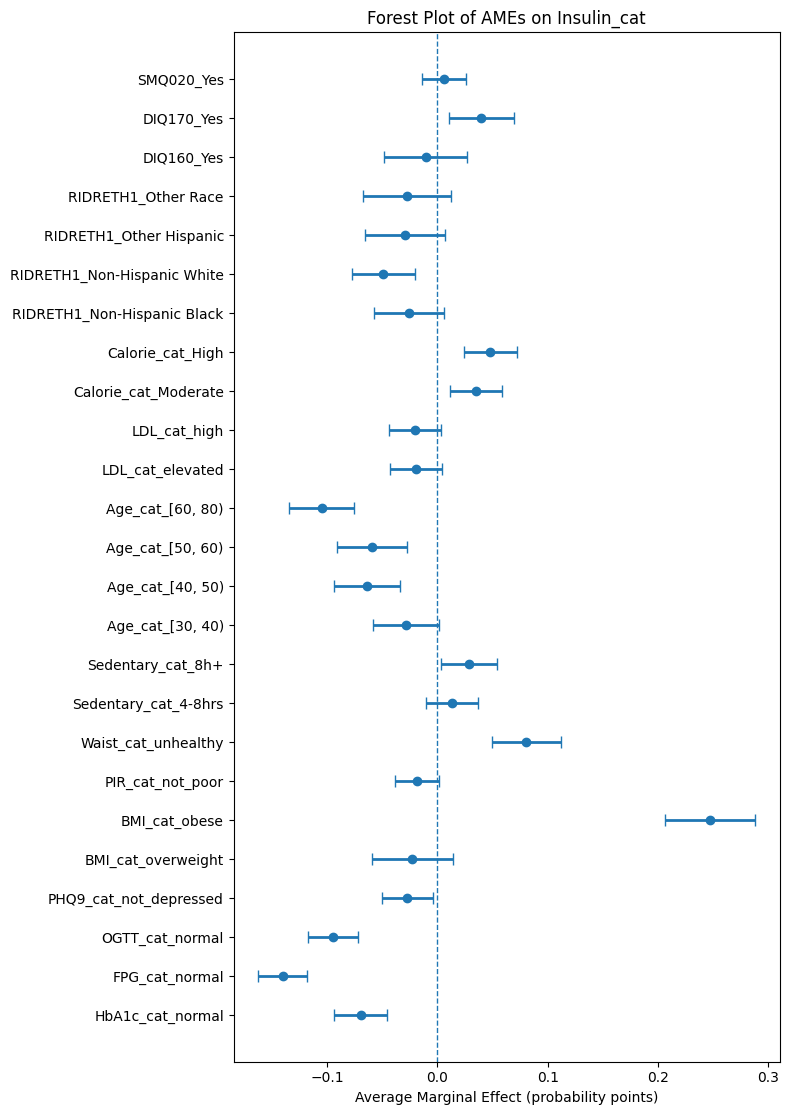

,AME,CI_lower,CI_upper
HbA1c_cat_normal,-0.070,-0.094,-0.046
FPG_cat_normal,-0.140,-0.163,-0.118
OGTT_cat_normal,-0.095,-0.118,-0.072
PHQ9_cat_not_depressed,-0.028,-0.051,-0.004
BMI_cat_overweight,-0.023,-0.059,0.014
BMI_cat_obese,0.247,0.206,0.288
PIR_cat_not_poor,-0.019,-0.039,0.002
Waist_cat_unhealthy,0.081,0.049,0.112
Sedentary_cat_4-8hrs,0.013,-0.011,0.037
Sedentary_cat_8h+,0.028,0.003,0.054


In [87]:
#Construct Forest Plot for Fasting Insulin outcome
#Visual summary of estimated effects (AMEs) together with their confidence intervals.
#which variables have strong, weak or uncertain effects on predicted probability of outcome.

marg = result.get_margeff(at="overall", method="dydx", dummy=True)
ame_df = marg.summary_frame().copy()

#Map actual columns to standard names
ame_df = ame_df.rename(columns={
    "dy/dx":            "AME",
    "Std. Err.":        "SE",
    "Pr(>|z|)":         "p_value",
    "Conf. Int. Low":   "CI_lower",
    "Cont. Int. Hi.":   "CI_upper",   # note: 'Cont.' is a statsmodels typo in some builds
})

#Keep only needed cols
plot_df = ame_df[["AME", "CI_lower", "CI_upper"]].apply(pd.to_numeric, errors="coerce")

#Drop intercept/missing CI rows
idx_keep = (~plot_df.index.to_series().str.contains(r"^const$", case=False, na=False)) & plot_df.notna().all(axis=1)
plot_df = plot_df.loc[idx_keep]


#plot_df = plot_df.reindex(plot_df["AME"].abs().sort_values().index)

#Build symmetric x-errors (clip tiny negative jitter)
left  = (plot_df["AME"] - plot_df["CI_lower"]).clip(lower=0).to_numpy()
right = (plot_df["CI_upper"] - plot_df["AME"]).clip(lower=0).to_numpy()
xerr = np.vstack([left, right])

n = len(plot_df)
fig, ax = plt.subplots(figsize=(8, max(2.5, 0.45*n)))

ax.errorbar(
    plot_df["AME"].to_numpy(),
    np.arange(n),
    xerr=xerr,
    fmt="o", markersize=6,
    ecolor="tab:blue", elinewidth=2, capsize=4
)

ax.axvline(0, color="tab:blue", linestyle="--", linewidth=1)
ax.set_yticks(np.arange(n))
ax.set_yticklabels(plot_df.index.tolist())
ax.set_xlabel("Average Marginal Effect (probability points)")
ax.set_title(f"Forest Plot of AMEs on {getattr(y, 'name', 'outcome')}")
plt.tight_layout()
plt.show()

display(plot_df.round(3))

#**Analysis of the Forest Plot for Fasting Insulin outcome**

1. Glycaemic Markers (HbA1c & FPG)

**Variables:**

HbA1c_cat_normal

FPG_cat_normal

**Interpretation:**

Both variables lie clearly to the left of 0, meaning their average marginal effects (AMEs) are negative.

Their confidence intervals do not cross zero, indicating statistical significance.

**This means:**

Normal HbA1c → ≈ 7.0 pp lower probability of abnormal OGTT compared to elevated HbA1c

Normal FPG → ≈ 14.0 pp lower probability of abnormal OGTT

**Summary:**
Normal long-term glycaemic control (HbA1c) and normal fasting glucose are **strongly protective** against abnormal post-challenge glucose. These are among the most influential protective factors in the model and reflect preserved glycaemic regulation rather than causation.

2. Insulin Status

**Variables:**

Insulin_cat_normal

Insulin_cat_abnormally_high

**Interpretation:**

Normal insulin lies to the left of 0, with a confidence interval that does not cross zero, indicating statistical significance.

Abnormally high insulin lies close to 0, with a confidence interval that crosses zero, indicating no significant association.

**This means:**

Normal insulin → ≈ 7.7 pp lower probability of abnormal OGTT

Abnormally high insulin → no significant difference

**Summary:**
Normal insulin levels are associated with a lower predicted probability of getting diabetes. In contrast, abnormally high insulin does not independently predict OGTT outcomes after adjustment, suggesting overlap with obesity, waist circumference, and other metabolic factors.

3. Body Mass Index (BMI)**

**Variables:**

BMI_cat_overweight

BMI_cat_obese

**Interpretation:**

Overweight lies close to 0, with a confidence interval that crosses zero, indicating no significant association.

Obese lies clearly to the right of 0, with a confidence interval that does not cross zero, indicating strong statistical significance.

**This means:**

Overweight → no significant difference

Obese → ≈ 24.7 pp higher probability of abnormal OGTT

**Summary:**
BMI shows a threshold effect for post-challenge glucose dysregulation. Overweight status is not independently associated, whereas obesity is one of the **strongest risk factors** for getting diabetes, reflecting substantial insulin resistance and impaired post-prandial glucose handling.

4. Age

**Variables:**

Age_cat_[30, 40)

Age_cat_[40, 50)

Age_cat_[50, 60)

Age_cat_[60, 80)

**Interpretation:**

Age groups 40–50, 50–60, and 60–80 lie to the left of 0, with confidence intervals not crossing zero.

The 30–40 group is borderline and not statistically significant.

**This means:**

30–40 yrs → not significant

40–50 yrs → ≈ 6.4 pp lower probability

50–60 yrs → ≈ 5.9 pp lower probability

60–80 yrs → ≈ 10.5 pp lower probability

**Summary:**
Older age groups show a lower predicted probability of getting diabetes, likely reflecting progression from insulin resistance to beta-cell failure with ageing. This inverse association should be interpreted as disease-stage physiology rather than protection.

5. Lipids and Socioeconomic Status

**Variables:**

LDL_cat_elevated

LDL_cat_high

PIR_cat_not_poor

**Interpretation:**

Both LDL categories lie close to 0, with confidence intervals crossing zero.

Not poor (PIR) lies slightly to the left of 0 but is borderline and not statistically significant.

**This means:**

LDL → no significant association

Socioeconomic status → no independent association

**Summary:**
LDL cholesterol and income status do not independently predict abnormal OGTT after adjustment for metabolic and glycaemic factors.

6. Lifestyle and Anthropometric Factors

**Variables:**

Waist_cat_unhealthy

Sedentary_cat_4–8hrs

Sedentary_cat_8h+

**Interpretation:**

Unhealthy waist circumference lies clearly to the right of 0, with a confidence interval not crossing zero.

Sedentary ≥8h also lies to the right of 0 and is statistically significant.

Sedentary 4–8 hours is not significant.

**This means:**

Unhealthy waist → ≈ 8.1 pp higher probability of abnormal OGTT

Sedentary ≥8h → ≈ 2.8 pp higher probability

Sedentary 4–8h → not significant

**Summary:**
Central adiposity and prolonged sedentary behaviour are associated with a modestly higher probability of getting diabetes, consistent with reduced insulin sensitivity and impaired post-prandial glucose disposal.

7. Ethnicity (Race)

**Variables:**

RIDRETH1_Non-Hispanic Black

RIDRETH1_Non-Hispanic White

RIDRETH1_Other Hispanic

RIDRETH1_Other Race

**Interpretation:**

Non-Hispanic White lies to the left of 0, with a confidence interval not crossing zero.

Other ethnicity categories lie close to zero and are not significant.

**This means:**

Non-Hispanic White → ≈ 4.9 pp lower probability of abnormal OGTT

Other ethnic groups → no significant difference

**Summary:**
Ethnic differences are modest for OGTT outcomes. Non-Hispanic White participants show a **lower predicted probability,** while other groups do not differ significantly after adjustment.

8. Diabetes Status and Smoking

**Variables:**

DIQ160_Yes (Diabetes)

DIQ170_Yes (Prediabetes)

SMQ020_Yes (Smoker)

**Interpretation:**

Prediabetes lies to the right of 0, with a confidence interval not crossing zero.

Diagnosed diabetes and smoking are not significant.

**This means:**

Prediabetes → ≈ 4.0 pp higher probability of abnormal OGTT

Diabetes & smoking → no significant association

**Summary:**
Prediabetes is associated with higher predicted probability of getting diabetes, supporting the internal validity of the outcome. Smoking does not independently predict OGTT abnormalities after adjustment.

**Overall Picture**

| Group                          | Direction of Effect | Magnitude    | Significance | Interpretation           |
| ------------------------------ | ------------------- | ------------ | ------------ | ------------------------ |
| Glycaemic markers (HbA1c, FPG) | ↓                   | −7 to −14 pp | Yes          | Strong protection        |
| Obesity & waist circumference  | ↑                   | +8 to +25 pp | Yes          | Major metabolic risk     |
| Age                            | ↓                   | −6 to −11 pp | Yes          | Disease-stage physiology |
| Insulin (normal)               | ↓                   | −8 pp        | Yes          | Protective               |
| Sedentary ≥8h                  | ↑                   | +3 pp        | Yes          | Modest lifestyle risk    |
| SES & LDL                      | ~                   | Null         | No           | No independent effect    |
| Ethnicity                      | Small               | Limited      | Partial      | Minor differences        |

**In short:**

The forest plot shows that **obesity, central adiposity, and impaired glycaemic regulation (HbA1c and FPG)** are the strongest determinants of abnormal OGTT. Normal glucose markers and normal insulin are protective, while age shows an inverse association consistent with later-stage diabetes physiology. Lifestyle effects are modest, and LDL cholesterol and most ethnic differences do not independently predict post-challenge glucose dysregulation. These findings represent **associations rather than causation** and highlight that OGTT captures a distinct aspect of glycaemic physiology compared with fasting glucose or HbA1c.

# **4. XGBoost analysis (Predictive modelling)**